In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
 numpy as np
from scipy.stats import ttest_rel, wilcoxon

bilstm_bigru = np.array([0.88,0.90,0.88,0.92,0.91,0.89,0.90,0.91,0.92,0.91])
xgboost = np.array([0.85,0.86,0.86,0.82,0.84,0.85,0.88,0.82,0.83,0.85])
eegnet = np.array([0.71,0.67,0.67,0.67,0.67,0.73,0.70,0.69,0.69,0.74])
transformer = np.array([0.89,0.89,0.89,0.85,0.88,0.88,0.88,0.88,0.88,0.89])

print("BiLSTM-BiGRU vs XGBoost:", ttest_rel(bilstm_bigru, xgboost))
print("BiLSTM-BiGRU vs EEGNet:", ttest_rel(bilstm_bigru, eegnet))
print("BiLSTM-BiGRU vs Transformer:", ttest_rel(bilstm_bigru, transformer))

BiLSTM-BiGRU vs XGBoost: TtestResult(statistic=np.float64(5.852557320049588), pvalue=np.float64(0.00024298329053726268), df=np.int64(9))
BiLSTM-BiGRU vs EEGNet: TtestResult(statistic=np.float64(20.617540334198807), pvalue=np.float64(6.94241123178993e-09), df=np.int64(9))
BiLSTM-BiGRU vs Transformer: TtestResult(statistic=np.float64(2.7924259052209983), pvalue=np.float64(0.020970546617932857), df=np.int64(9))


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Bidirectional, LSTM, GRU, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"

df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values   # Labels

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

from collections import Counter
print("Train:", Counter(y_train))
print("Val  :", Counter(y_val))
print("Test :", Counter(y_test))

2026-03-05 23:09:13.235078: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772752153.610114      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772752153.708302      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772752154.566906      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772752154.566952      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772752154.566955      55 computation_placer.cc:177] computation placer alr

Train: Counter({np.float64(0.0): 1218, np.float64(1.0): 616, np.float64(2.0): 602})
Val  : Counter({np.float64(0.0): 305, np.float64(1.0): 154, np.float64(2.0): 151})
Test : Counter({np.float64(0.0): 381, np.float64(1.0): 193, np.float64(2.0): 188})


In [6]:
import pandas as pd
import numpy as np

# ------------------------
# Load Dataset
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

print("Original dataset shape:", df.shape)

# ------------------------
# Check Duplicate Rows
# ------------------------
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

# ------------------------
# Remove Duplicates
# ------------------------
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

# ------------------------
# Separate Features and Labels
# ------------------------
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)  # convert labels to integer

# ------------------------
# Label Distribution
# ------------------------
label_counts = pd.Series(y).value_counts().sort_index()

print("\nClass Distribution:")
for label, count in label_counts.items():
    print(f"Class {label}: {count} samples")

Original dataset shape: (3808, 3801)
Number of duplicate rows: 0
Dataset shape after removing duplicates: (3808, 3801)

Class Distribution:
Class 0: 1904 samples
Class 1: 963 samples
Class 2: 941 samples


### Transformer-based

X_train shape: (3046, 1, 3800)
X_test shape: (762, 1, 3800)
Number of classes: 3


2026-03-07 16:26:36.518180: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 3800)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1, 32)          │       121,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,211 (805.51 KB)

 Trainable params: 206,211 (805.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.3394 - loss: 22.3908 - val_accuracy: 0.5639 - val_loss: 21.1915
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.3999 - loss: 21.8789 - val_accuracy: 0.6262 - val_loss: 20.8208
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.4435 - loss: 21.4930 - val_accuracy: 0.6639 - val_loss: 20.5007
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.4768 - loss: 21.0256 - val_accuracy: 0.6951 - val_loss: 20.1946
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.4827 - loss: 20.7477 - val_accuracy: 0.7230 - val_loss: 19.8634
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5116 - loss: 20.3638 - val_accuracy: 0.7459 - val_loss: 19.5435
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.5115 - loss: 20.0824 - val_accuracy: 0.7721 - val_loss: 19.2487
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5577 - loss: 19.6957 -

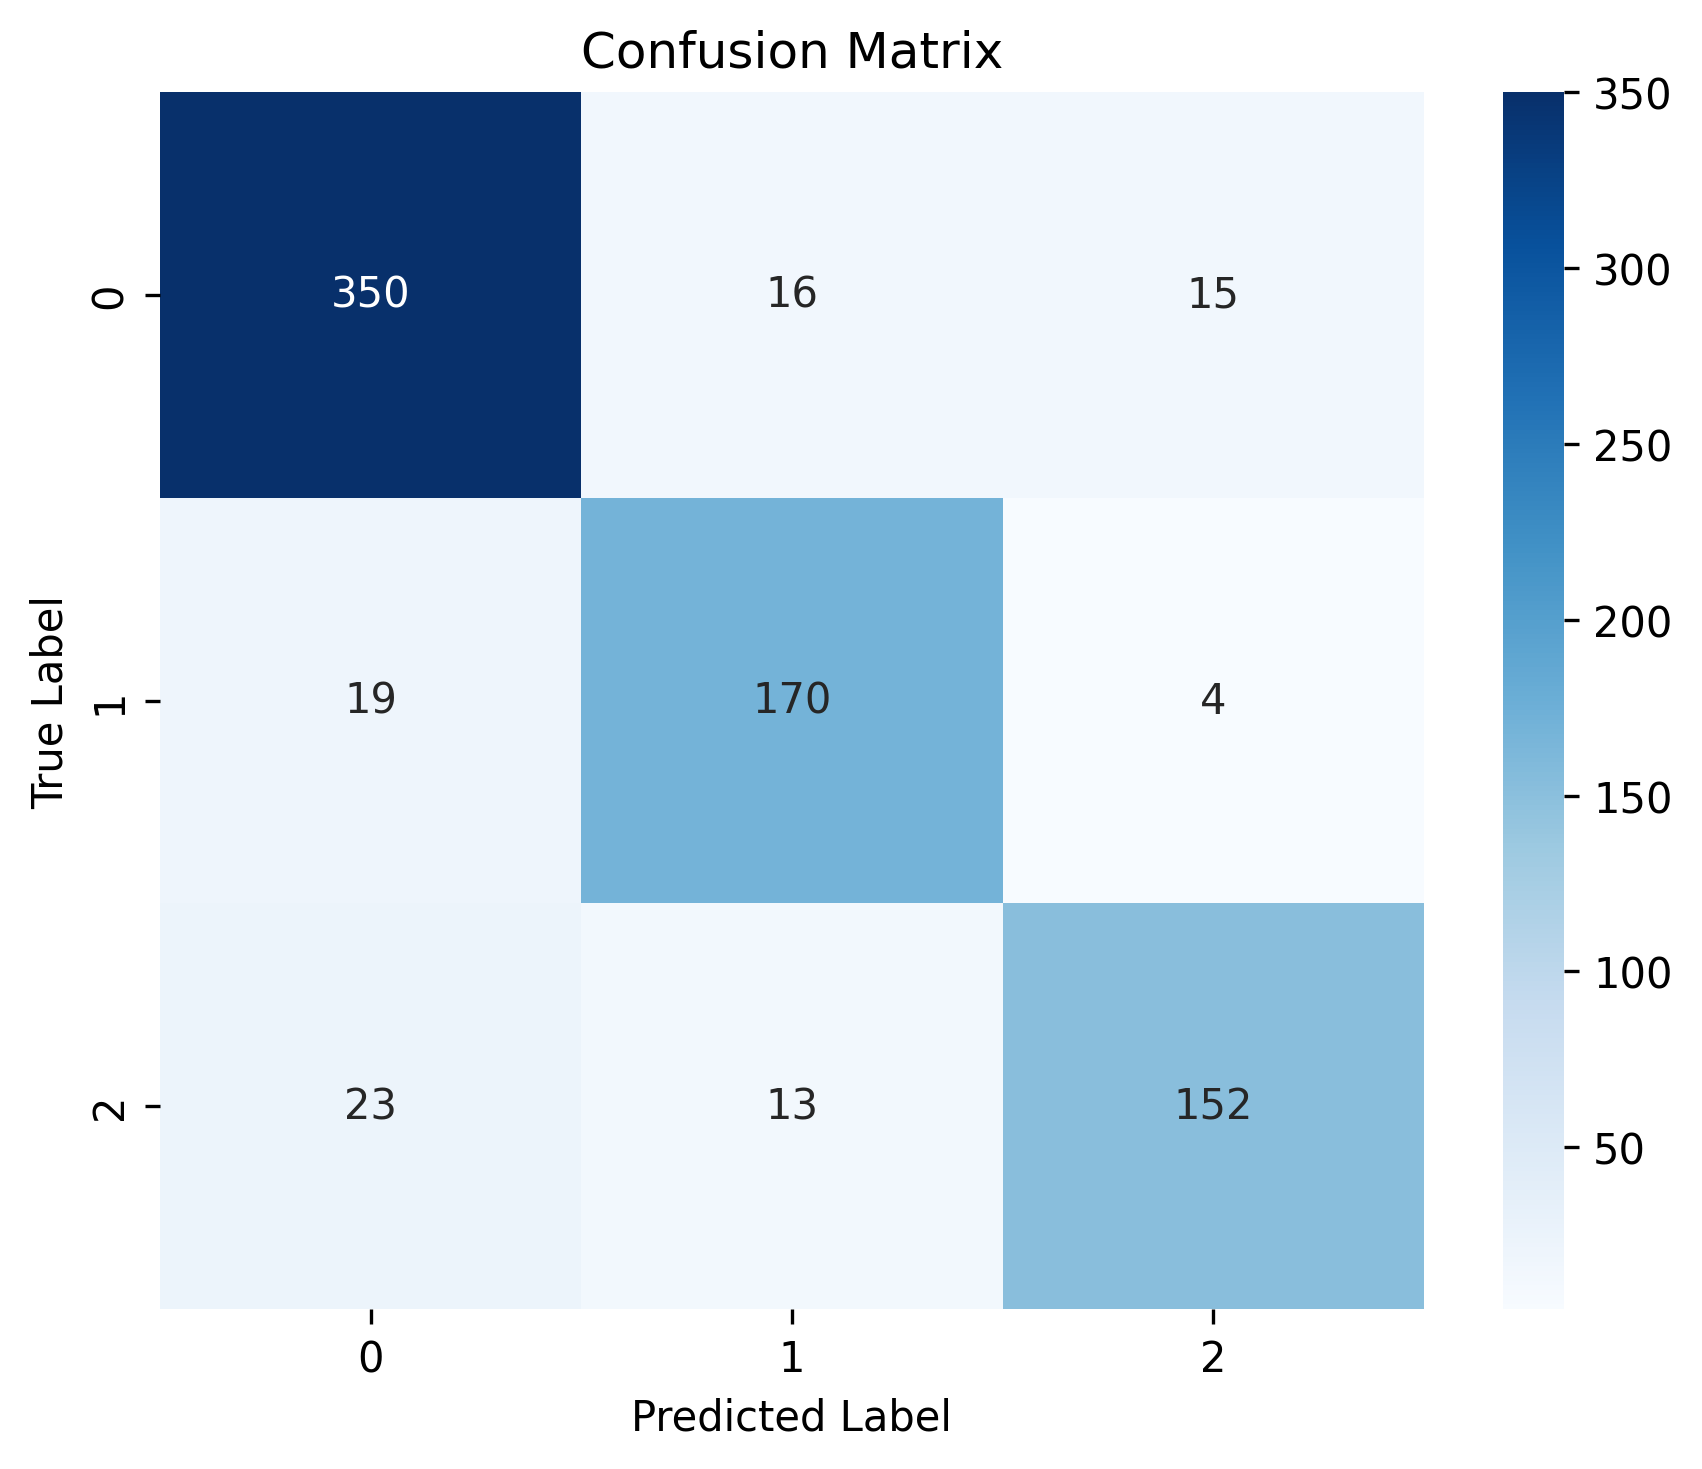

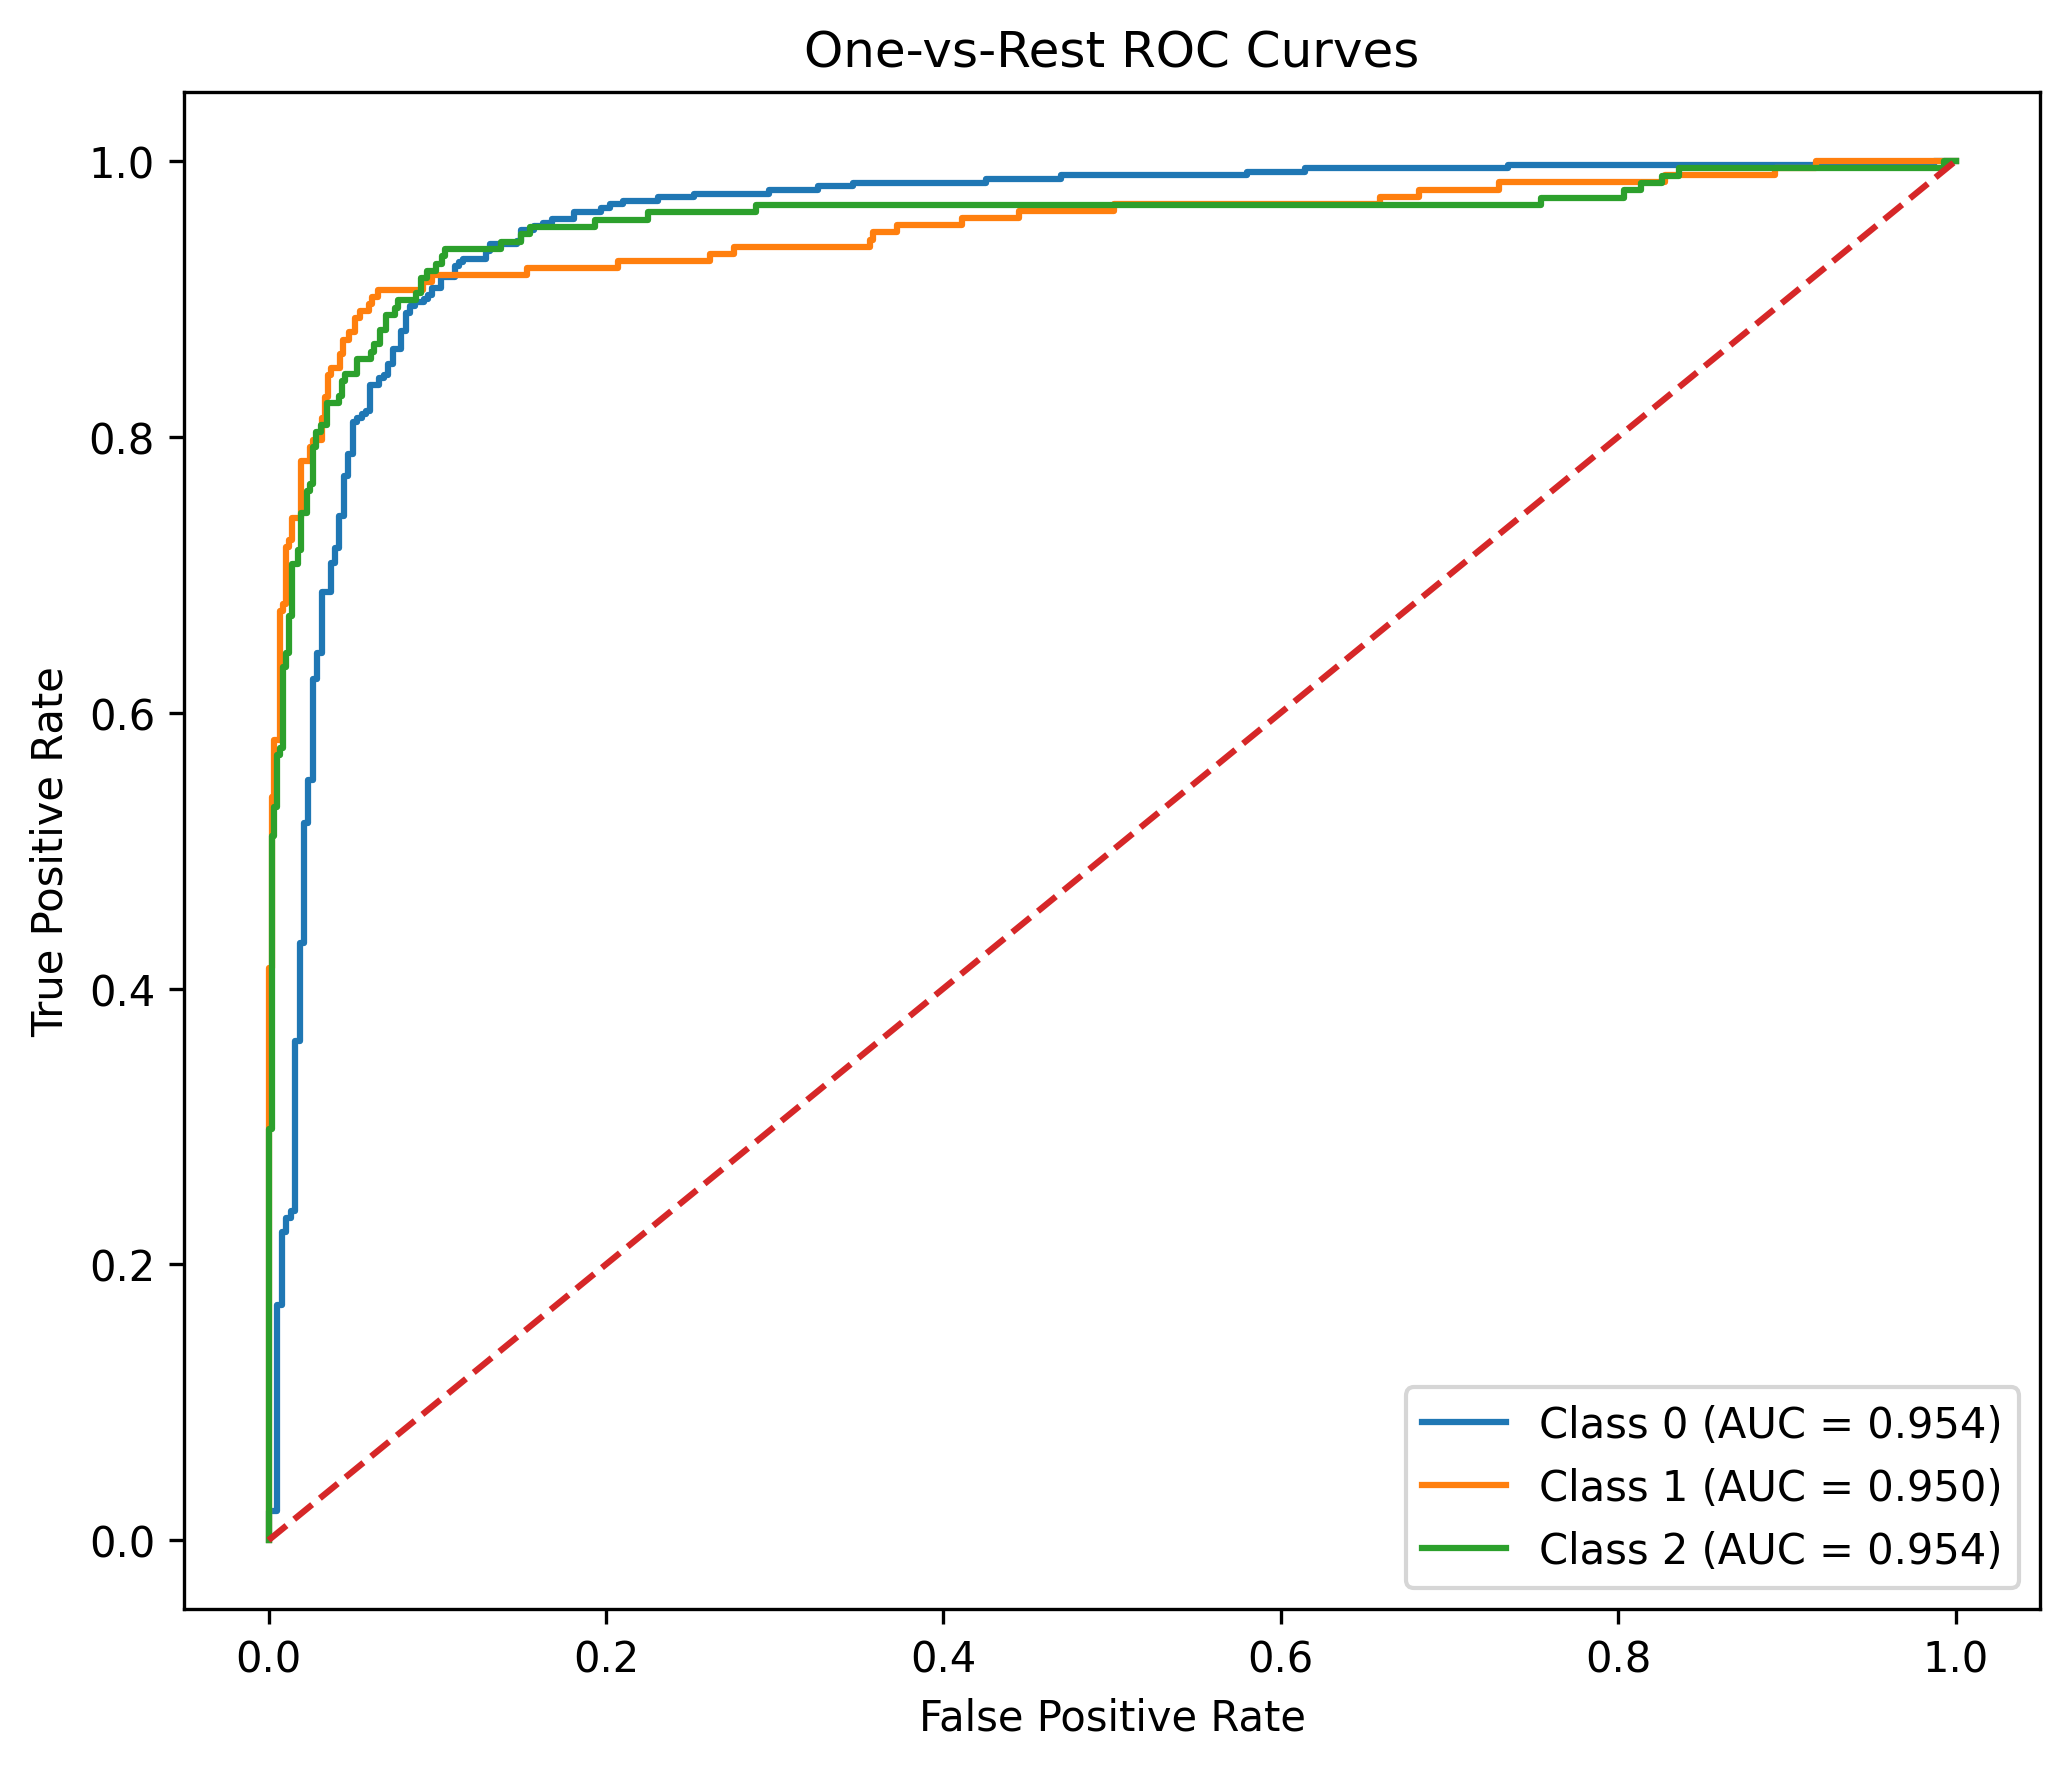

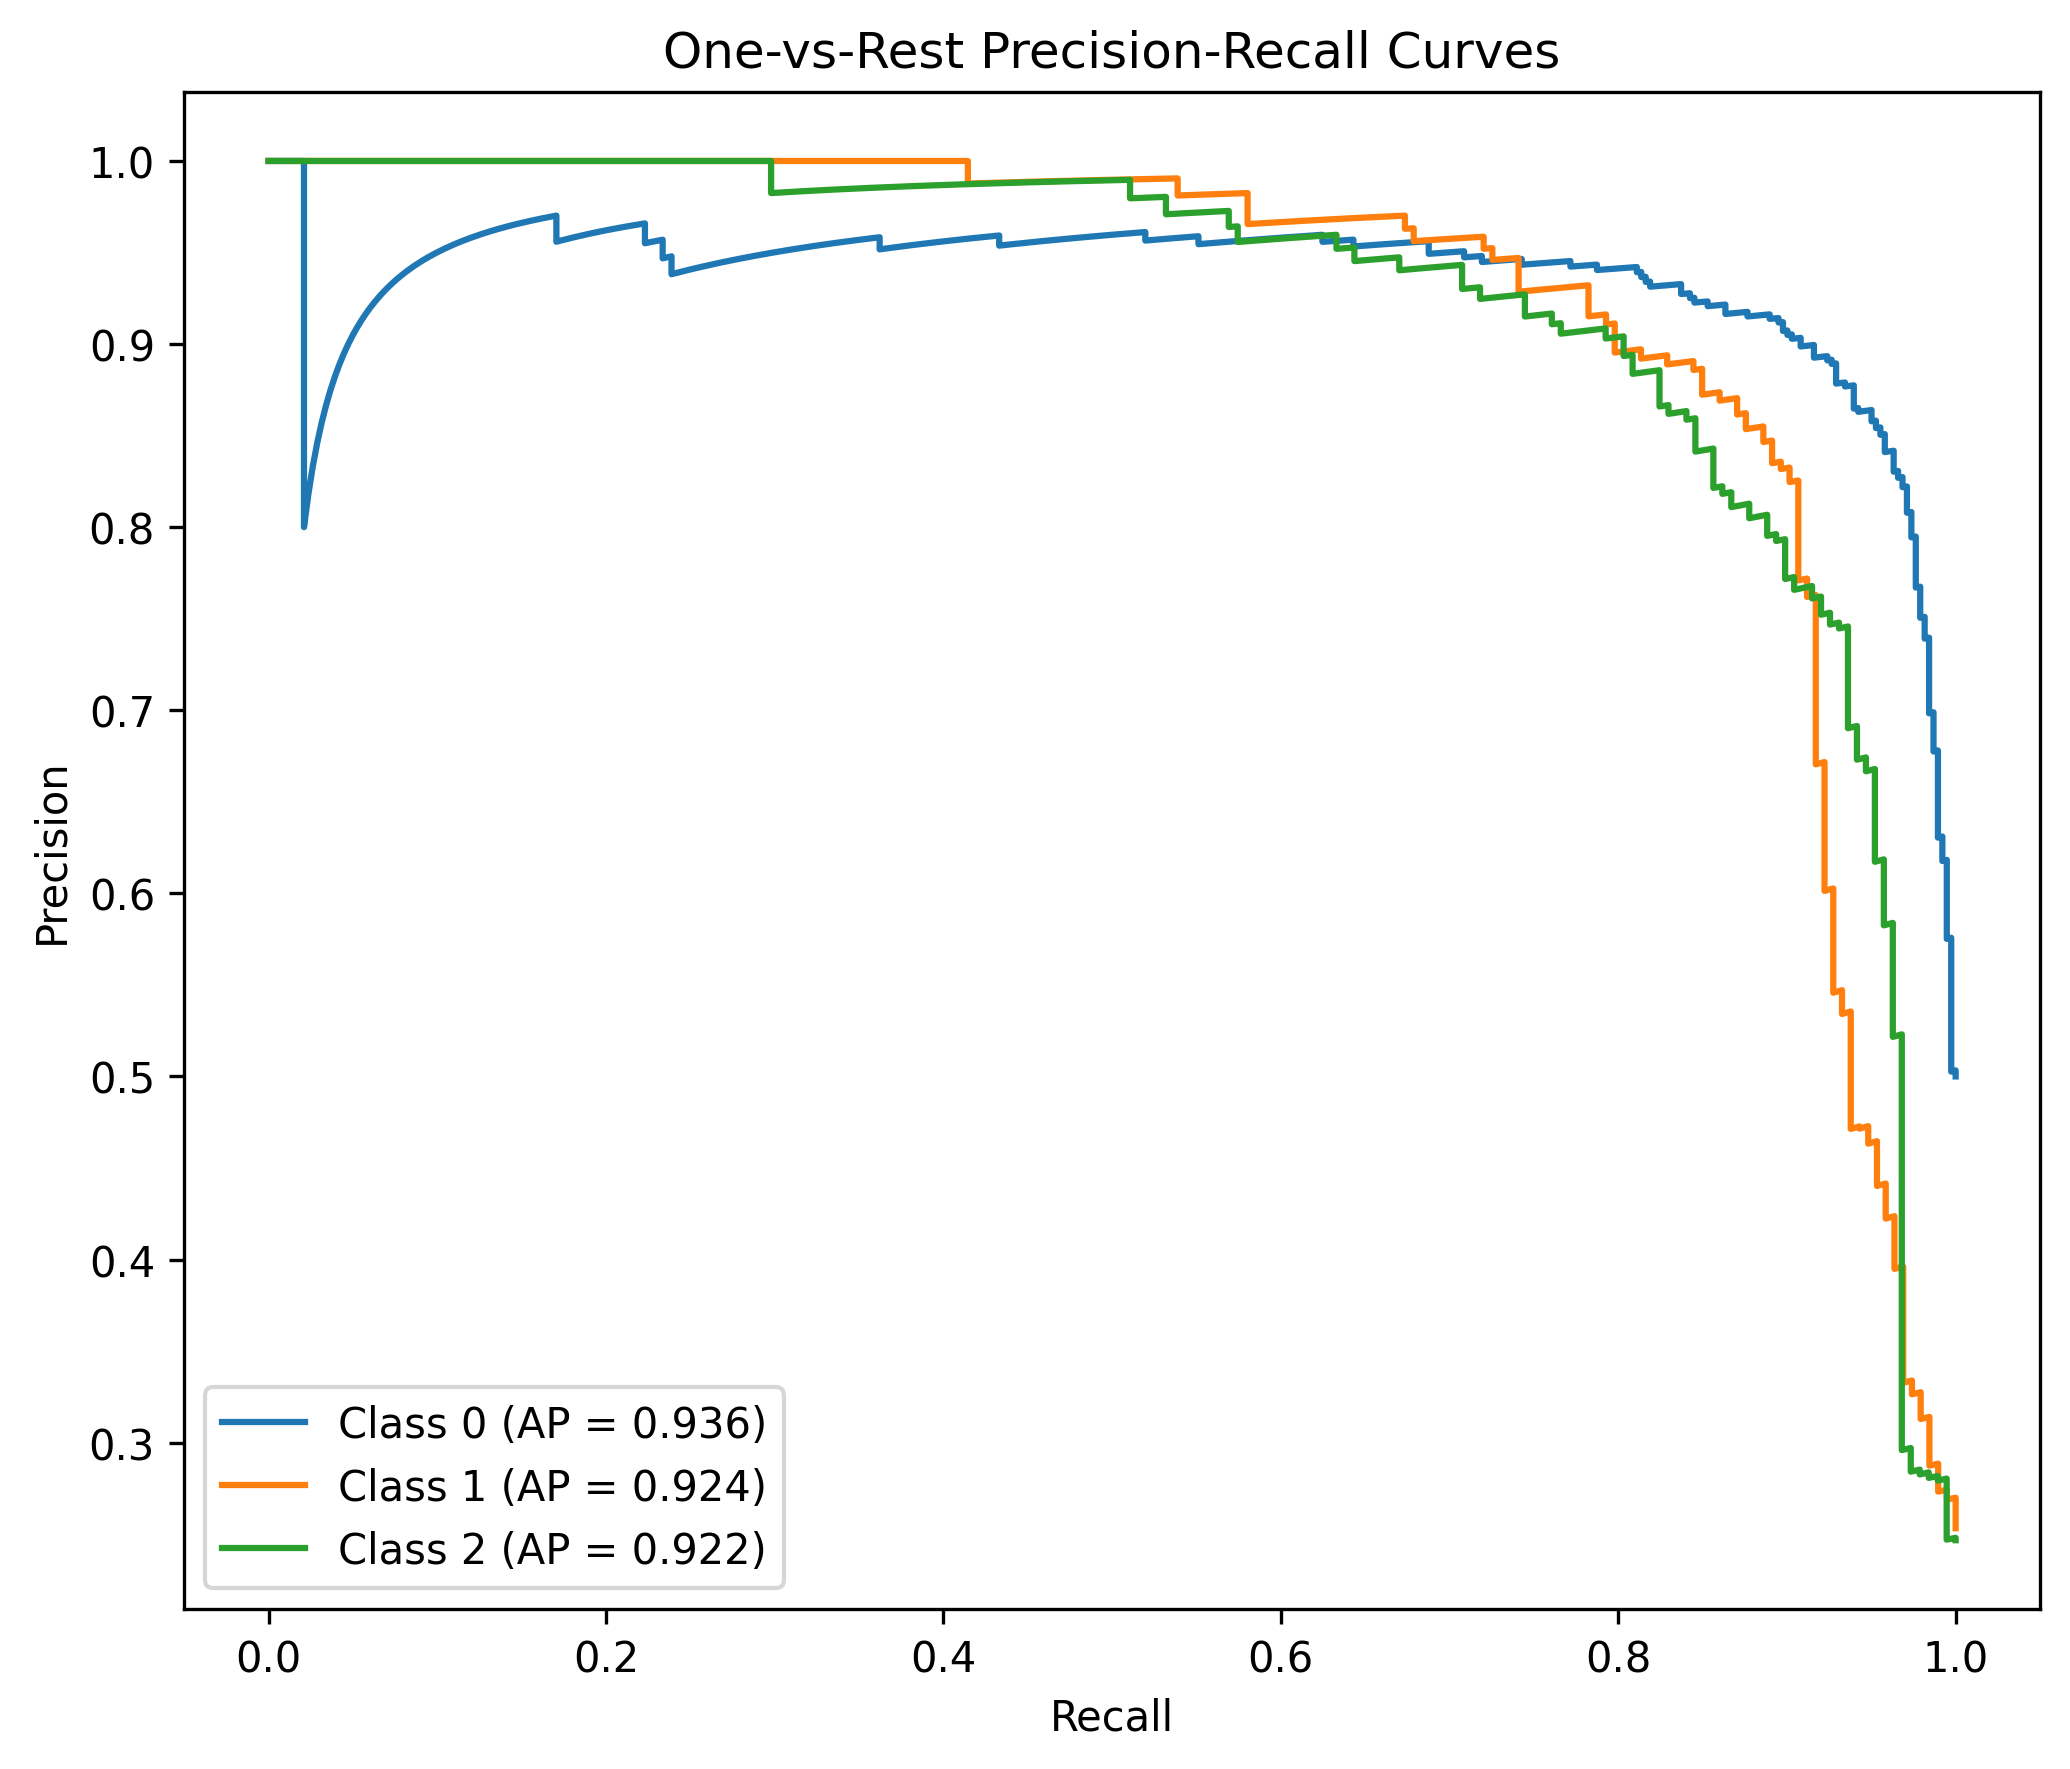

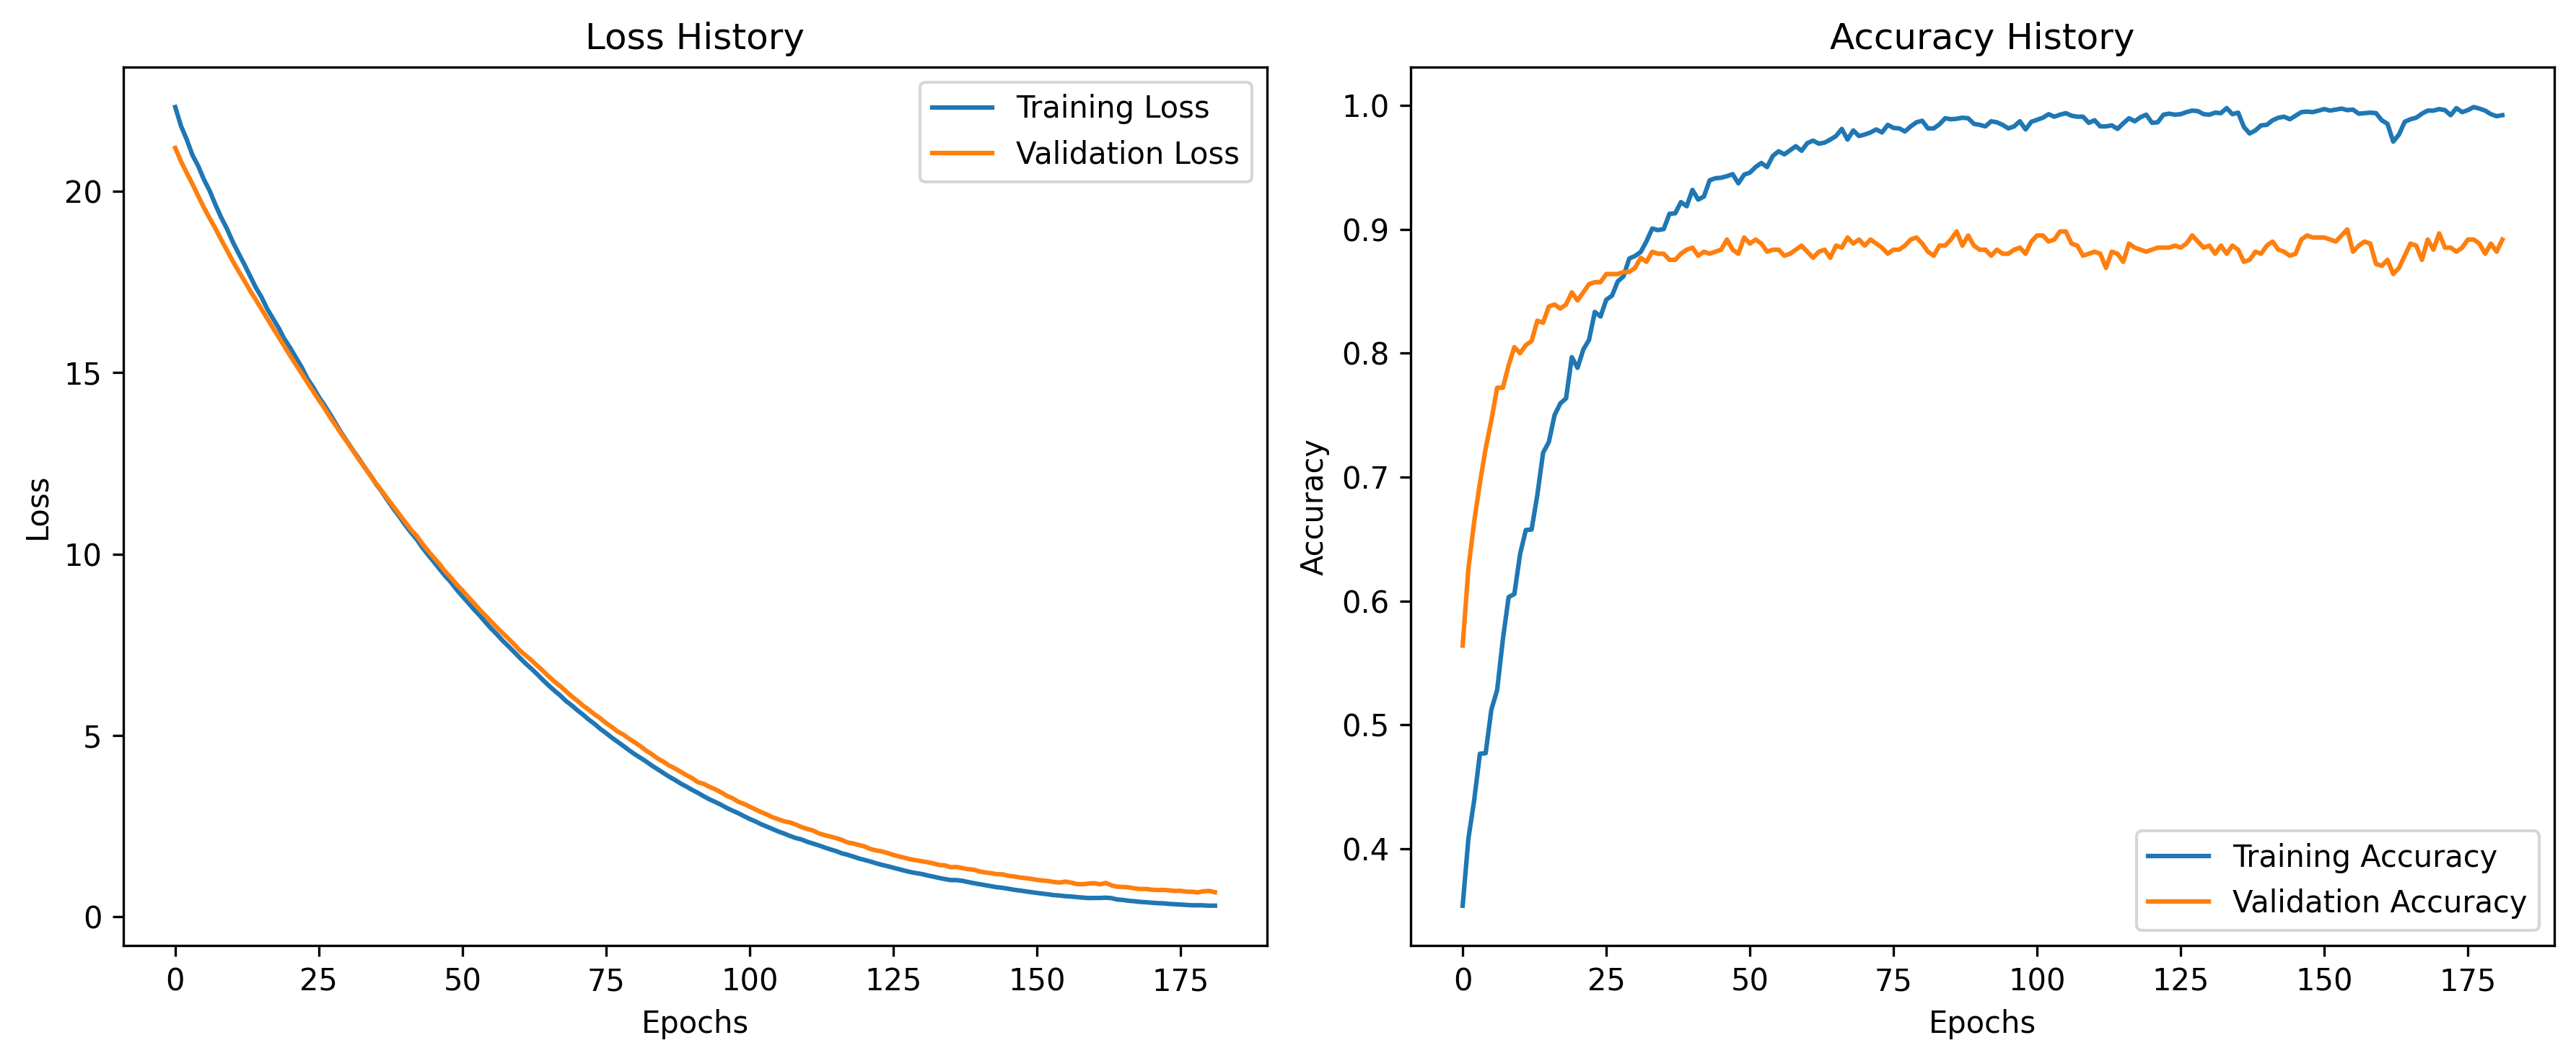

In [2]:
# Transformer model usage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

# ------------------------
# Reproducibility
# ------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values.astype(np.float32)   # Features
y = df.iloc[:, -1].values.astype(int)           # Labels

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Keep your original input shape
# Shape becomes: (num_samples, 1, num_features)
X = np.expand_dims(X, axis=1)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Number of classes
num_classes = len(np.unique(y))

# One-hot labels for ROC-AUC / PR-AUC computation
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of classes:", num_classes)

# ------------------------
# Positional Encoding Function
# ------------------------
def positional_encoding(length, depth):
    """
    Generate positional encoding for input sequences.
    """
    pos = np.arange(length)[:, np.newaxis]
    i = np.arange(depth)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(depth))
    angle_rads = pos * angle_rates

    # Apply sin to even indices, cos to odd indices
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.convert_to_tensor(angle_rads, dtype=tf.float32)

# ------------------------
# Transformer Block
# ------------------------
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.6, l2_reg=0.05):
        super(TransformerBlock, self).__init__()

        # Keep your current style; key_dim=embed_dim follows your original implementation
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = tf.keras.Sequential([
            Dense(
                ff_dim,
                activation="relu",
                kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
            ),
            Dense(
                embed_dim,
                kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
            )
        ])

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# ------------------------
# Transformer Model
# ------------------------
def build_transformer(
    input_shape,
    num_classes,
    embed_dim=32,
    num_heads=4,
    ff_dim=64,
    num_blocks=4,
    dropout_rate=0.6,
    l2_reg=0.05
):
    inputs = Input(shape=input_shape)

    # Positional Encoding
    positions = positional_encoding(input_shape[0], embed_dim)

    # Input Projection
    x = Dense(
        embed_dim,
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
    )(inputs)

    # Add positional encodings
    x = x + positions

    # Transformer Blocks
    for _ in range(num_blocks):
        x = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate,
            l2_reg=l2_reg
        )(x)

    # Classification Head
    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
    )(x)

    return Model(inputs, outputs)

# ------------------------
# Build and Train the Model
# ------------------------
input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)
model = build_transformer(
    input_shape=input_shape,
    num_classes=num_classes,
    embed_dim=32,
    num_heads=4,
    ff_dim=64,
    num_blocks=4,
    dropout_rate=0.6,
    l2_reg=0.05
)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_proba = model.predict(X_train, verbose=0)
y_test_proba = model.predict(X_test, verbose=0)

y_train_pred = np.argmax(y_train_proba, axis=1)
y_test_pred = np.argmax(y_test_proba, axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))

# ------------------------
# AUC-ROC and AUC-PRC
# ------------------------
# Multiclass One-vs-Rest
roc_auc_macro = roc_auc_score(
    y_test_cat, y_test_proba, multi_class="ovr", average="macro"
)
roc_auc_weighted = roc_auc_score(
    y_test_cat, y_test_proba, multi_class="ovr", average="weighted"
)

pr_auc_macro = average_precision_score(
    y_test_cat, y_test_proba, average="macro"
)
pr_auc_weighted = average_precision_score(
    y_test_cat, y_test_proba, average="weighted"
)

print(f"\nMacro ROC-AUC (OvR): {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC (OvR): {roc_auc_weighted:.4f}")
print(f"Macro PR-AUC: {pr_auc_macro:.4f}")
print(f"Weighted PR-AUC: {pr_auc_weighted:.4f}")

print("\nPer-class ROC-AUC and PR-AUC:")
for i in range(num_classes):
    class_roc_auc = roc_auc_score(y_test_cat[:, i], y_test_proba[:, i])
    class_pr_auc = average_precision_score(y_test_cat[:, i], y_test_proba[:, i])
    print(f"Class {i}: ROC-AUC = {class_roc_auc:.4f}, PR-AUC = {class_pr_auc:.4f}")

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5), dpi=300)
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------
# Plot ROC Curves
# ------------------------
plt.figure(figsize=(7, 6), dpi=300)

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_test_proba[:, i])
    auc_i = roc_auc_score(y_test_cat[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc_i:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------
# Plot Precision-Recall Curves
# ------------------------
plt.figure(figsize=(7, 6), dpi=300)

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test_cat[:, i], y_test_proba[:, i])
    ap_i = average_precision_score(y_test_cat[:, i], y_test_proba[:, i])
    plt.plot(recall, precision, label=f"Class {i} (AP = {ap_i:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("One-vs-Rest Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12, 5), dpi=300)

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss History')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy History')
plt.legend()

plt.tight_layout()
plt.show()

X_train shape: (3046, 1, 3800)
X_test shape: (762, 1, 3800)
Number of classes: 3


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 1, 3800)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1, 32)          │       121,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,211 (805.51 KB)

 Trainable params: 206,211 (805.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.3798 - loss: 22.2673 - val_accuracy: 0.5459 - val_loss: 21.2073
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.4022 - loss: 21.9055 - val_accuracy: 0.6197 - val_loss: 20.8159
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.4143 - loss: 21.4646 - val_accuracy: 0.6492 - val_loss: 20.4775
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.4624 - loss: 21.0904 - val_accuracy: 0.6770 - val_loss: 20.1595
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.4774 - loss: 20.7165 - val_accuracy: 0.7131 - val_loss: 19.8299
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.5069 - loss: 20.3450 - val_accuracy: 0.7230 - val_loss: 19.5295
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.5327 - loss: 20.0226 - val_accuracy: 0.7443 - val_loss: 19.2165
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.5558 - loss: 19.6613 -

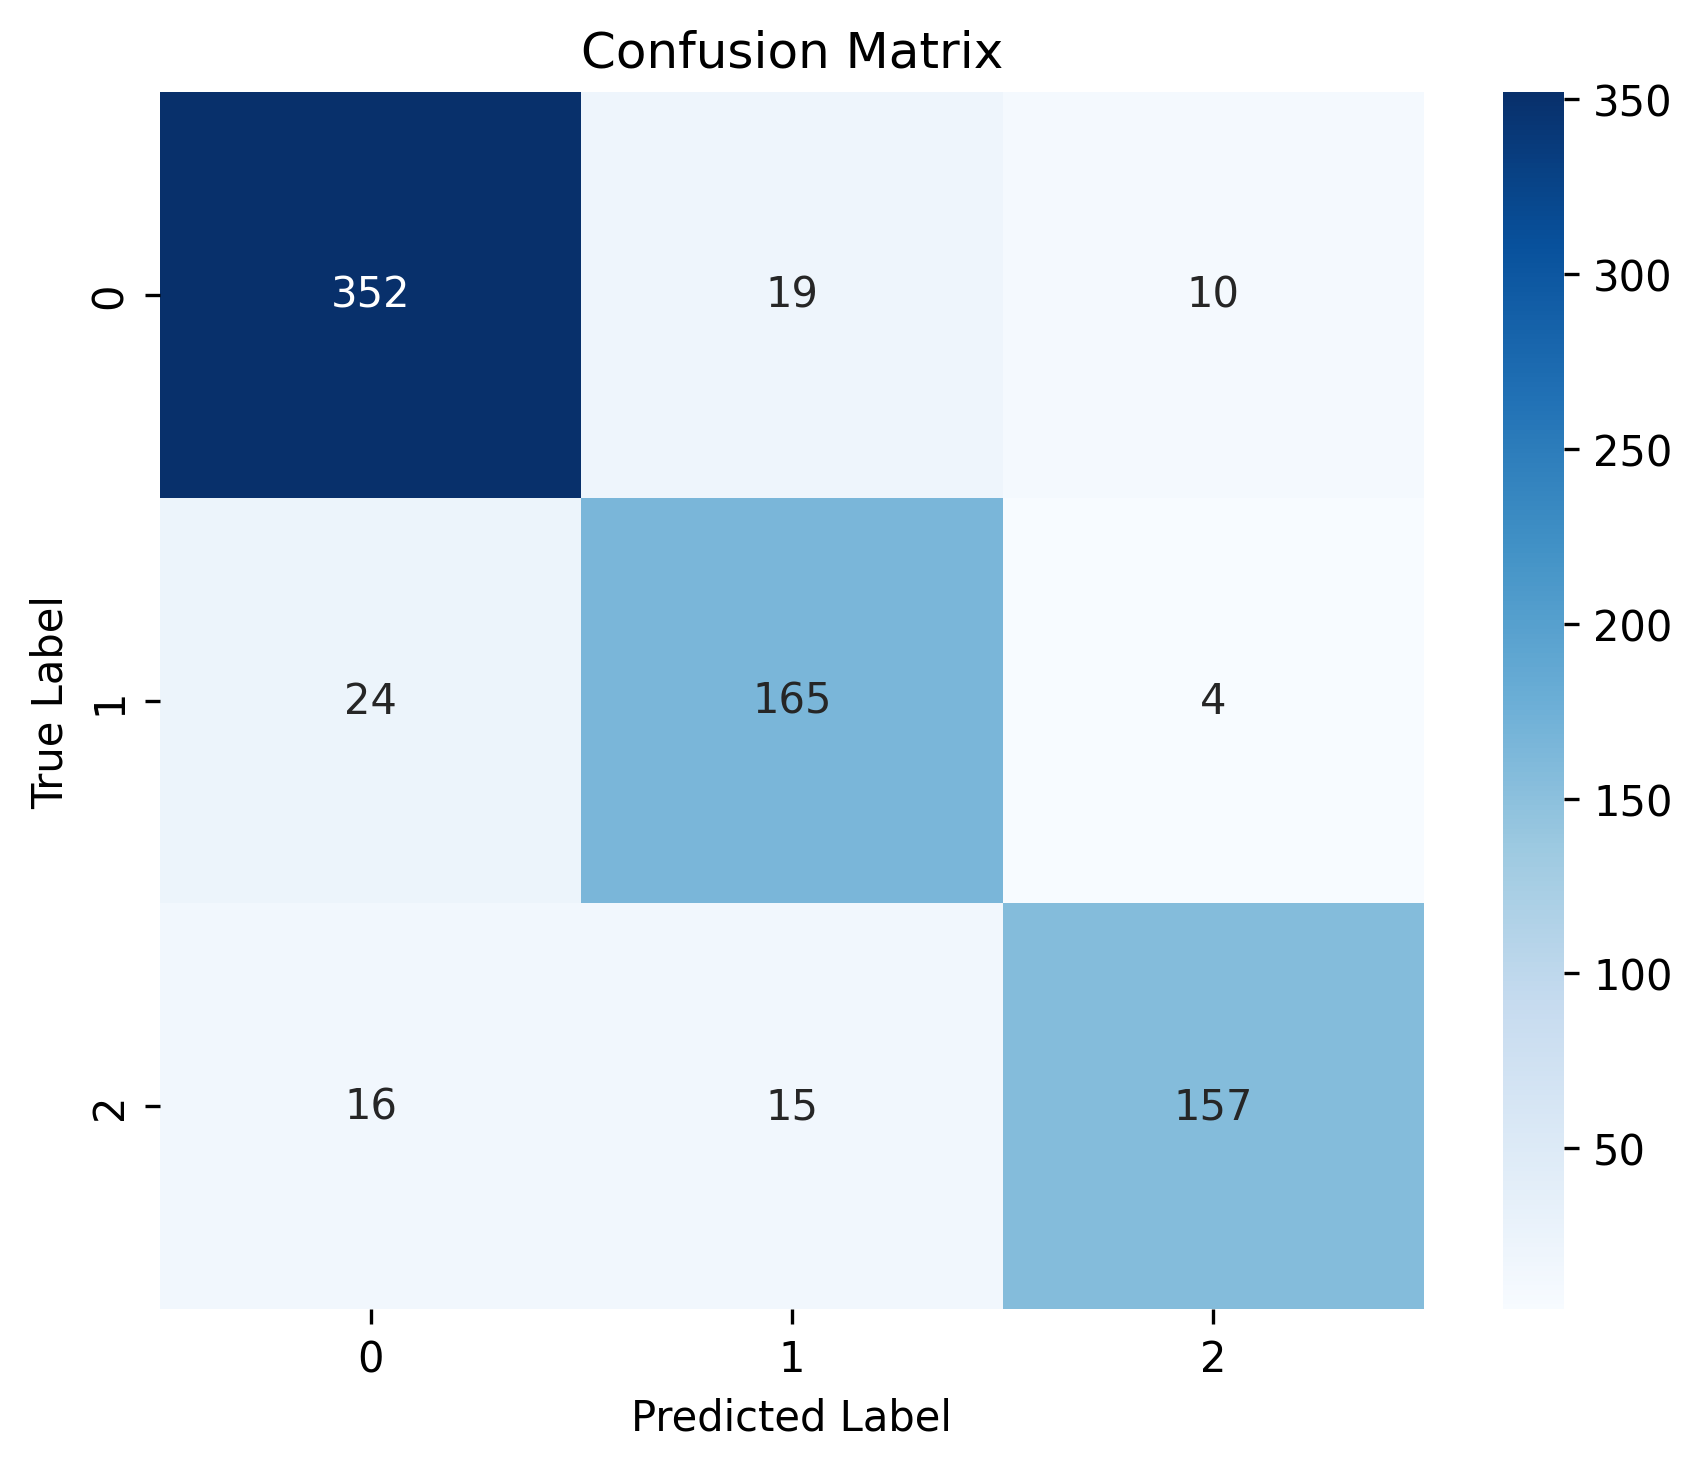

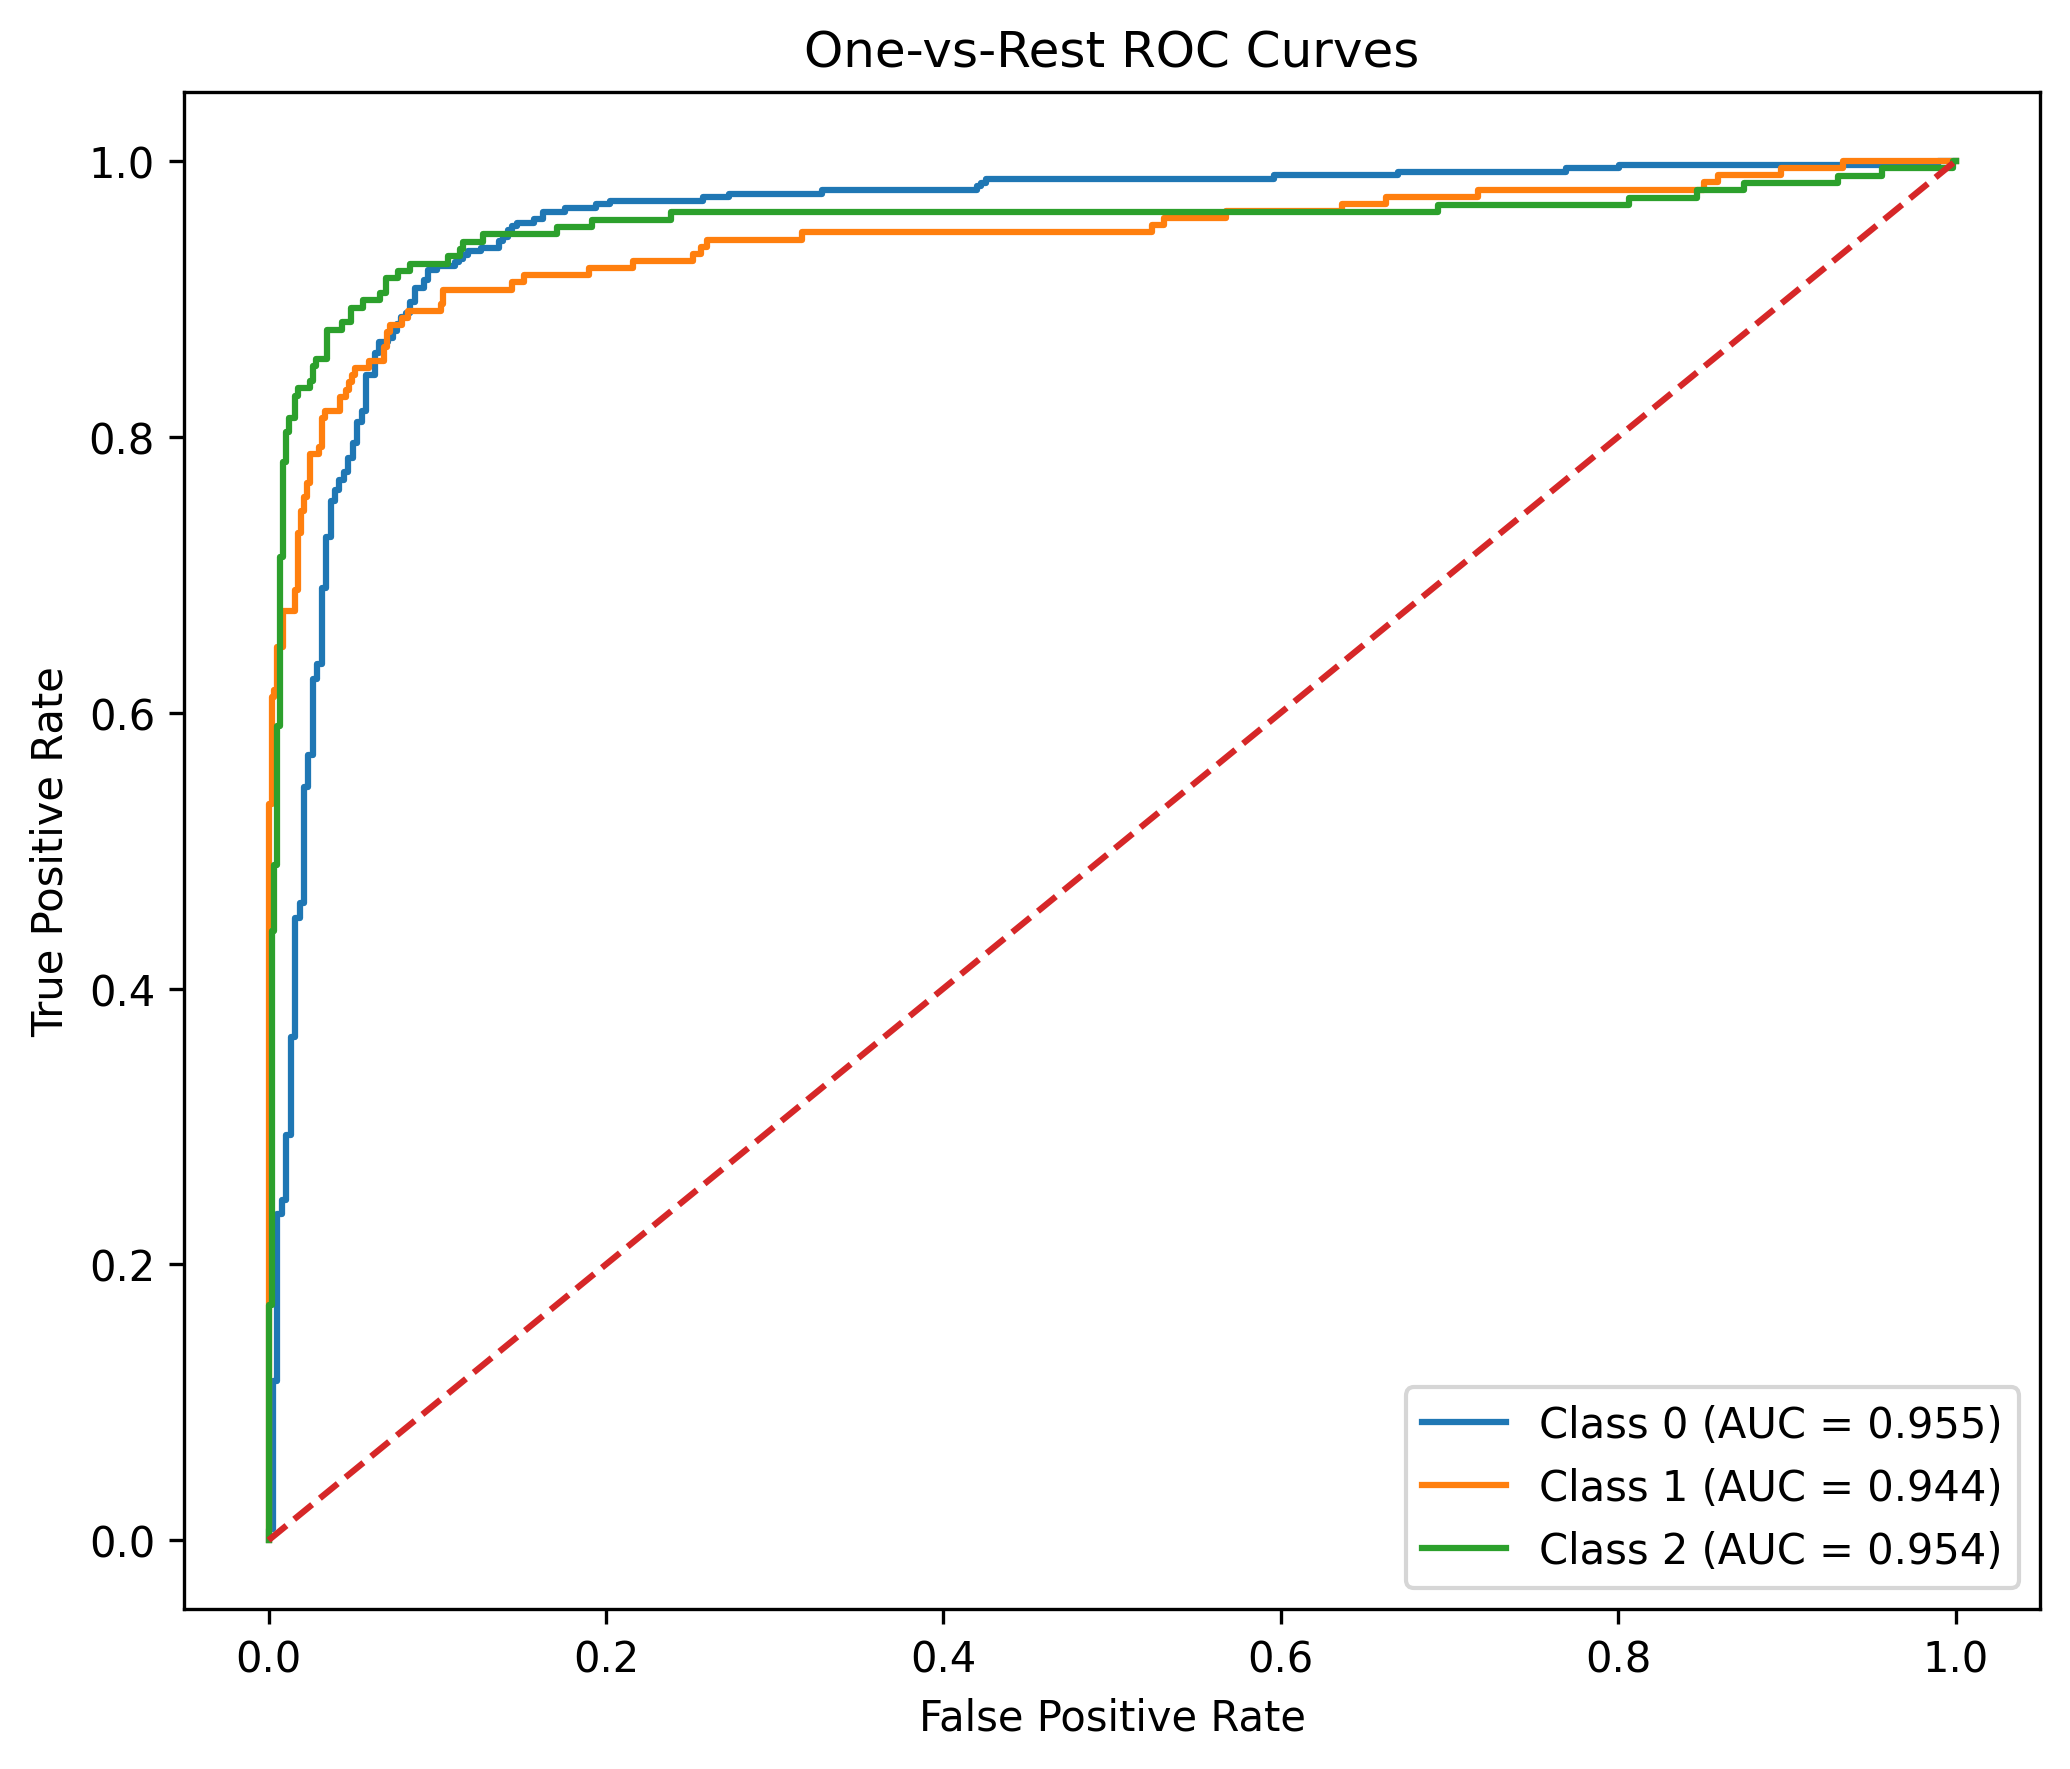

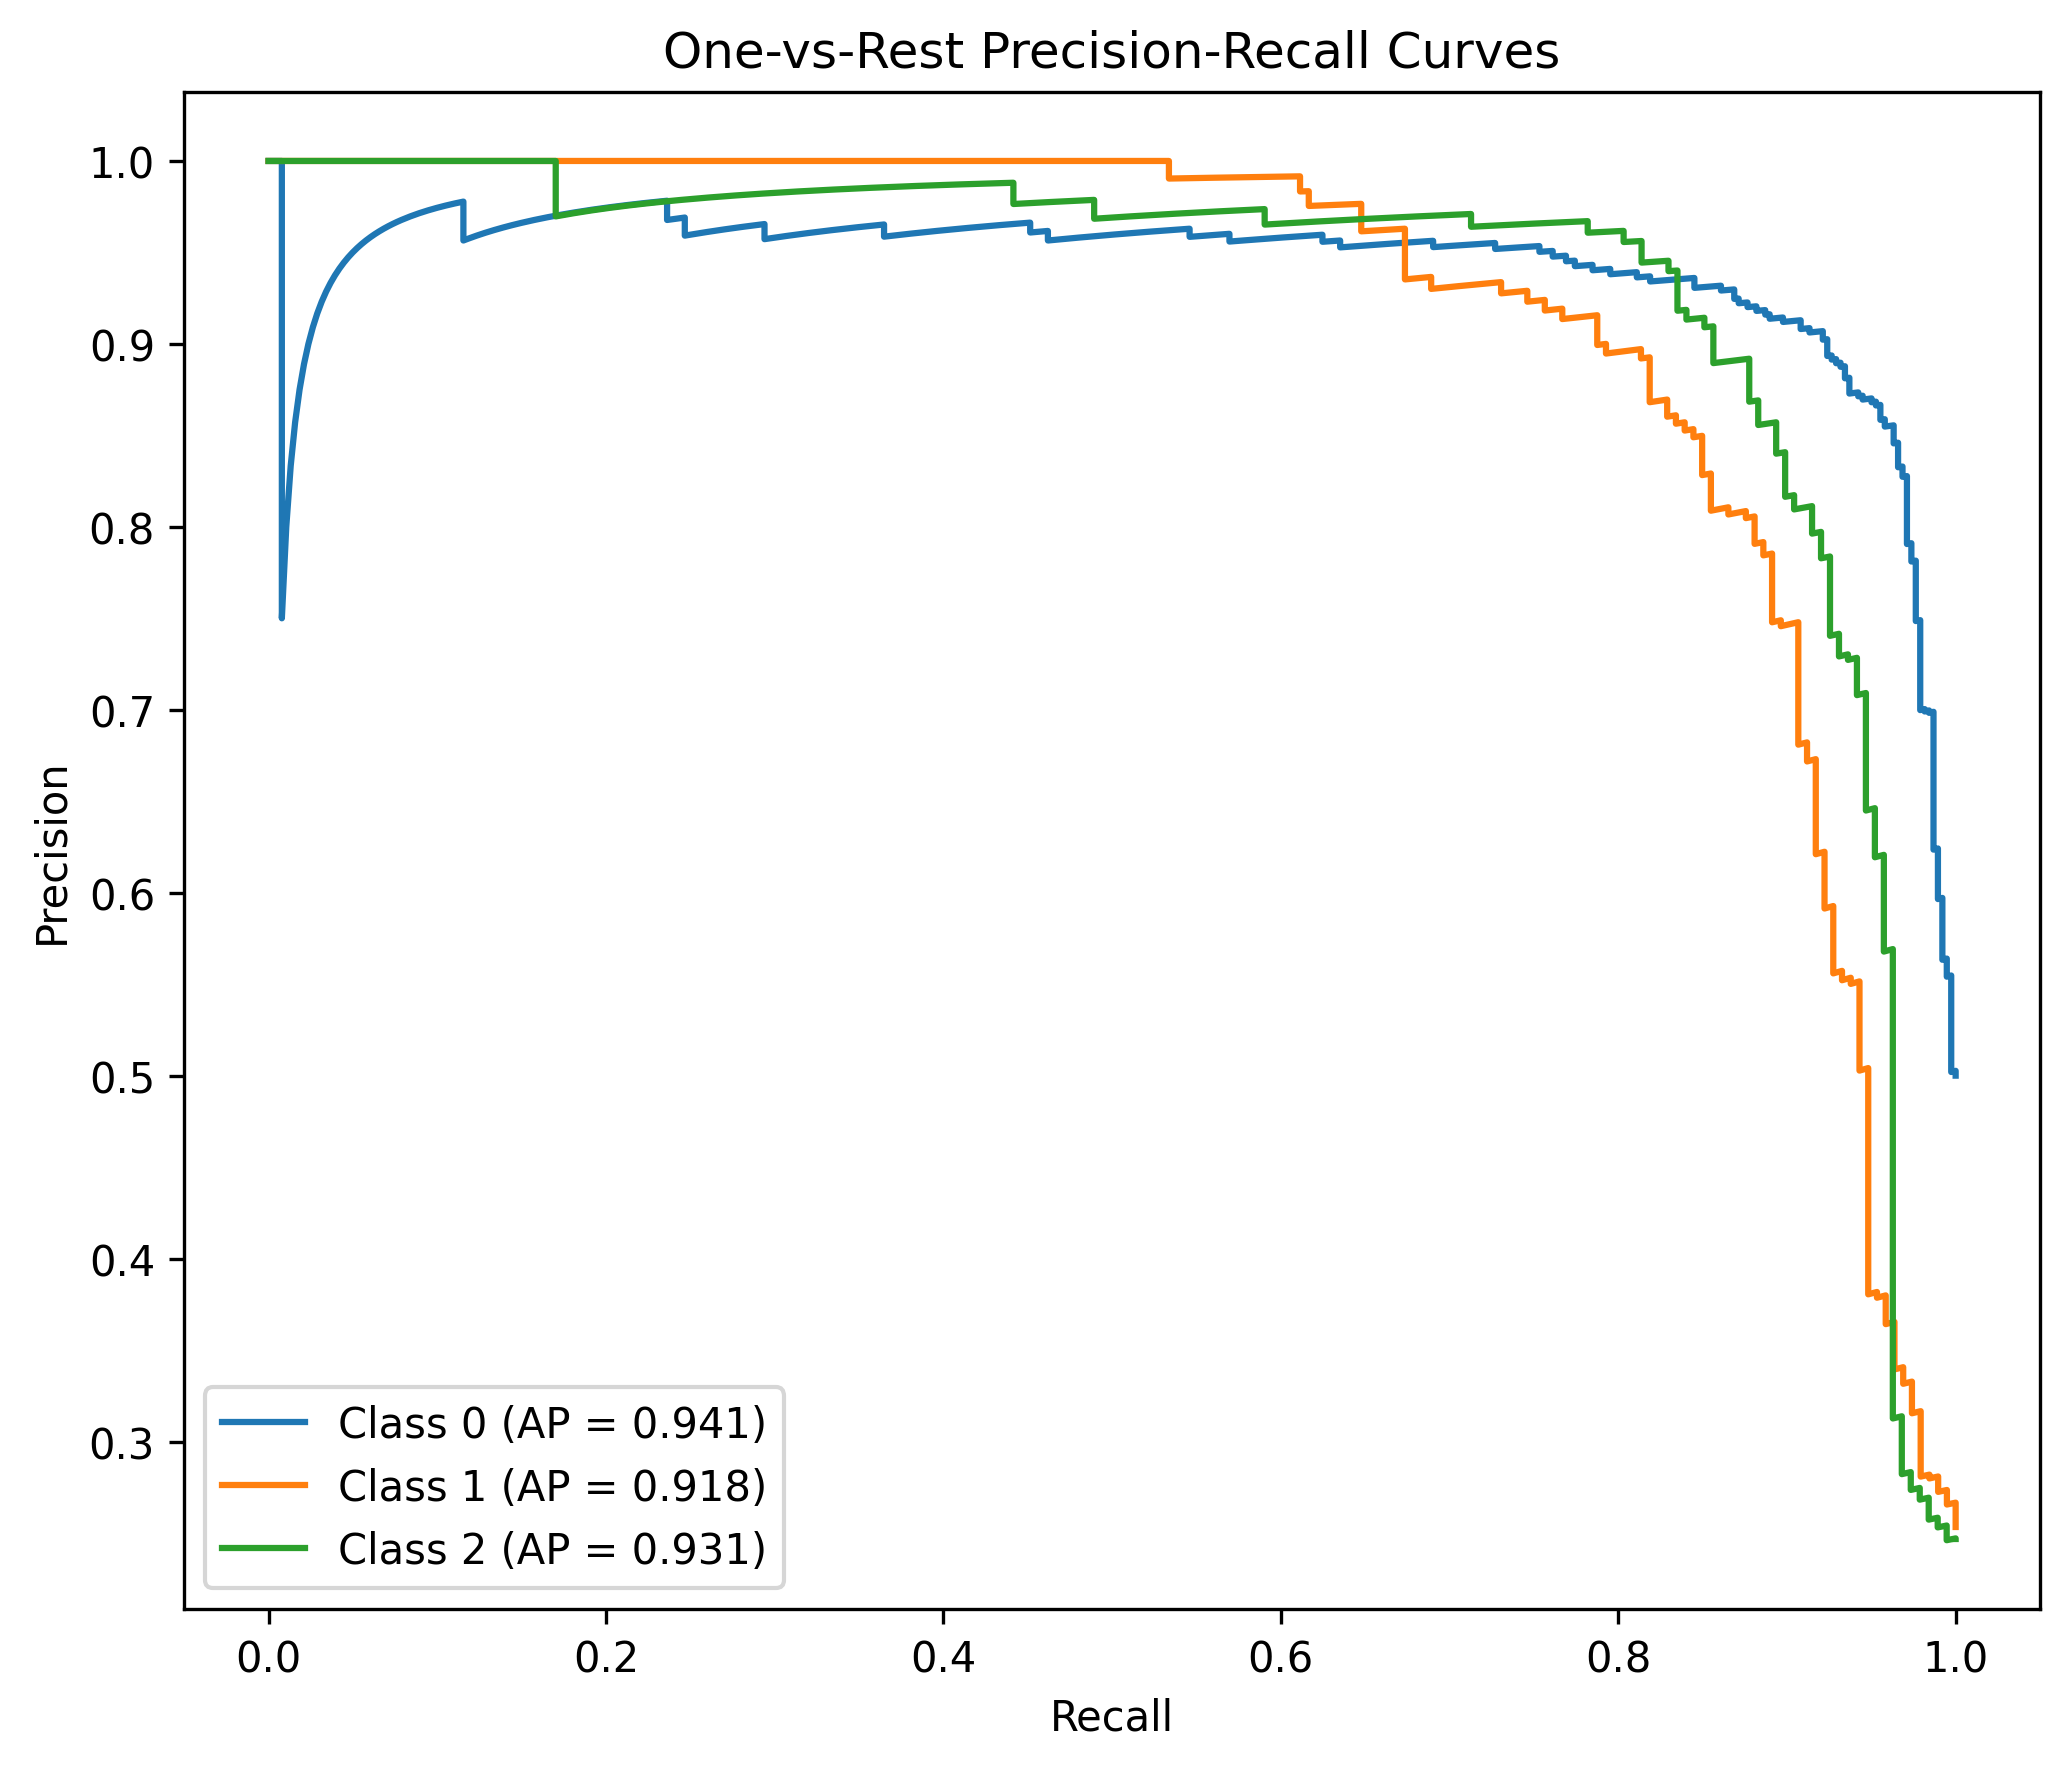

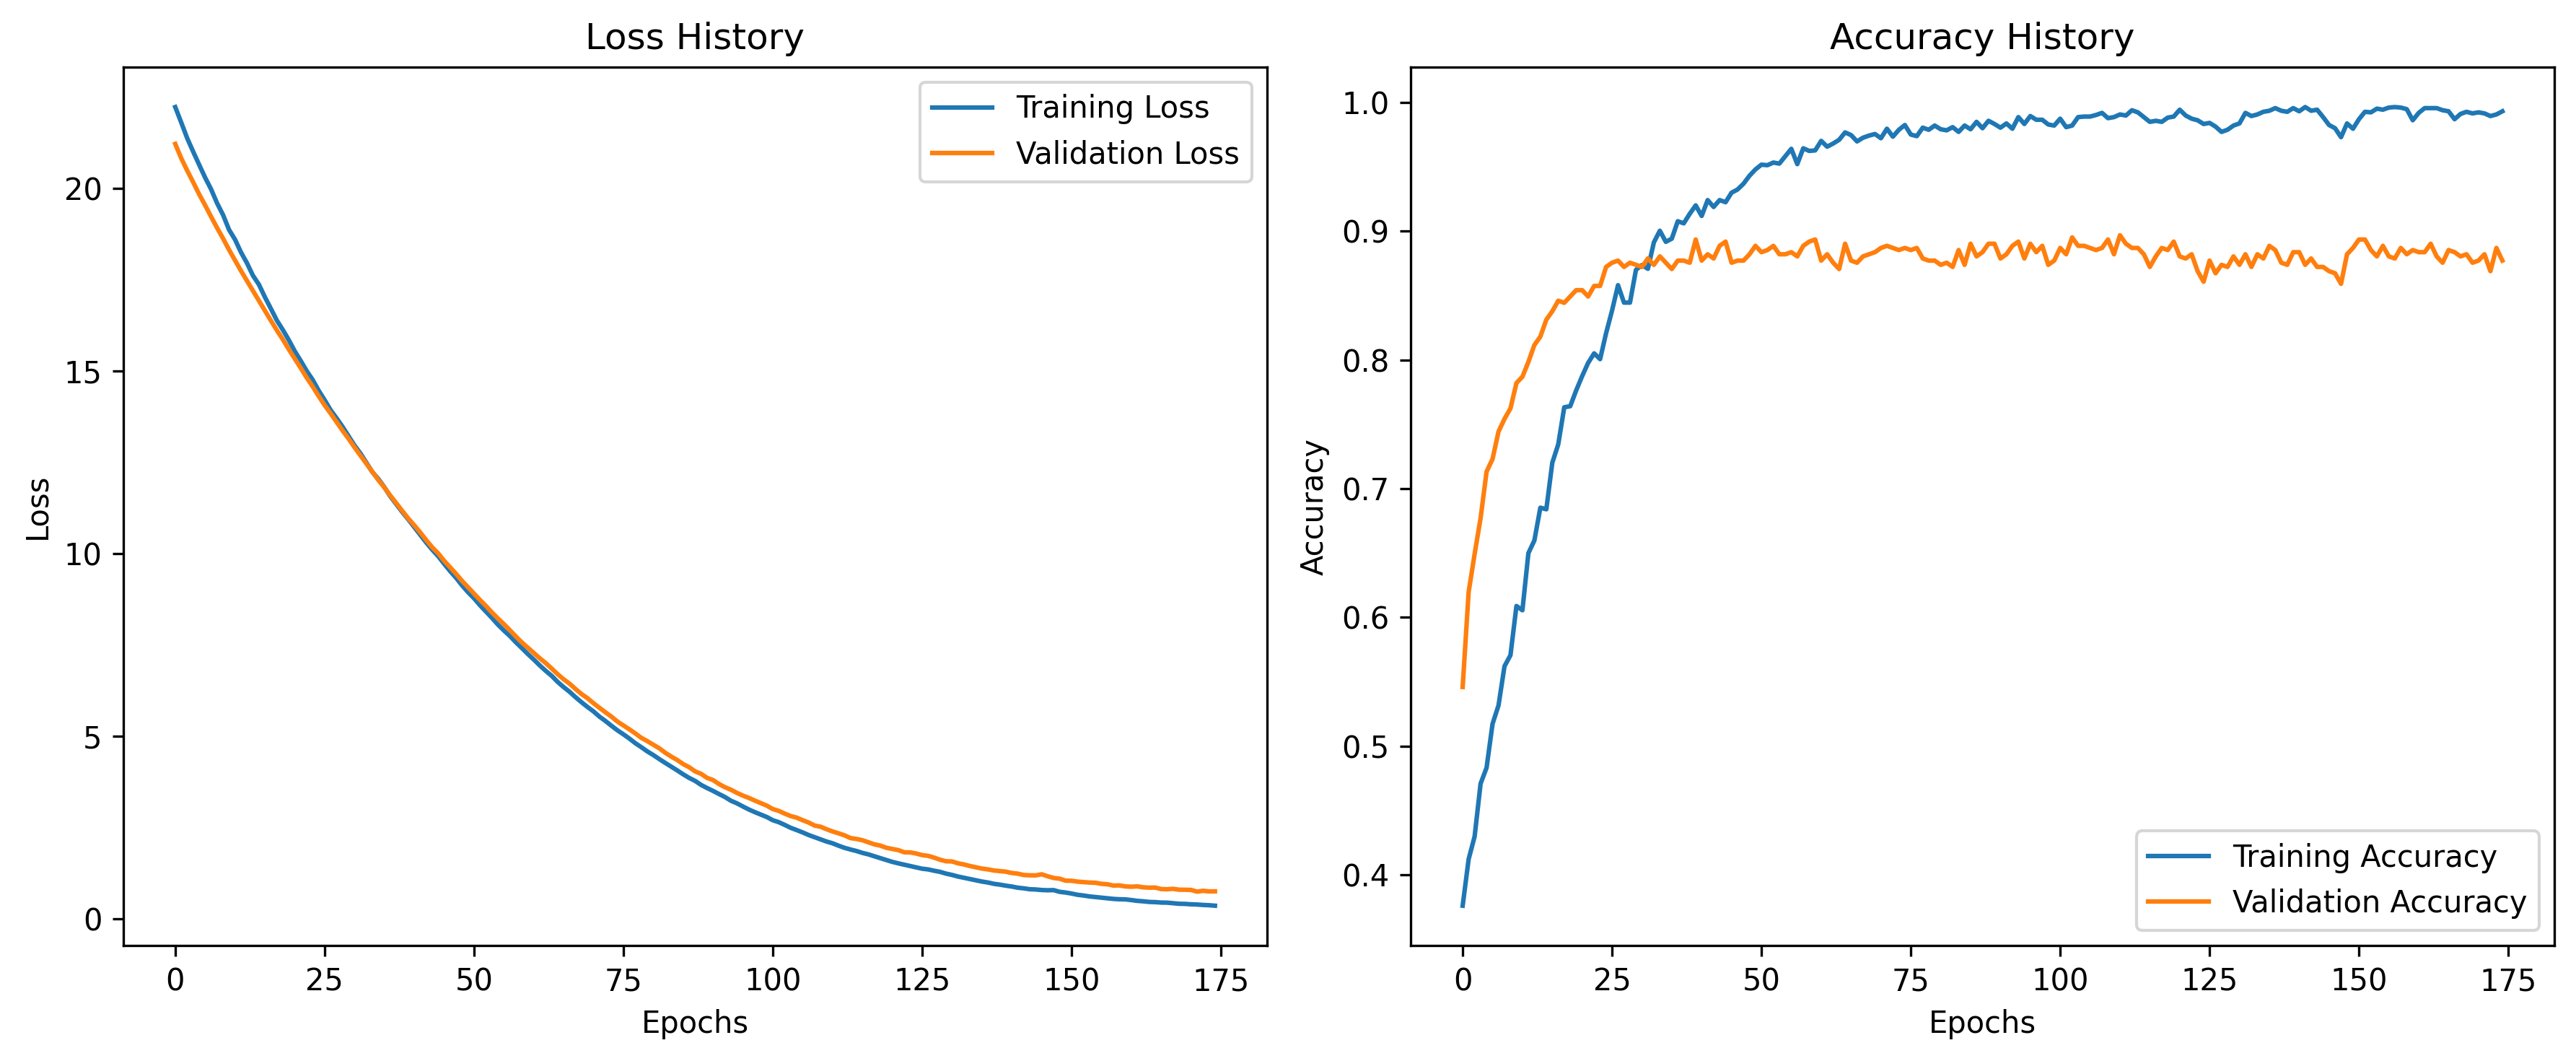

In [3]:
# # Transformer model usage

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import tensorflow as tf

# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import (
#     Input,
#     Dense,
#     Dropout,
#     LayerNormalization,
#     GlobalAveragePooling1D
# )
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.utils import to_categorical
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import (
#     accuracy_score,
#     confusion_matrix,
#     classification_report,
#     roc_auc_score,
#     average_precision_score,
#     roc_curve,
#     precision_recall_curve
# )

# # ------------------------
# # Reproducibility
# # ------------------------
# np.random.seed(42)
# tf.random.set_seed(42)

# # ------------------------
# # Load and Preprocess Data
# # ------------------------
# dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
# df = pd.read_csv(dataset_path, header=None)

# # Separate features and labels
# X = df.iloc[:, :-1].values.astype(np.float32)   # Features
# y = df.iloc[:, -1].values.astype(int)           # Labels

# # Standardize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# # Keep your original input shape
# # Shape becomes: (num_samples, 1, num_features)
# X = np.expand_dims(X, axis=1)

# # Train-Test Split with Stratification
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
# )

# # Number of classes
# num_classes = len(np.unique(y))

# # One-hot labels for ROC-AUC / PR-AUC computation
# y_train_cat = to_categorical(y_train, num_classes=num_classes)
# y_test_cat = to_categorical(y_test, num_classes=num_classes)

# print("X_train shape:", X_train.shape)
# print("X_test shape:", X_test.shape)
# print("Number of classes:", num_classes)

# # ------------------------
# # Positional Encoding Function
# # ------------------------
# def positional_encoding(length, depth):
#     """
#     Generate positional encoding for input sequences.
#     """
#     pos = np.arange(length)[:, np.newaxis]
#     i = np.arange(depth)[np.newaxis, :]
#     angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(depth))
#     angle_rads = pos * angle_rates

#     # Apply sin to even indices, cos to odd indices
#     angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
#     angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

#     return tf.convert_to_tensor(angle_rads, dtype=tf.float32)

# # ------------------------
# # Transformer Block
# # ------------------------
# class TransformerBlock(tf.keras.layers.Layer):
#     def __init__(self, embed_dim, num_heads, ff_dim, rate=0.6, l2_reg=0.05):
#         super(TransformerBlock, self).__init__()

#         # Keep your current style; key_dim=embed_dim follows your original implementation
#         self.att = tf.keras.layers.MultiHeadAttention(
#             num_heads=num_heads,
#             key_dim=embed_dim
#         )

#         self.ffn = tf.keras.Sequential([
#             Dense(
#                 ff_dim,
#                 activation="relu",
#                 kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
#             ),
#             Dense(
#                 embed_dim,
#                 kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
#             )
#         ])

#         self.layernorm1 = LayerNormalization(epsilon=1e-6)
#         self.layernorm2 = LayerNormalization(epsilon=1e-6)
#         self.dropout1 = Dropout(rate)
#         self.dropout2 = Dropout(rate)

#     def call(self, inputs, training=False):
#         attn_output = self.att(inputs, inputs, training=training)
#         attn_output = self.dropout1(attn_output, training=training)
#         out1 = self.layernorm1(inputs + attn_output)

#         ffn_output = self.ffn(out1, training=training)
#         ffn_output = self.dropout2(ffn_output, training=training)
#         return self.layernorm2(out1 + ffn_output)

# # ------------------------
# # Transformer Model
# # ------------------------
# def build_transformer(
#     input_shape,
#     num_classes,
#     embed_dim=32,
#     num_heads=4,
#     ff_dim=64,
#     num_blocks=4,
#     dropout_rate=0.6,
#     l2_reg=0.05
# ):
#     inputs = Input(shape=input_shape)

#     # Positional Encoding
#     positions = positional_encoding(input_shape[0], embed_dim)

#     # Input Projection
#     x = Dense(
#         embed_dim,
#         kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
#     )(inputs)

#     # Add positional encodings
#     x = x + positions

#     # Transformer Blocks
#     for _ in range(num_blocks):
#         x = TransformerBlock(
#             embed_dim=embed_dim,
#             num_heads=num_heads,
#             ff_dim=ff_dim,
#             rate=dropout_rate,
#             l2_reg=l2_reg
#         )(x)

#     # Classification Head
#     x = GlobalAveragePooling1D()(x)
#     x = Dropout(dropout_rate)(x)
#     outputs = Dense(
#         num_classes,
#         activation="softmax",
#         kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
#     )(x)

#     return Model(inputs, outputs)

# # ------------------------
# # Build and Train the Model
# # ------------------------
# input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)
# model = build_transformer(
#     input_shape=input_shape,
#     num_classes=num_classes,
#     embed_dim=32,
#     num_heads=4,
#     ff_dim=64,
#     num_blocks=4,
#     dropout_rate=0.6,
#     l2_reg=0.05
# )

# model.compile(
#     optimizer=Adam(learning_rate=1e-4),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

# model.summary()

# early_stopping = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=3,
#     restore_best_weights=True
# )

# history = model.fit(
#     X_train, y_train,
#     validation_split=0.2,
#     epochs=500,
#     batch_size=128,
#     callbacks=[early_stopping],
#     verbose=1
# )

# # ------------------------
# # Evaluate the Model
# # ------------------------
# y_train_proba = model.predict(X_train, verbose=0)
# y_test_proba = model.predict(X_test, verbose=0)

# y_train_pred = np.argmax(y_train_proba, axis=1)
# y_test_pred = np.argmax(y_test_proba, axis=1)

# train_accuracy = accuracy_score(y_train, y_train_pred)
# test_accuracy = accuracy_score(y_test, y_test_pred)

# print(f"\nTraining Accuracy: {train_accuracy:.4f}")
# print(f"Testing Accuracy: {test_accuracy:.4f}")

# print("\nClassification Report (Test Set):")
# print(classification_report(y_test, y_test_pred, digits=4))

# # ------------------------
# # AUC-ROC and AUC-PRC
# # ------------------------
# # Multiclass One-vs-Rest
# roc_auc_macro = roc_auc_score(
#     y_test_cat, y_test_proba, multi_class="ovr", average="macro"
# )
# roc_auc_weighted = roc_auc_score(
#     y_test_cat, y_test_proba, multi_class="ovr", average="weighted"
# )

# pr_auc_macro = average_precision_score(
#     y_test_cat, y_test_proba, average="macro"
# )
# pr_auc_weighted = average_precision_score(
#     y_test_cat, y_test_proba, average="weighted"
# )

# print(f"\nMacro ROC-AUC (OvR): {roc_auc_macro:.4f}")
# print(f"Weighted ROC-AUC (OvR): {roc_auc_weighted:.4f}")
# print(f"Macro PR-AUC: {pr_auc_macro:.4f}")
# print(f"Weighted PR-AUC: {pr_auc_weighted:.4f}")

# print("\nPer-class ROC-AUC and PR-AUC:")
# for i in range(num_classes):
#     class_roc_auc = roc_auc_score(y_test_cat[:, i], y_test_proba[:, i])
#     class_pr_auc = average_precision_score(y_test_cat[:, i], y_test_proba[:, i])
#     print(f"Class {i}: ROC-AUC = {class_roc_auc:.4f}, PR-AUC = {class_pr_auc:.4f}")

# # ------------------------
# # Plot Confusion Matrix
# # ------------------------
# conf_matrix = confusion_matrix(y_test, y_test_pred)

# plt.figure(figsize=(6, 5), dpi=300)
# sns.heatmap(
#     conf_matrix,
#     annot=True,
#     fmt='d',
#     cmap="Blues",
#     xticklabels=range(num_classes),
#     yticklabels=range(num_classes)
# )
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix")
# plt.tight_layout()
# plt.show()

# # ------------------------
# # Plot ROC Curves
# # ------------------------
# plt.figure(figsize=(7, 6), dpi=300)

# for i in range(num_classes):
#     fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_test_proba[:, i])
#     auc_i = roc_auc_score(y_test_cat[:, i], y_test_proba[:, i])
#     plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc_i:.3f})")

# plt.plot([0, 1], [0, 1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("One-vs-Rest ROC Curves")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # ------------------------
# # Plot Precision-Recall Curves
# # ------------------------
# plt.figure(figsize=(7, 6), dpi=300)

# for i in range(num_classes):
#     precision, recall, _ = precision_recall_curve(y_test_cat[:, i], y_test_proba[:, i])
#     ap_i = average_precision_score(y_test_cat[:, i], y_test_proba[:, i])
#     plt.plot(recall, precision, label=f"Class {i} (AP = {ap_i:.3f})")

# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.title("One-vs-Rest Precision-Recall Curves")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # ------------------------
# # Plot Training History
# # ------------------------
# plt.figure(figsize=(12, 5), dpi=300)

# # Plot Loss
# plt.subplot(1, 2, 1)
# plt.plot(history.history['loss'], label='Training Loss')
# plt.plot(history.history['val_loss'], label='Validation Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Loss History')
# plt.legend()

# # Plot Accuracy
# plt.subplot(1, 2, 2)
# plt.plot(history.history['accuracy'], label='Training Accuracy')
# plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.title('Accuracy History')
# plt.legend()

# plt.tight_layout()
# plt.show()

### BiLSTM-BiGRU

X_train shape: (3046, 3800)
X_test shape: (762, 3800)
Number of classes: 3


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 3800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1, 3800)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1, 256)         │     4,023,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,320,515 (16.48 MB)

 Trainable params: 4,320,515 (16.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.5272 - loss: 24.5371 - val_accuracy: 0.7574 - val_loss: 22.3495
Epoch 2/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8023 - loss: 21.6920 - val_accuracy: 0.7934 - val_loss: 19.8448
Epoch 3/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8294 - loss: 19.2421 - val_accuracy: 0.8164 - val_loss: 17.6258
Epoch 4/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8679 - loss: 17.0656 - val_accuracy: 0.8328 - val_loss: 15.6654
Epoch 5/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9014 - loss: 15.1444 - val_accuracy: 0.8475 - val_loss: 13.9360
Epoch 6/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9108 - loss: 13.4454 - val_accuracy: 0.8639 - val_loss: 12.4096
Epoch 7/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9281 - loss: 11.9472 - val_accuracy: 0.8656 - val_loss: 11.0623
Epoch 8/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9407 - loss: 10.6264 -

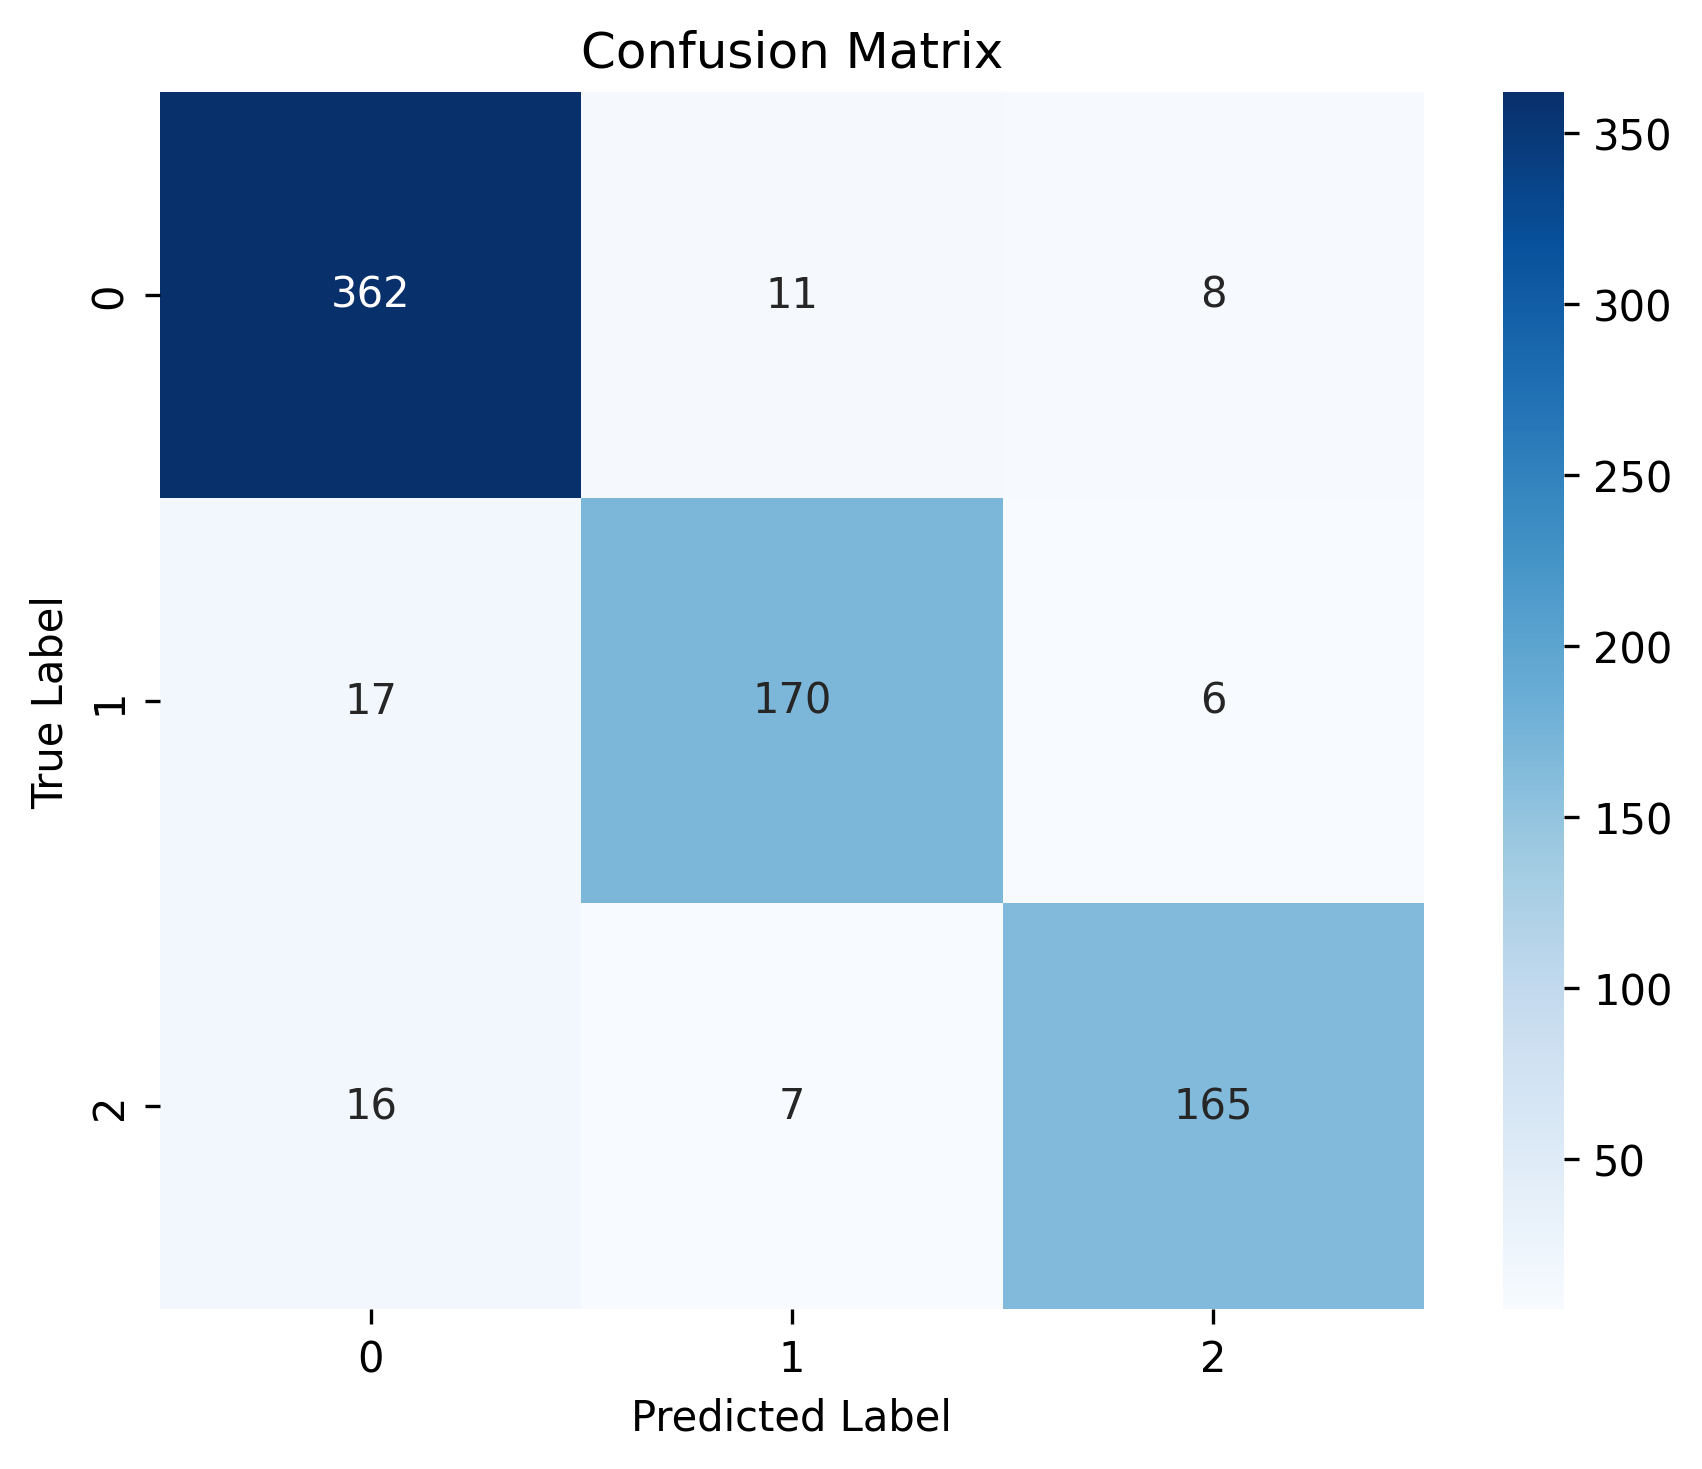

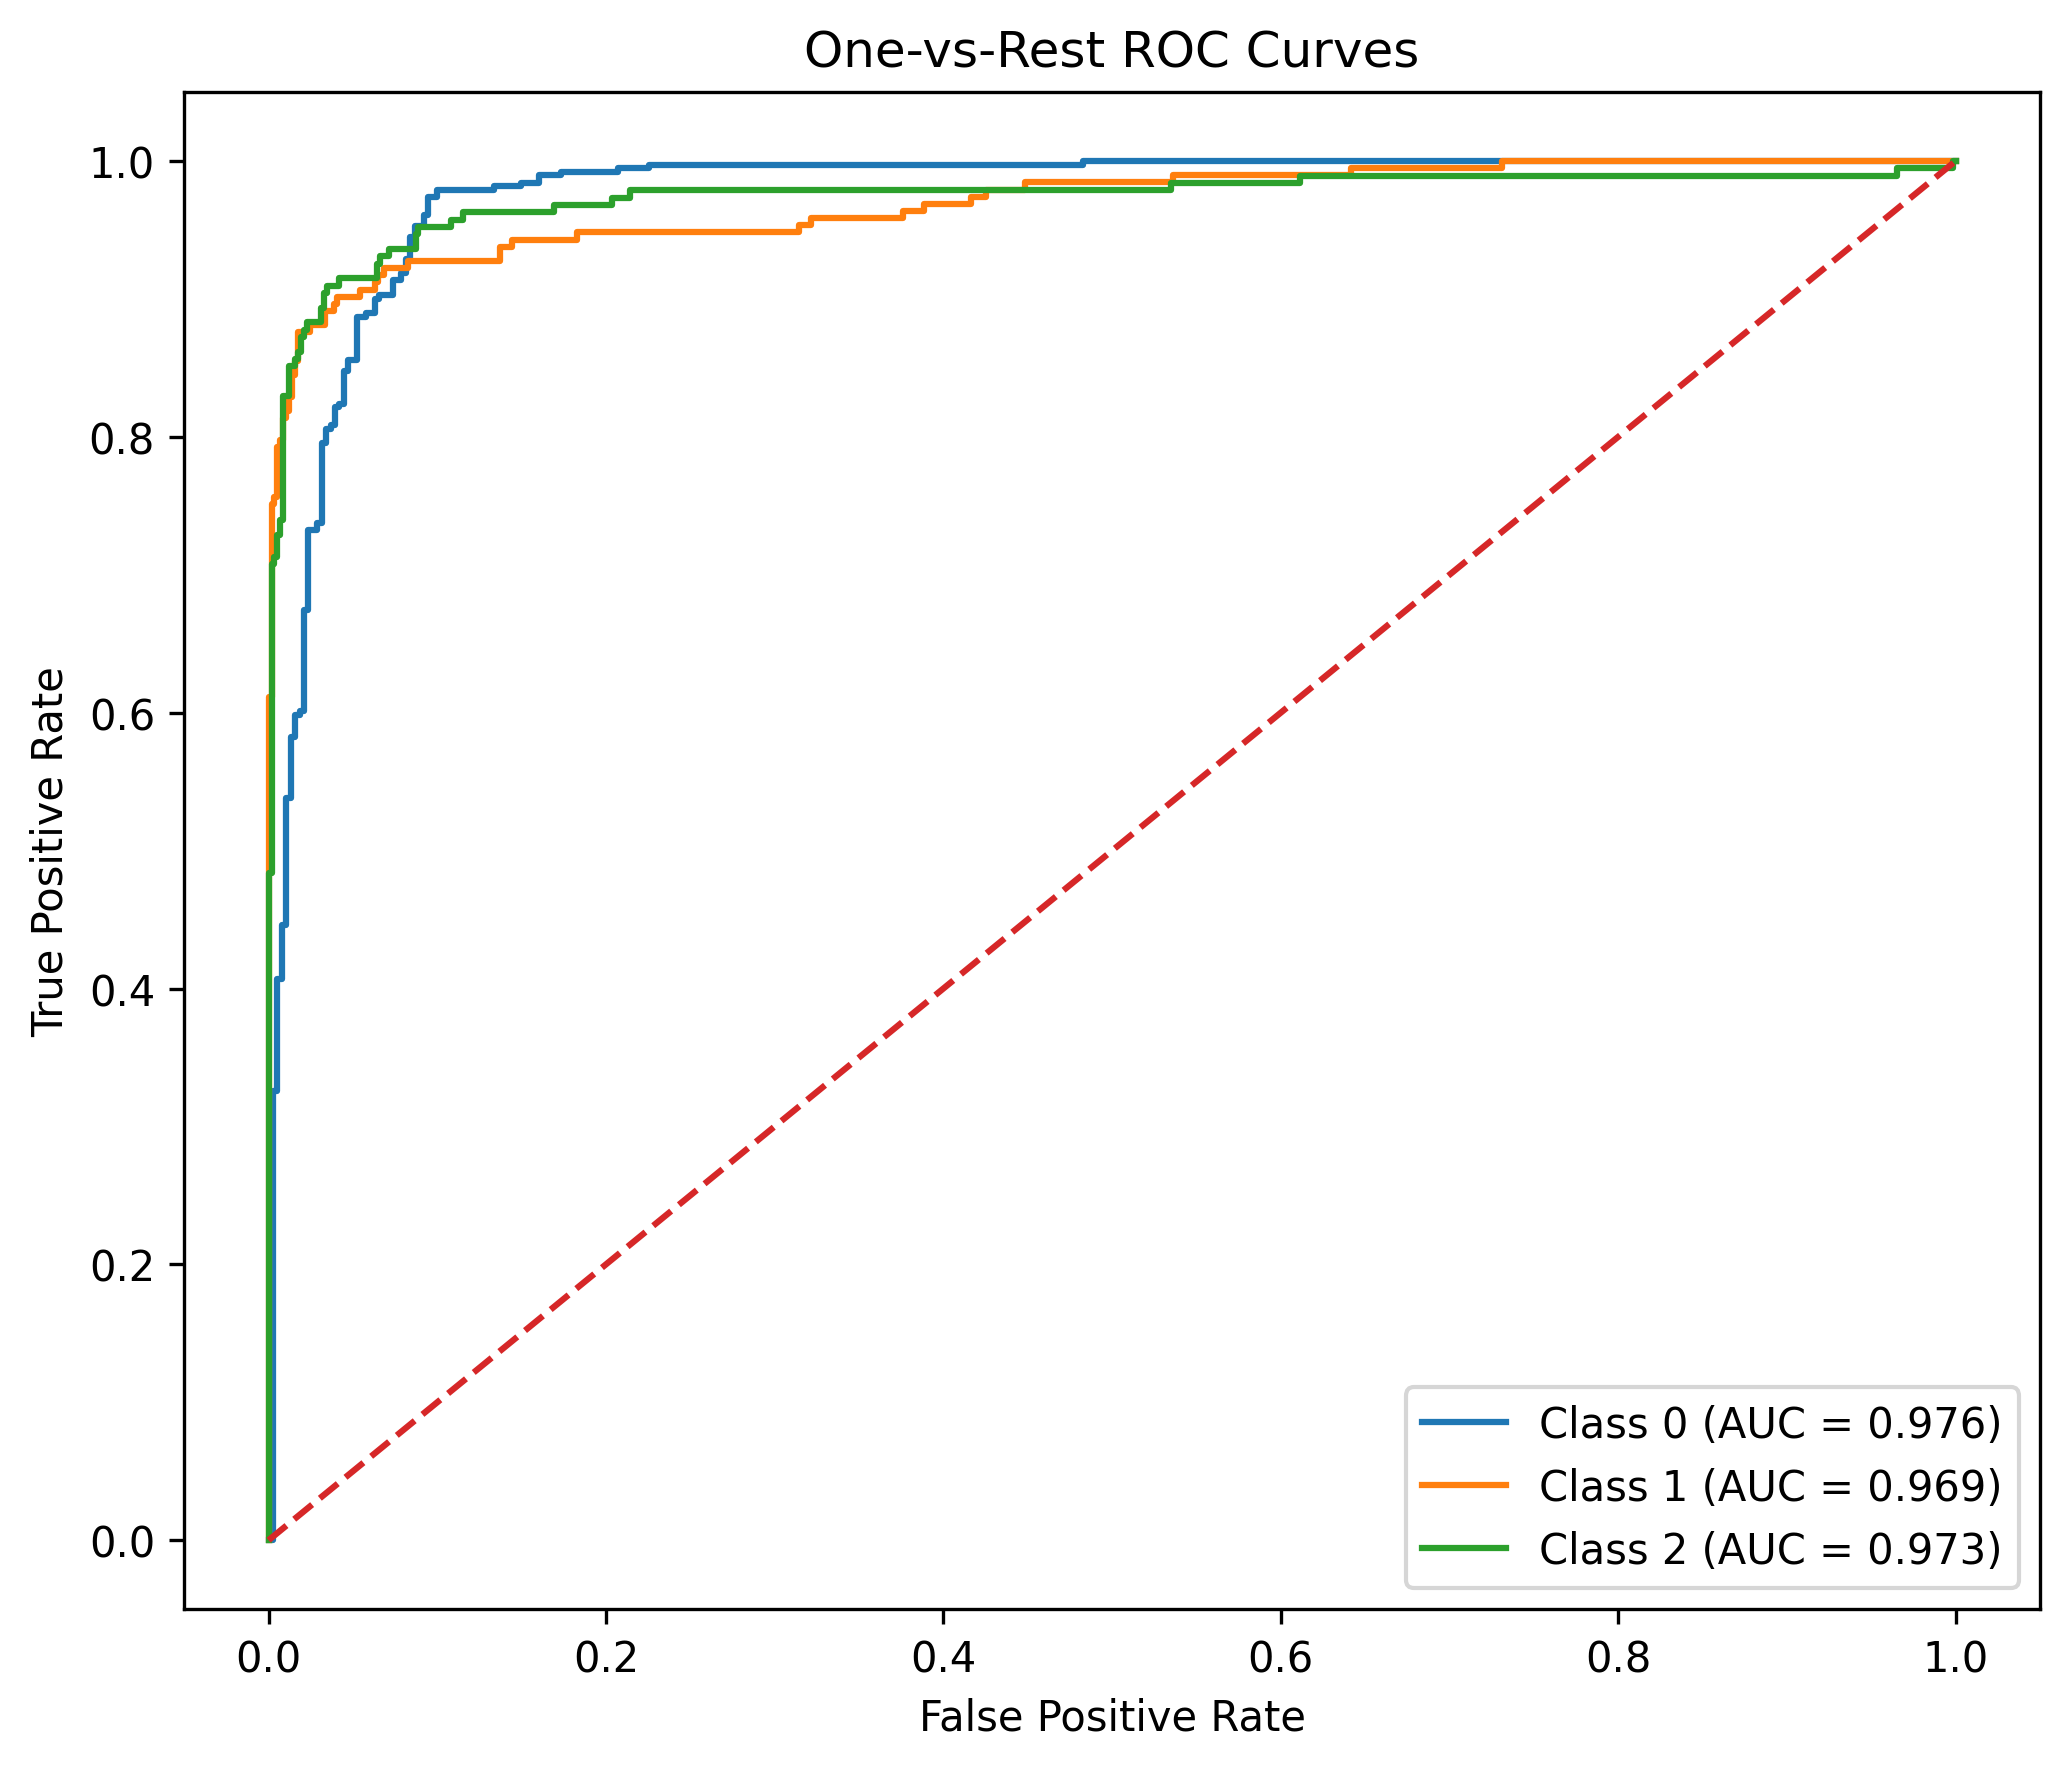

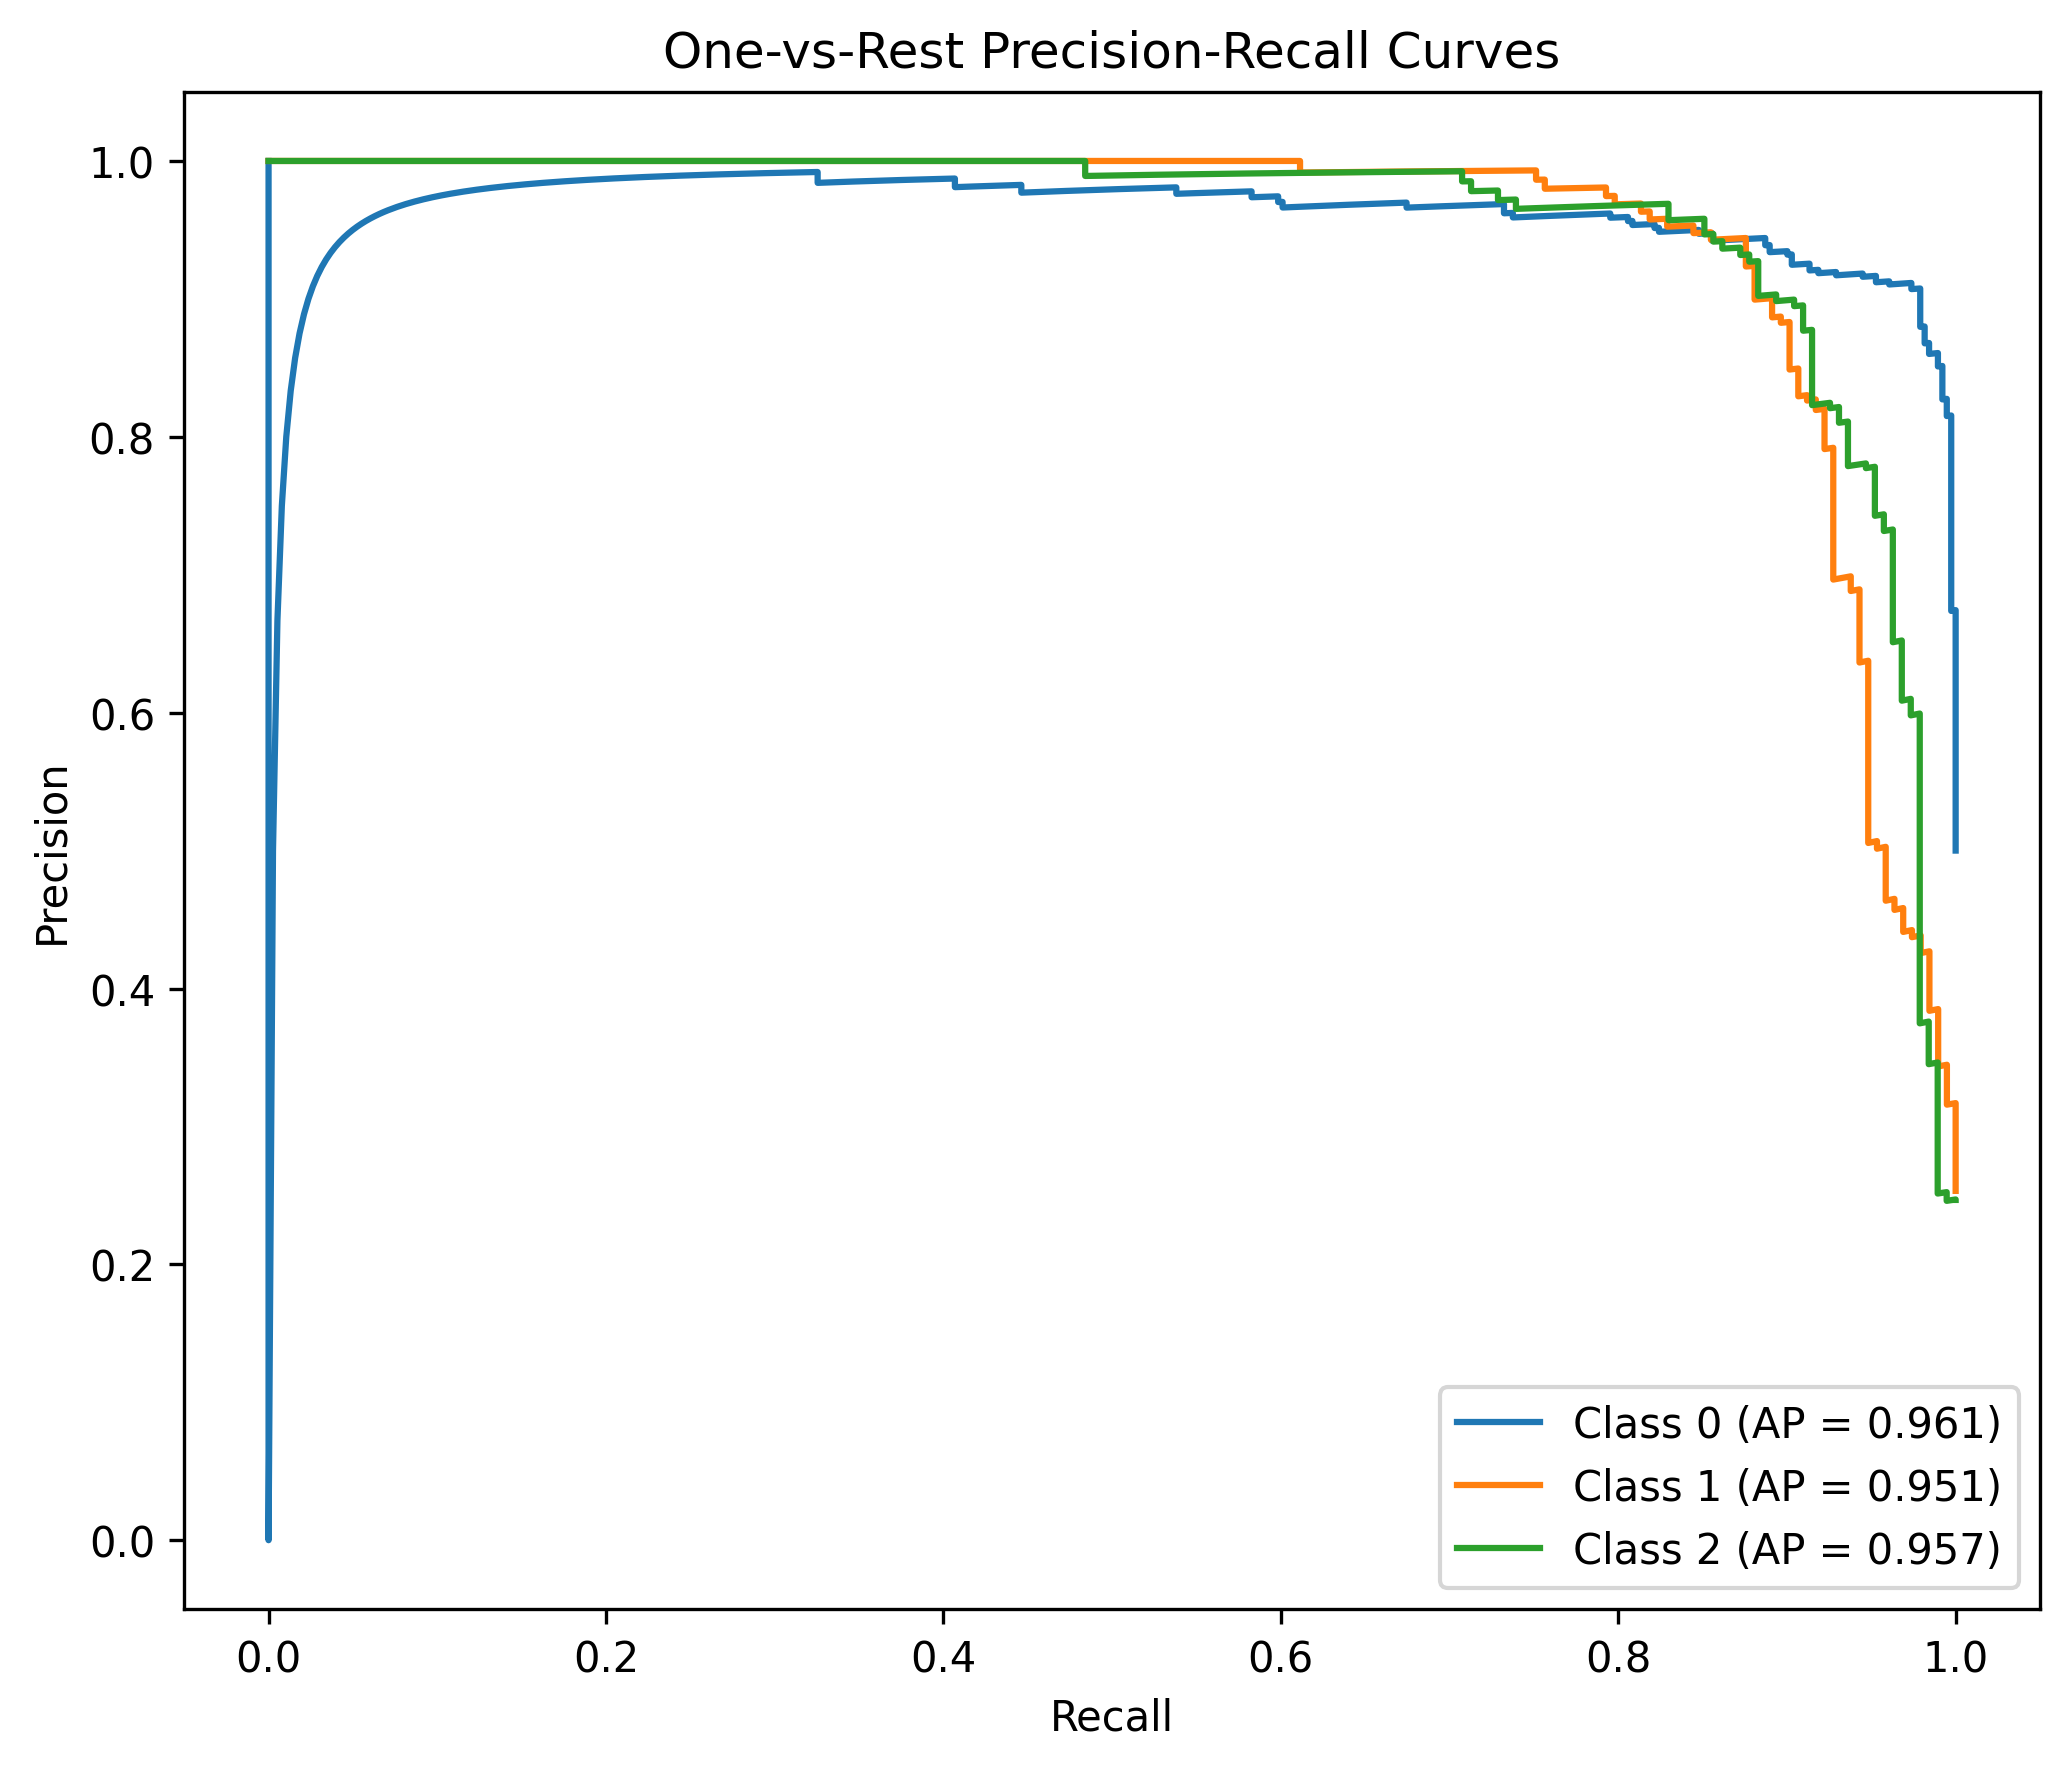

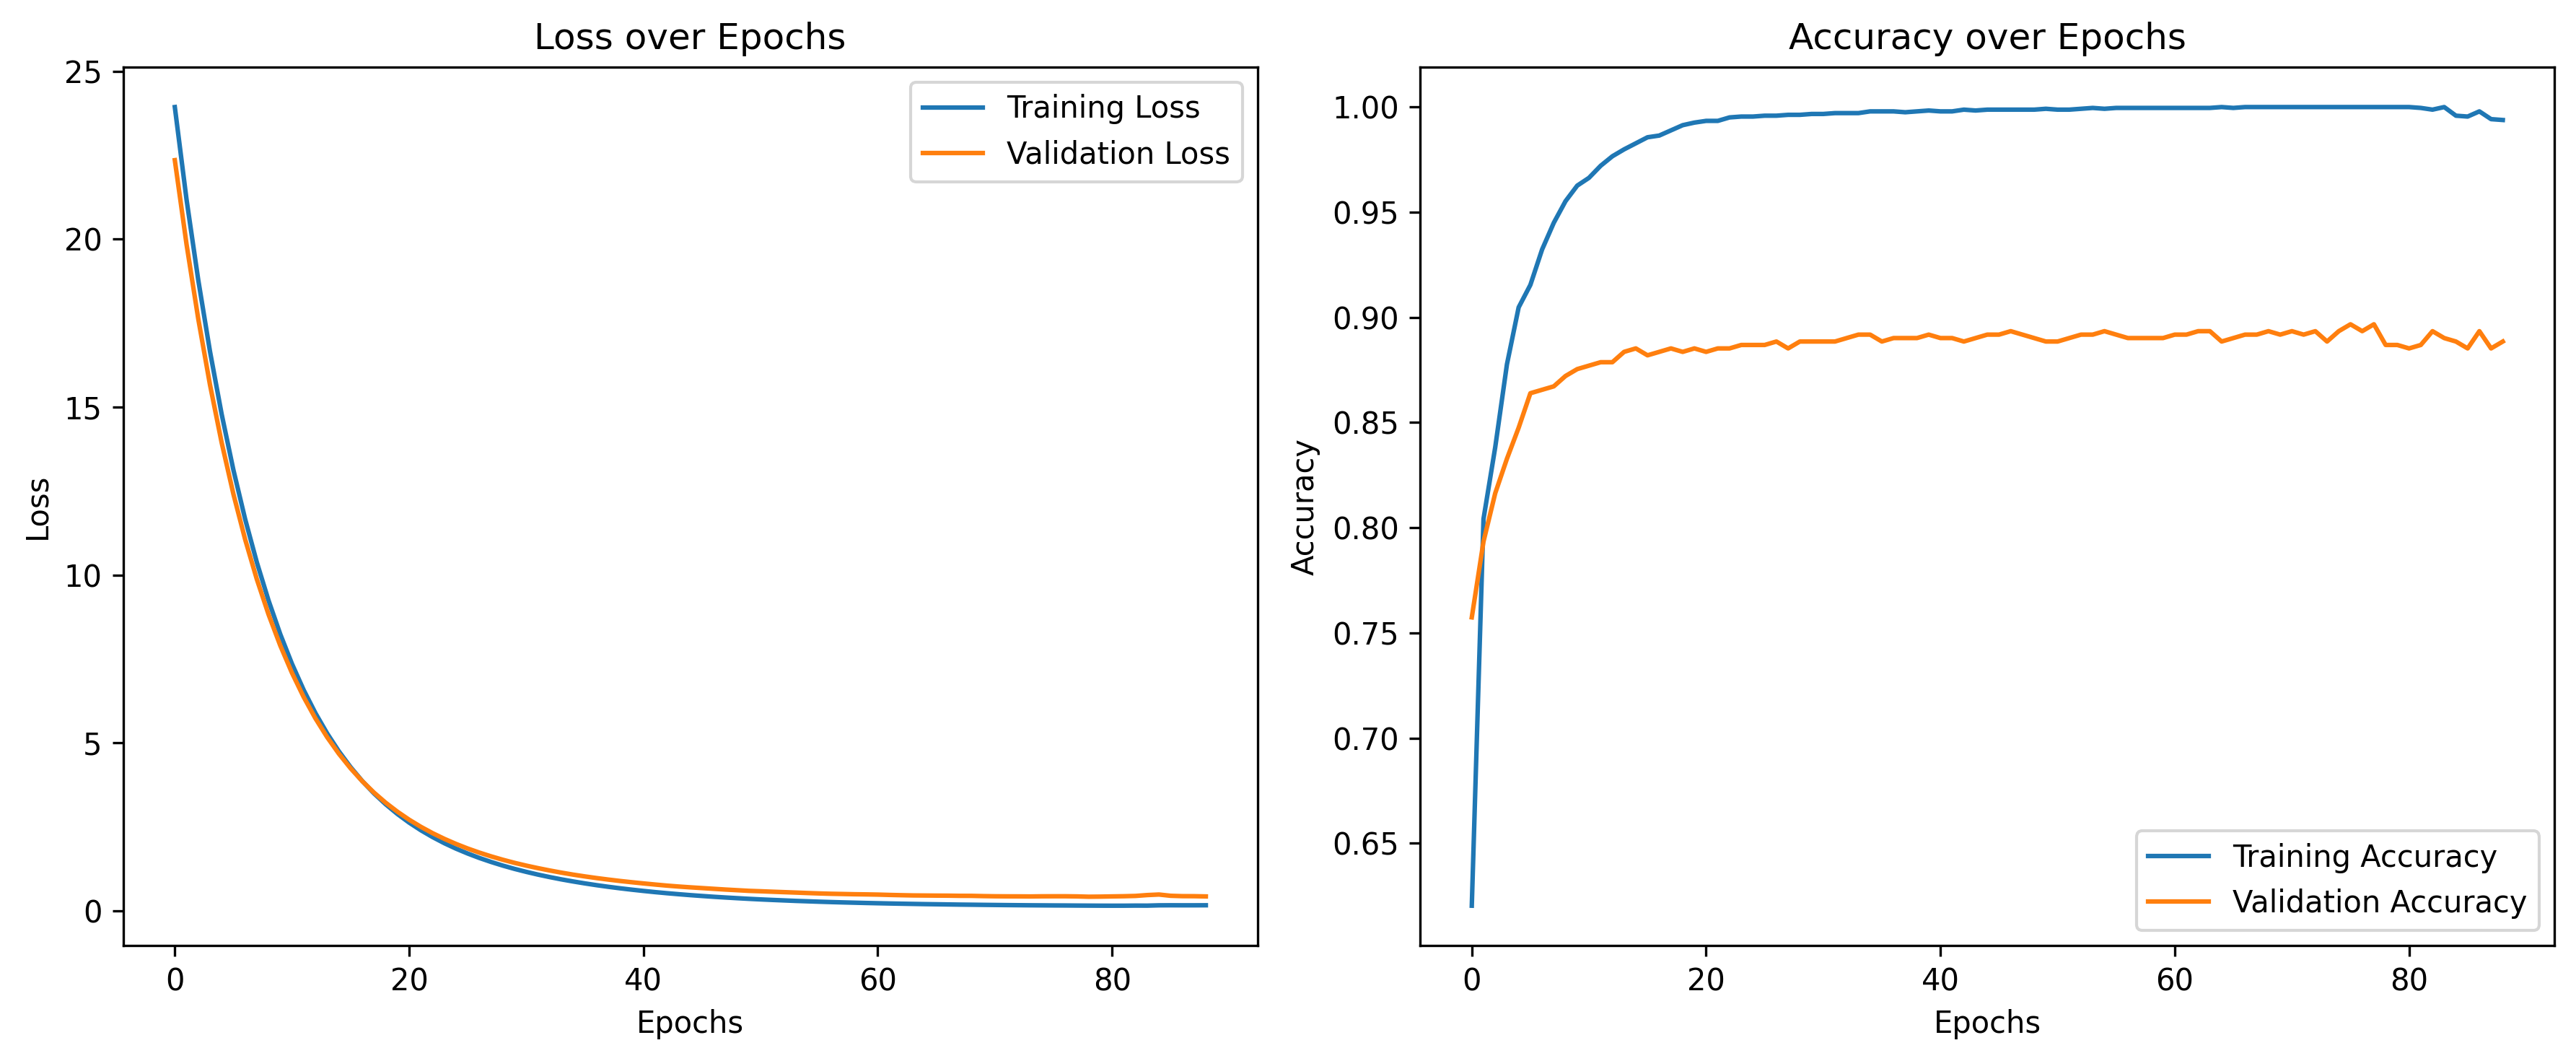

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Bidirectional, LSTM, GRU, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

# ------------------------
# Reproducibility
# ------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"

df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values.astype(np.float32)  # Features
y = df.iloc[:, -1].values.astype(int)          # Labels

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Convert labels to categorical for AUC calculations
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of classes:", num_classes)

# ------------------------
# Build the BiLSTM-BiGRU Model
# ------------------------
def build_model(input_shape, num_classes):
    inputs = Input(shape=(input_shape,))
    
    # Expand dimensions for recurrent layers
    x = Lambda(lambda t: tf.expand_dims(t, axis=1))(inputs)
    
    # Bi-LSTM layer
    x = Bidirectional(
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01))
    )(x)
    
    # Bi-GRU layer
    x = Bidirectional(
        GRU(128, return_sequences=False, kernel_regularizer=l2(0.01))
    )(x)
    
    # Dropout layer
    x = Dropout(0.2)(x)
    
    # Output layer
    outputs = Dense(num_classes, activation="softmax")(x)
    
    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Build the model
model = build_model(X_train.shape[1], num_classes)
model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ------------------------
# Train the Model
# ------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=250,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_proba = model.predict(X_train, verbose=0)
y_test_proba = model.predict(X_test, verbose=0)

y_train_pred = np.argmax(y_train_proba, axis=1)
y_test_pred = np.argmax(y_test_proba, axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))

# ------------------------
# AUC-ROC and AUC-PRC
# ------------------------
roc_auc_macro = roc_auc_score(
    y_test_cat, y_test_proba, multi_class="ovr", average="macro"
)
roc_auc_weighted = roc_auc_score(
    y_test_cat, y_test_proba, multi_class="ovr", average="weighted"
)

pr_auc_macro = average_precision_score(
    y_test_cat, y_test_proba, average="macro"
)
pr_auc_weighted = average_precision_score(
    y_test_cat, y_test_proba, average="weighted"
)

print(f"\nMacro ROC-AUC (OvR): {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC (OvR): {roc_auc_weighted:.4f}")
print(f"Macro PR-AUC: {pr_auc_macro:.4f}")
print(f"Weighted PR-AUC: {pr_auc_weighted:.4f}")

print("\nPer-class ROC-AUC and PR-AUC:")
for i in range(num_classes):
    class_roc_auc = roc_auc_score(y_test_cat[:, i], y_test_proba[:, i])
    class_pr_auc = average_precision_score(y_test_cat[:, i], y_test_proba[:, i])
    print(f"Class {i}: ROC-AUC = {class_roc_auc:.4f}, PR-AUC = {class_pr_auc:.4f}")

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5), dpi=300)
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------
# Plot ROC Curves
# ------------------------
plt.figure(figsize=(7, 6), dpi=300)
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_test_proba[:, i])
    auc_i = roc_auc_score(y_test_cat[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc_i:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------
# Plot Precision-Recall Curves
# ------------------------
plt.figure(figsize=(7, 6), dpi=300)
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test_cat[:, i], y_test_proba[:, i])
    ap_i = average_precision_score(y_test_cat[:, i], y_test_proba[:, i])
    plt.plot(recall, precision, label=f"Class {i} (AP = {ap_i:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("One-vs-Rest Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12, 5), dpi=300)

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

### EEGNet

2026-03-07 19:08:07.762768: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772910487.947352      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772910488.004405      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772910488.426430      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772910488.426467      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772910488.426470      55 computation_placer.cc:177] computation placer alr

Input shape after reshape: (3808, 19, 200, 1)
X_train shape: (3046, 19, 200, 1)
X_test shape: (762, 19, 200, 1)
Number of classes: 3


I0000 00:00:1772910518.458869      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 19, 200, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 19, 200, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 200, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 200, 16)     │           304 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 200, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 200, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 50, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 50, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 50, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 50, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 50, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           291 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 1,699 (6.64 KB)

 Non-trainable params: 80 (320.00 B)

Epoch 1/250


I0000 00:00:1772910522.343329     120 service.cc:152] XLA service 0x793564002250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772910522.343372     120 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772910522.809498     120 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772910528.031415     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 342ms/step - accuracy: 0.3713 - loss: 1.1138 - val_accuracy: 0.4443 - val_loss: 1.0974
Epoch 2/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4260 - loss: 1.0839 - val_accuracy: 0.4721 - val_loss: 1.0961
Epoch 3/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4583 - loss: 1.0758 - val_accuracy: 0.4918 - val_loss: 1.0944
Epoch 4/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4876 - loss: 1.0674 - val_accuracy: 0.5164 - val_loss: 1.0921
Epoch 5/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4983 - loss: 1.0585 - val_accuracy: 0.5230 - val_loss: 1.0892
Epoch 6/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5088 - loss: 1.0523 - val_accuracy: 0.5230 - val_loss: 1.0853
Epoch 7/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5130 - loss: 1.0440 - val_accuracy: 0.5295 - val_loss: 1.0806
Epoch 8/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5183 - loss: 1.0370 - val_accuracy: 0.5279 - val

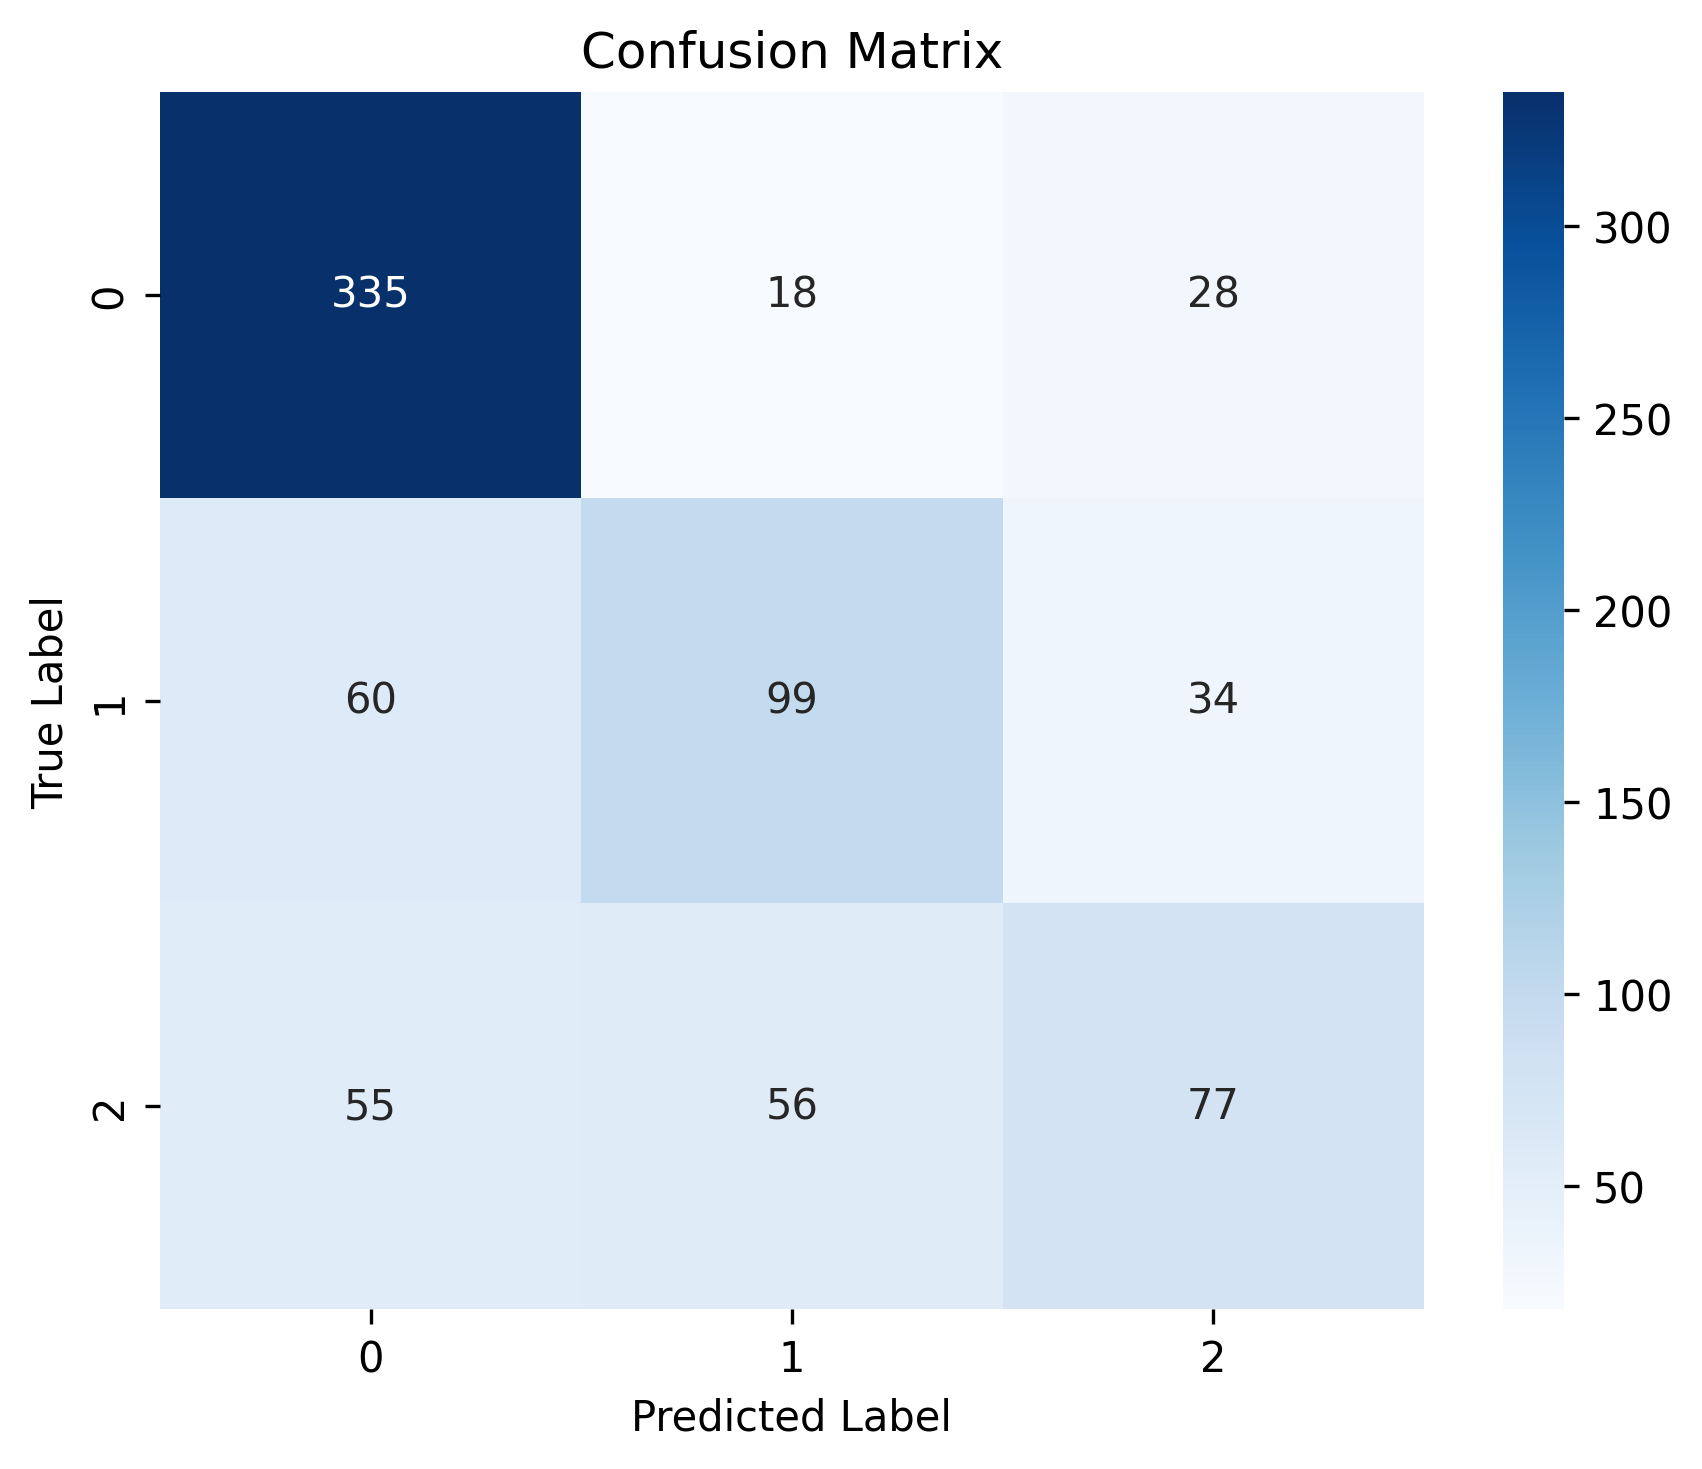

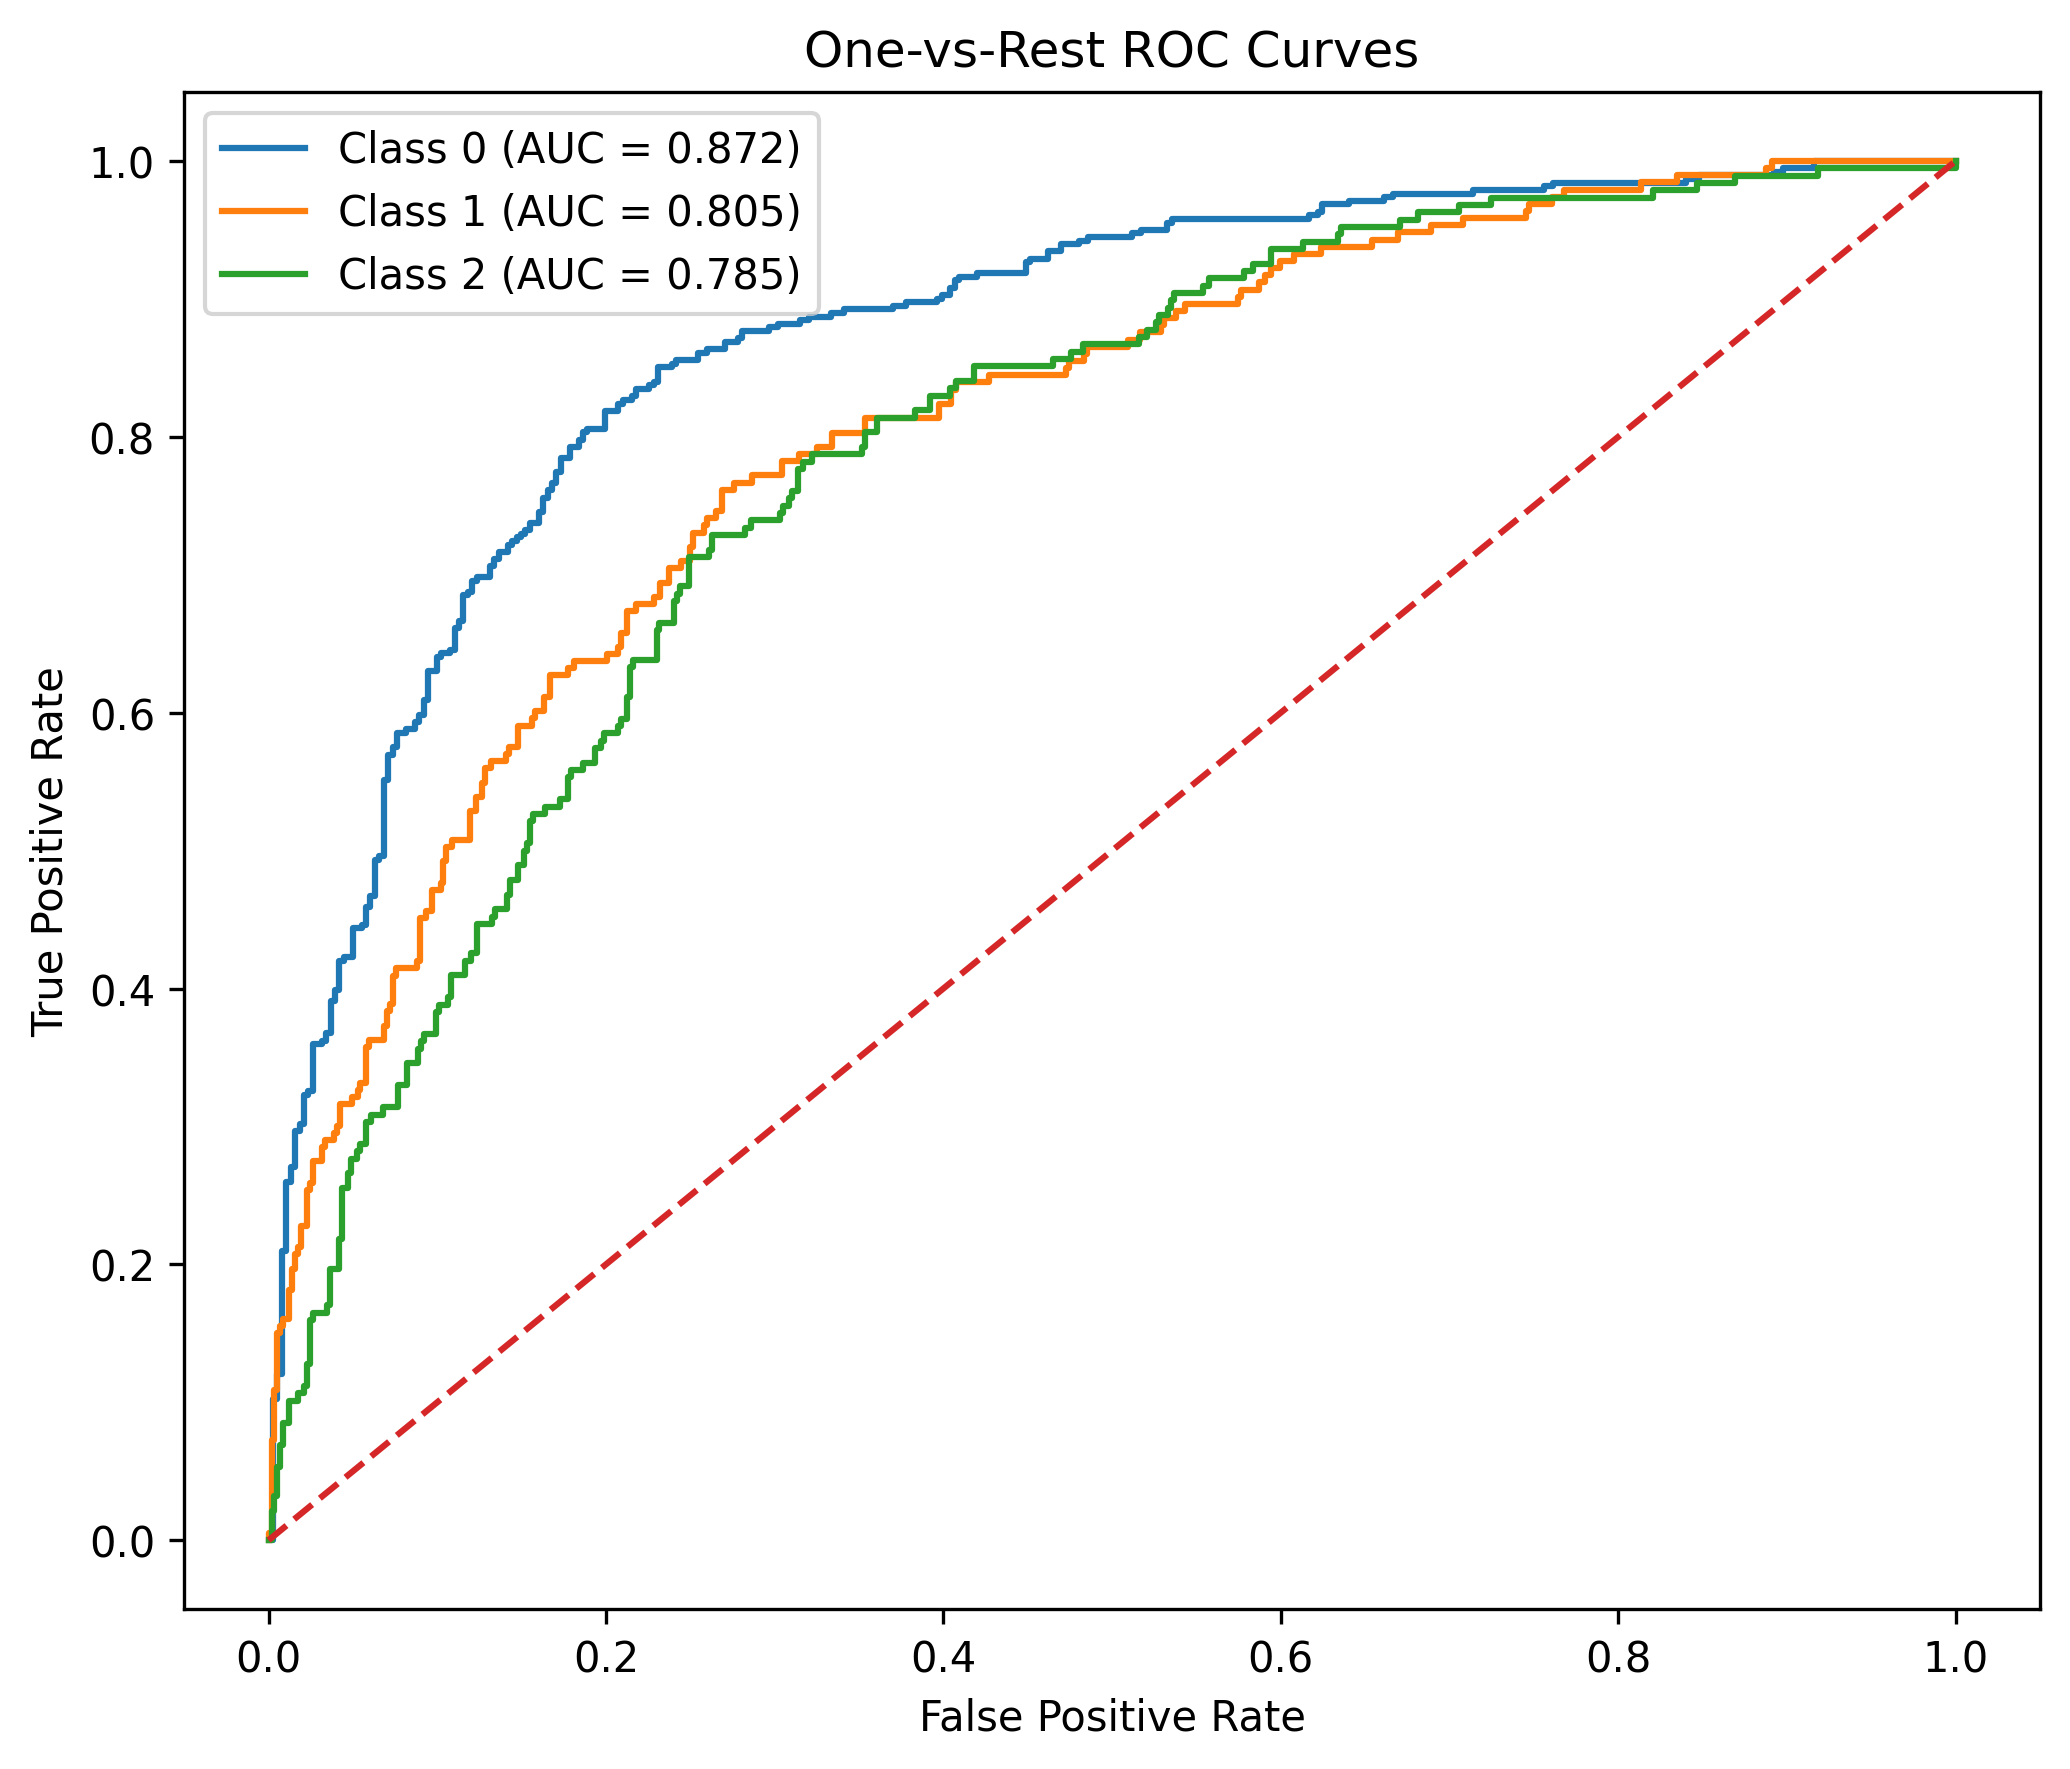

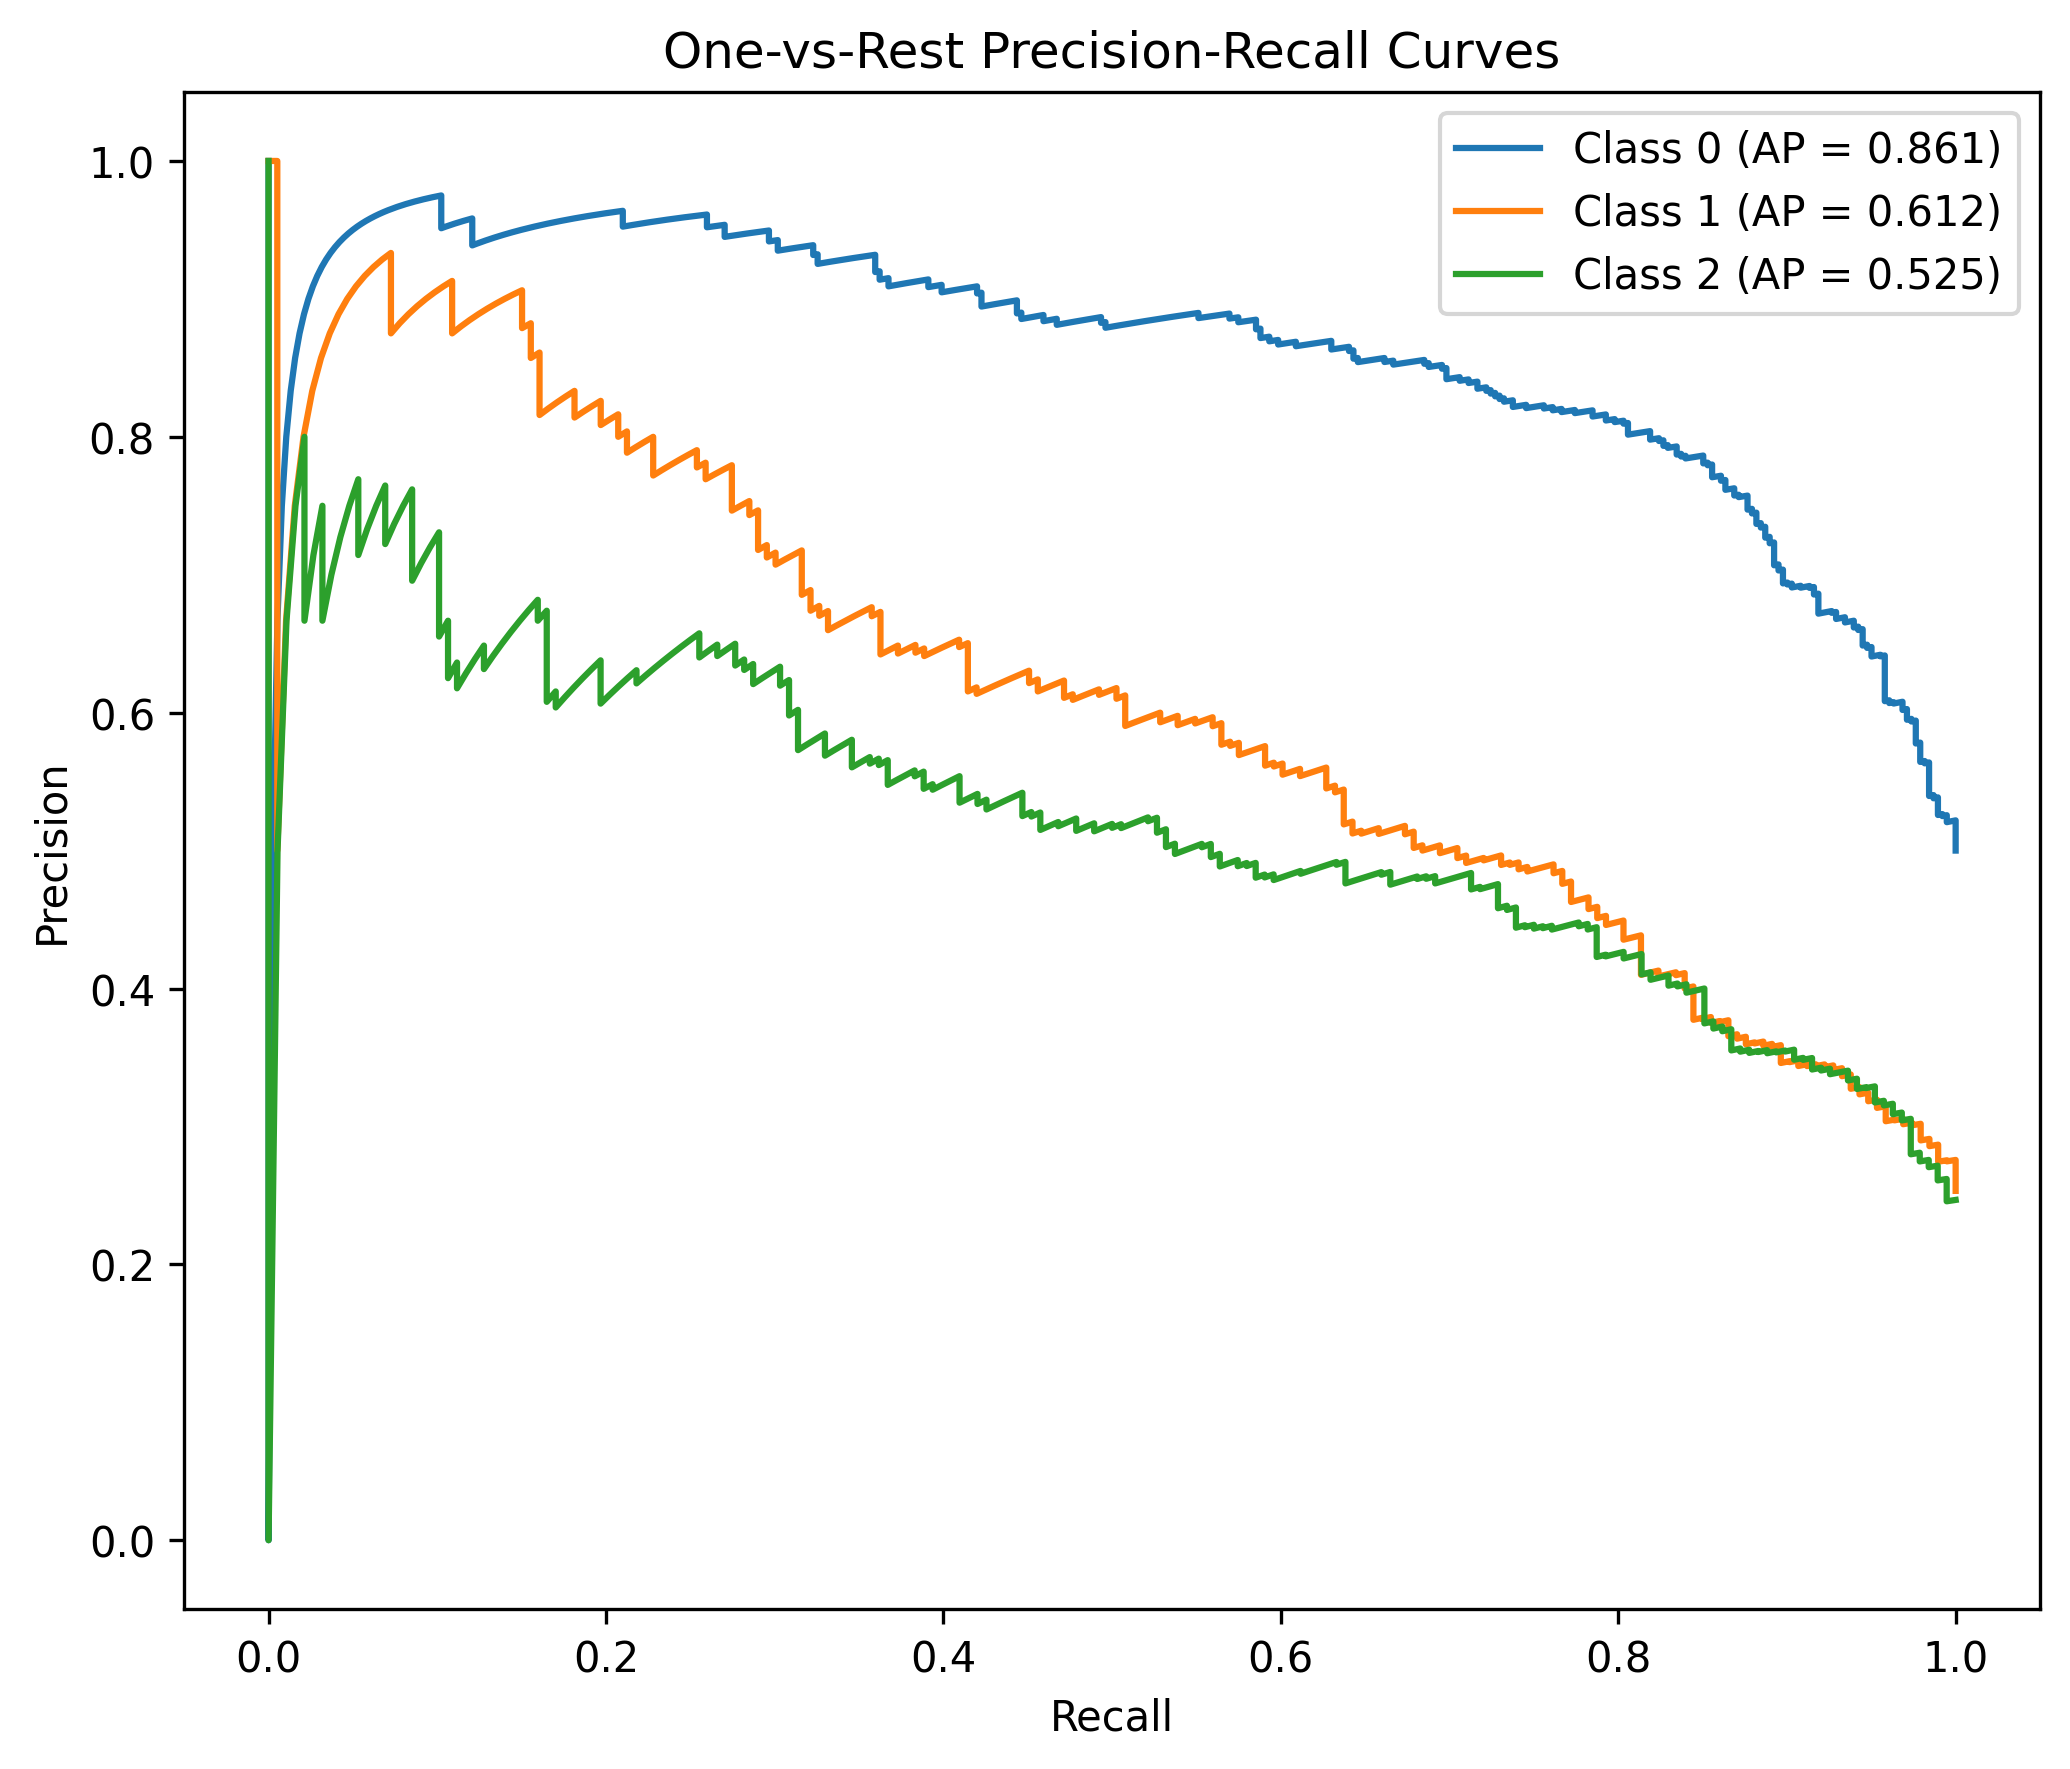

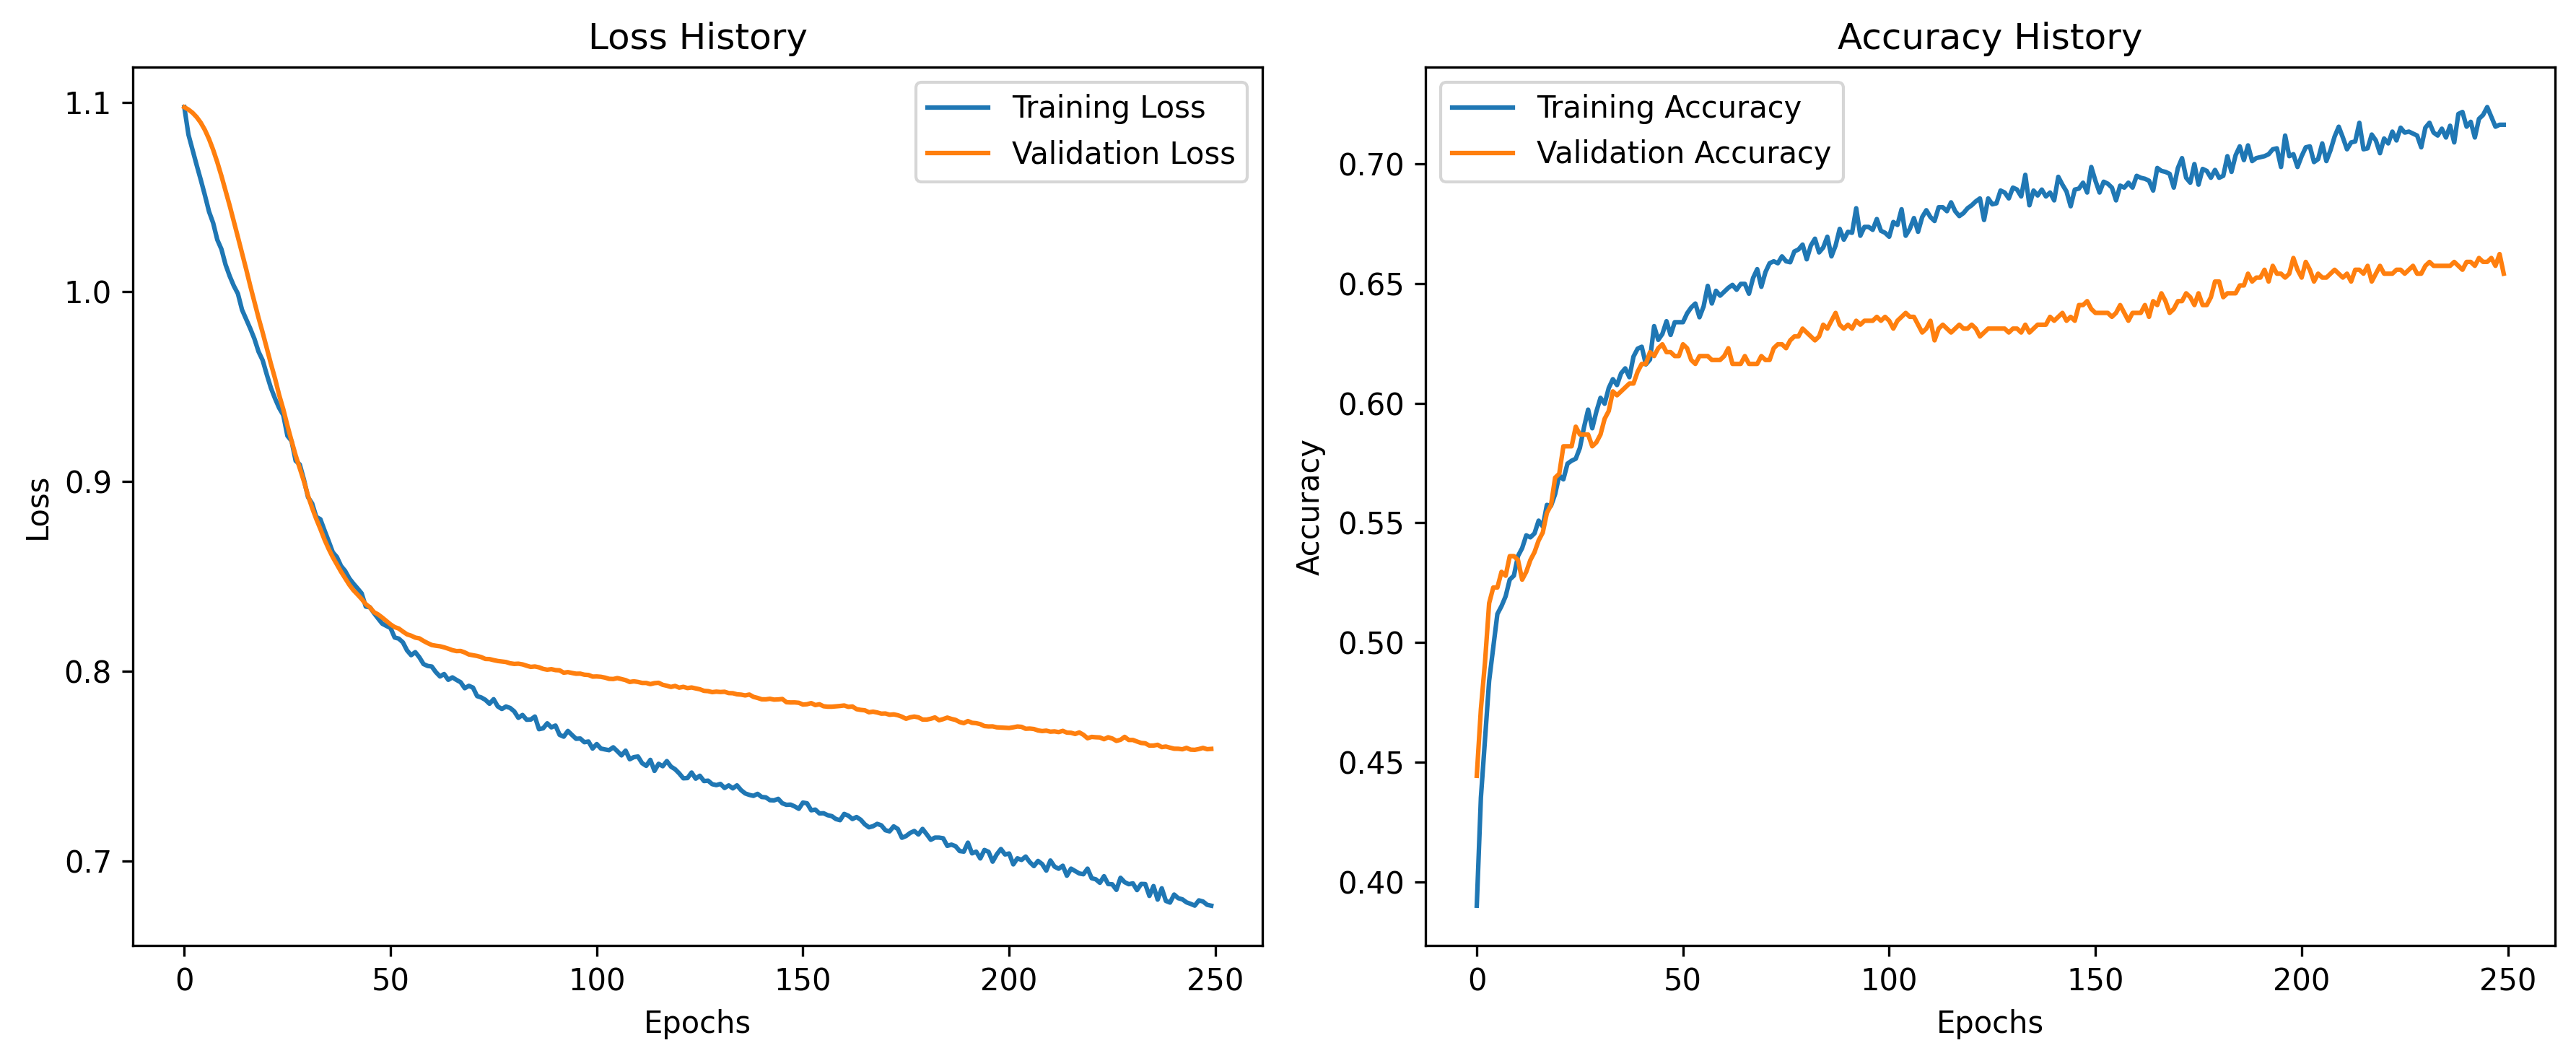

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

# ------------------------
# Reproducibility
# ------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values.astype(np.float32)  # Features
y = df.iloc[:, -1].values.astype(int)          # Labels

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape data to match EEGNet input: (Samples, Channels, Time_Points, 1)
channels = 19
time_points = X.shape[1] // channels

if X.shape[1] % channels != 0:
    raise ValueError(
        f"Total feature count {X.shape[1]} is not divisible by channels={channels}."
    )

X = X.reshape(-1, channels, time_points, 1)

print("Input shape after reshape:", X.shape)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Convert labels to categorical for AUC metrics
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of classes:", num_classes)

# ------------------------
# Define EEGNet Model
# ------------------------
def EEGNet(nb_classes, Chans=19, Samples=200, dropoutRate=0.1, kernLength=64, F1=8, D=2, F2=16):
    input1 = Input(shape=(Chans, Samples, 1))

    # First convolutional block
    block1 = Conv2D(F1, (1, kernLength), padding='same', use_bias=False)(input1)
    block1 = BatchNormalization()(block1)
    block1 = DepthwiseConv2D(
        (Chans, 1),
        use_bias=False,
        depth_multiplier=D,
        depthwise_constraint=tf.keras.constraints.MaxNorm(1.)
    )(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 4))(block1)
    block1 = Dropout(dropoutRate)(block1)

    # Second convolutional block
    block2 = SeparableConv2D(F2, (1, 16), use_bias=False, padding='same')(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 8))(block2)
    block2 = Dropout(dropoutRate)(block2)

    # Classification block
    flatten = Flatten(name='flatten')(block2)
    dense = Dense(
        nb_classes,
        name='dense',
        kernel_constraint=tf.keras.constraints.MaxNorm(0.25)
    )(flatten)
    softmax = Activation('softmax', name='softmax')(dense)

    return Model(inputs=input1, outputs=softmax)

# ------------------------
# Build and Compile EEGNet Model
# ------------------------
model = EEGNet(
    nb_classes=num_classes,
    Chans=channels,
    Samples=time_points,
    dropoutRate=0.1,
    kernLength=64,
    F1=8,
    D=2,
    F2=16
)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ------------------------
# Train the Model
# ------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=250,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_proba = model.predict(X_train, verbose=0)
y_test_proba = model.predict(X_test, verbose=0)

y_train_pred = np.argmax(y_train_proba, axis=1)
y_test_pred = np.argmax(y_test_proba, axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))

# ------------------------
# AUC-ROC and AUC-PRC
# ------------------------
roc_auc_macro = roc_auc_score(
    y_test_cat, y_test_proba, multi_class="ovr", average="macro"
)
roc_auc_weighted = roc_auc_score(
    y_test_cat, y_test_proba, multi_class="ovr", average="weighted"
)

pr_auc_macro = average_precision_score(
    y_test_cat, y_test_proba, average="macro"
)
pr_auc_weighted = average_precision_score(
    y_test_cat, y_test_proba, average="weighted"
)

print(f"\nMacro ROC-AUC (OvR): {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC (OvR): {roc_auc_weighted:.4f}")
print(f"Macro PR-AUC: {pr_auc_macro:.4f}")
print(f"Weighted PR-AUC: {pr_auc_weighted:.4f}")

print("\nPer-class ROC-AUC and PR-AUC:")
for i in range(num_classes):
    class_roc_auc = roc_auc_score(y_test_cat[:, i], y_test_proba[:, i])
    class_pr_auc = average_precision_score(y_test_cat[:, i], y_test_proba[:, i])
    print(f"Class {i}: ROC-AUC = {class_roc_auc:.4f}, PR-AUC = {class_pr_auc:.4f}")

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5), dpi=300)
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------
# Plot ROC Curves
# ------------------------
plt.figure(figsize=(7, 6), dpi=300)
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_test_proba[:, i])
    auc_i = roc_auc_score(y_test_cat[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc_i:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------
# Plot Precision-Recall Curves
# ------------------------
plt.figure(figsize=(7, 6), dpi=300)
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test_cat[:, i], y_test_proba[:, i])
    ap_i = average_precision_score(y_test_cat[:, i], y_test_proba[:, i])
    plt.plot(recall, precision, label=f"Class {i} (AP = {ap_i:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("One-vs-Rest Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12, 5), dpi=300)

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss History')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy History')
plt.legend()

plt.tight_layout()
plt.show()

### BiLSTM only

Epoch 1/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5401 - loss: 18.5516 - val_accuracy: 0.7623 - val_loss: 16.8113
Epoch 2/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8158 - loss: 16.2707 - val_accuracy: 0.8082 - val_loss: 14.9628
Epoch 3/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8785 - loss: 14.4483 - val_accuracy: 0.8295 - val_loss: 13.3482
Epoch 4/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9120 - loss: 12.8398 - val_accuracy: 0.8377 - val_loss: 11.8766
Epoch 5/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9267 - loss: 11.4022 - val_accuracy: 0.8508 - val_loss: 10.5807
Epoch 6/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9361 - loss: 10.1250 - val_accuracy: 0.8541 - val_loss: 9.4192
Epoch 7/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9471 - loss: 8.9823 - val_accuracy: 0.8557 - val_loss: 8.3848
Epoch 8/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9620 - loss: 7.9621 - val_a

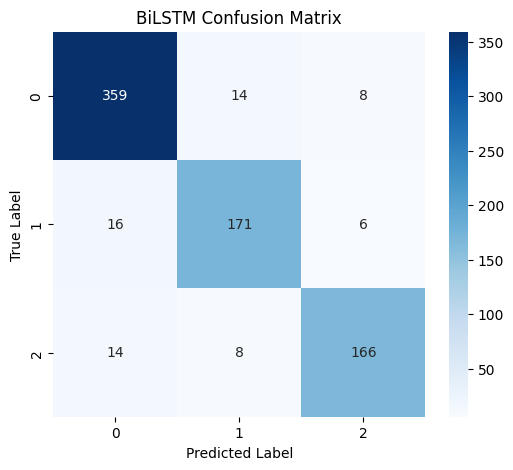

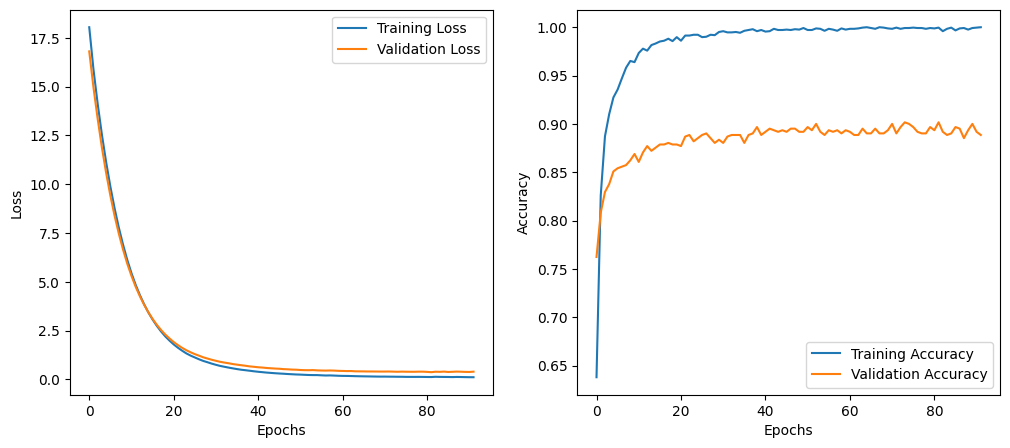

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Bidirectional, LSTM, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=42
)

# Convert labels to categorical
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ------------------------
# Define BiLSTM Model
# ------------------------
def BiLSTM_Model(input_shape, num_classes):

    inputs = Input(shape=(input_shape,))

    # Expand dimension to feed into LSTM
    x = Lambda(lambda t: tf.expand_dims(t, axis=1))(inputs)

    # BiLSTM layer
    x = Bidirectional(
        LSTM(
            128,
            return_sequences=False,
            kernel_regularizer=l2(0.01)
        )
    )(x)

    x = Dropout(0.2)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)

# ------------------------
# Build and Compile Model
# ------------------------
model = BiLSTM_Model(X_train.shape[1], num_classes)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ------------------------
# Train the Model
# ------------------------
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=250,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_proba = model.predict(X_train)
y_test_proba = model.predict(X_test)

y_train_pred = np.argmax(y_train_proba, axis=1)
y_test_pred = np.argmax(y_test_proba, axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"📌 Training Accuracy: {train_accuracy:.4f}")
print(f"📌 Testing Accuracy: {test_accuracy:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))

# ------------------------
# ROC-AUC and PR-AUC
# ------------------------
roc_auc_macro = roc_auc_score(
    y_test_cat,
    y_test_proba,
    multi_class="ovr",
    average="macro"
)

pr_auc_macro = average_precision_score(
    y_test_cat,
    y_test_proba,
    average="macro"
)

print(f"\nMacro ROC-AUC: {roc_auc_macro:.4f}")
print(f"Macro PR-AUC: {pr_auc_macro:.4f}")

print("\nPer-class ROC-AUC and PR-AUC:")

for i in range(num_classes):

    roc_auc = roc_auc_score(y_test_cat[:, i], y_test_proba[:, i])
    pr_auc = average_precision_score(y_test_cat[:, i], y_test_proba[:, i])

    print(f"Class {i}: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}")

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BiLSTM Confusion Matrix")
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### BiGRU only

2026-03-07 19:32:10.033502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772911930.218739      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772911930.269889      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772911930.699069      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772911930.699096      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772911930.699099      55 computation_placer.cc:177] computation placer alr

Epoch 1/250


I0000 00:00:1772911959.539676     161 cuda_dnn.cc:529] Loaded cuDNN version 91002


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5443 - loss: 14.5976 - val_accuracy: 0.7967 - val_loss: 13.2956
Epoch 2/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8431 - loss: 12.8883 - val_accuracy: 0.8213 - val_loss: 12.0313
Epoch 3/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8980 - loss: 11.5929 - val_accuracy: 0.8426 - val_loss: 10.9001
Epoch 4/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9337 - loss: 10.4643 - val_accuracy: 0.8410 - val_loss: 9.8837
Epoch 5/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9495 - loss: 9.4578 - val_accuracy: 0.8574 - val_loss: 8.9674
Epoch 6/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9639 - loss: 8.5496 - val_accuracy: 0.8557 - val_loss: 8.1308
Epoch 7/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9754 - loss: 7.7183 - val_accuracy: 0.8639 - val_loss: 7.3726
Epoch 8/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9758 - loss: 6.9880 - val_accuracy: 0.8738 

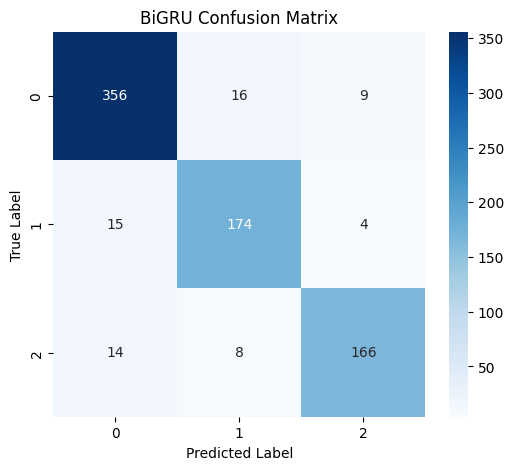

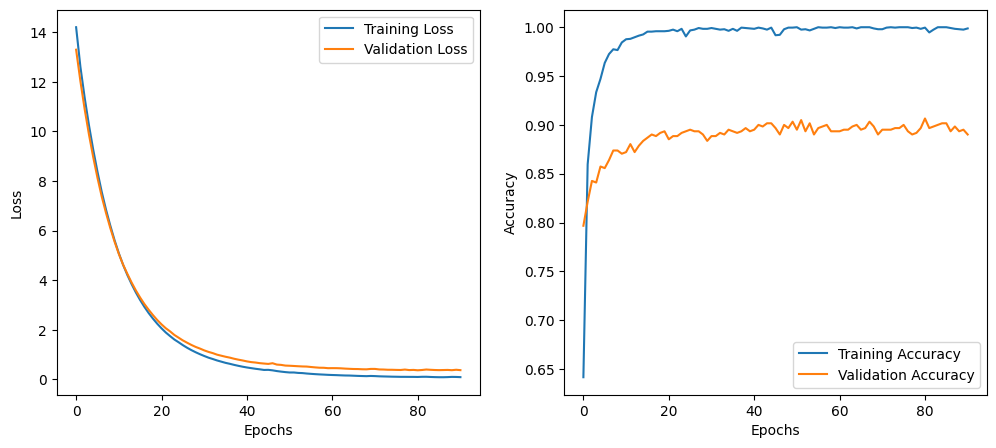

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Bidirectional, GRU, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=42
)

# Convert labels to categorical
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ------------------------
# Define BiGRU Model
# ------------------------
def BiGRU_Model(input_shape, num_classes):

    inputs = Input(shape=(input_shape,))

    # Expand dimension to feed into GRU
    x = Lambda(lambda t: tf.expand_dims(t, axis=1))(inputs)

    # BiGRU layer
    x = Bidirectional(
        GRU(
            128,
            return_sequences=False,
            kernel_regularizer=l2(0.01)
        )
    )(x)

    x = Dropout(0.2)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)

# ------------------------
# Build and Compile Model
# ------------------------
model = BiGRU_Model(X_train.shape[1], num_classes)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ------------------------
# Train the Model
# ------------------------
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=250,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_proba = model.predict(X_train)
y_test_proba = model.predict(X_test)

y_train_pred = np.argmax(y_train_proba, axis=1)
y_test_pred = np.argmax(y_test_proba, axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"📌 Training Accuracy: {train_accuracy:.4f}")
print(f"📌 Testing Accuracy: {test_accuracy:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))

# ------------------------
# ROC-AUC and PR-AUC
# ------------------------
roc_auc_macro = roc_auc_score(
    y_test_cat,
    y_test_proba,
    multi_class="ovr",
    average="macro"
)

pr_auc_macro = average_precision_score(
    y_test_cat,
    y_test_proba,
    average="macro"
)

print(f"\nMacro ROC-AUC: {roc_auc_macro:.4f}")
print(f"Macro PR-AUC: {pr_auc_macro:.4f}")

print("\nPer-class ROC-AUC and PR-AUC:")

for i in range(num_classes):
    roc_auc = roc_auc_score(y_test_cat[:, i], y_test_proba[:, i])
    pr_auc = average_precision_score(y_test_cat[:, i], y_test_proba[:, i])
    print(f"Class {i}: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}")

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BiGRU Confusion Matrix")
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### XGBoost

Training Accuracy: 0.9908
Testing Accuracy: 0.8596

Classification Report:
              precision    recall  f1-score   support

         0.0     0.8422    0.9528    0.8941       381
         1.0     0.8844    0.7927    0.8361       193
         2.0     0.8797    0.7394    0.8035       188

    accuracy                         0.8596       762
   macro avg     0.8688    0.8283    0.8445       762
weighted avg     0.8622    0.8596    0.8570       762


Macro ROC-AUC: 0.9552
Macro PR-AUC: 0.9221

Per-class ROC-AUC and PR-AUC:
Class 0: ROC-AUC=0.9584, PR-AUC=0.9496
Class 1: ROC-AUC=0.9460, PR-AUC=0.9070
Class 2: ROC-AUC=0.9612, PR-AUC=0.9097


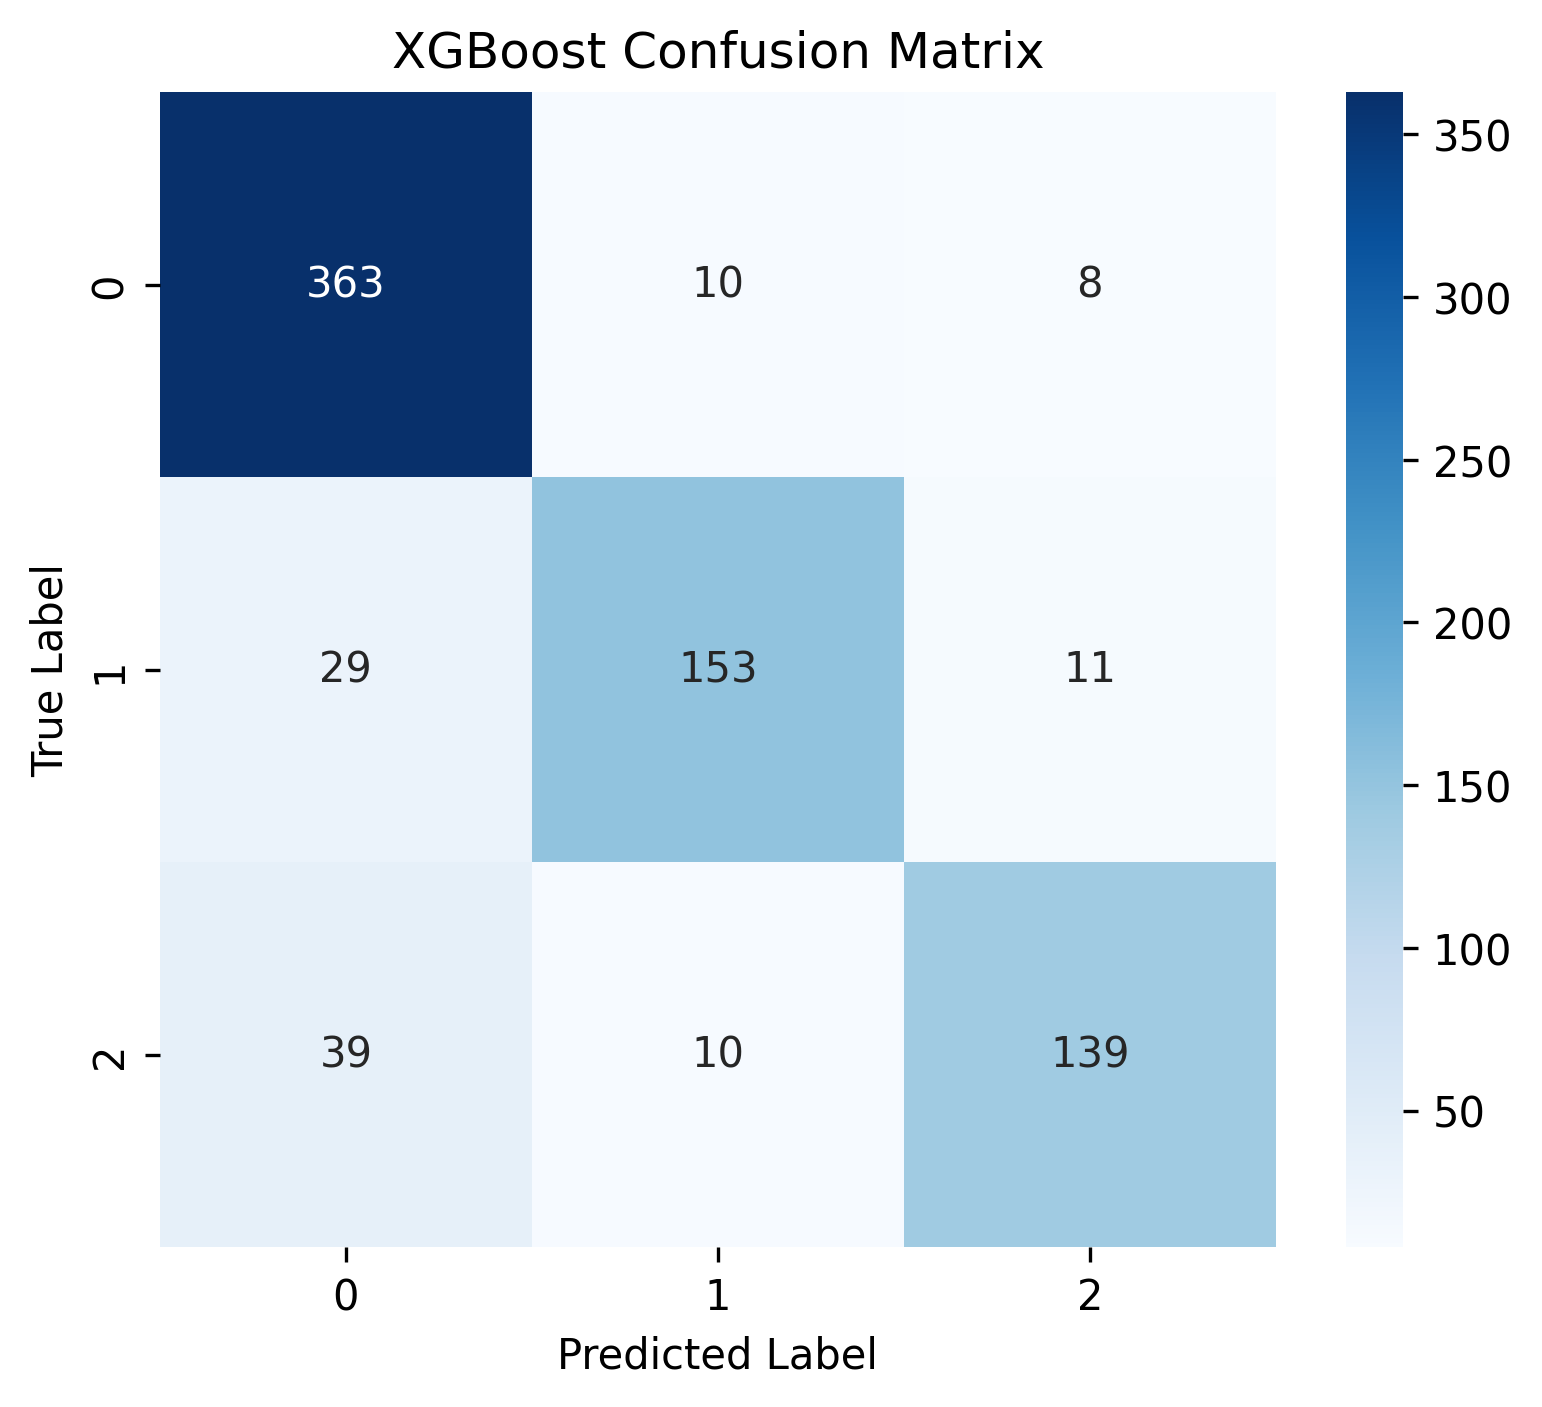

<Figure size 3000x1500 with 0 Axes>

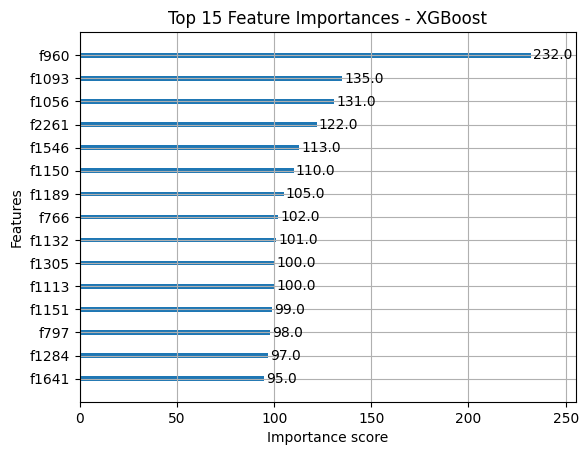

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=42
)

num_classes = len(np.unique(y))

# ------------------------
# XGBoost Model
# ------------------------
xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    learning_rate=0.01,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# ------------------------
# Train Model
# ------------------------
xgb_model.fit(X_train, y_train)

# ------------------------
# Predictions
# ------------------------
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

y_test_proba = xgb_model.predict_proba(X_test)

# ------------------------
# Accuracy
# ------------------------
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

# ------------------------
# AUC-ROC and AUC-PR
# ------------------------
y_test_bin = label_binarize(y_test, classes=np.unique(y))

roc_auc_macro = roc_auc_score(
    y_test_bin,
    y_test_proba,
    multi_class="ovr",
    average="macro"
)

pr_auc_macro = average_precision_score(
    y_test_bin,
    y_test_proba,
    average="macro"
)

print(f"\nMacro ROC-AUC: {roc_auc_macro:.4f}")
print(f"Macro PR-AUC: {pr_auc_macro:.4f}")

# ------------------------
# Per-Class AUC
# ------------------------
print("\nPer-class ROC-AUC and PR-AUC:")

for i in range(num_classes):

    roc_auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    pr_auc = average_precision_score(y_test_bin[:, i], y_test_proba[:, i])

    print(f"Class {i}: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}")

# ------------------------
# Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5), dpi=300)
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")
plt.show()

# ------------------------
# Feature Importance
# ------------------------
plt.figure(figsize=(10,5), dpi=300)
xgb.plot_importance(
    xgb_model,
    importance_type="weight",
    max_num_features=15
)
plt.title("Top 15 Feature Importances - XGBoost")
plt.show()

## Test with new model

CNN BiGRU

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 3800, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_31 (Conv1D)              │ (None, 3800, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 3800, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 1900, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 1900, 128)      │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 1900, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_20 (Add)                    │ (None, 1900, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_8             │ (None, 1900, 128)      │        99,584 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ (None, 1900, 128)      │        99,584 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_22     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_86 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_87 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,867 (862.76 KB)

 Trainable params: 220,547 (861.51 KB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/250
77/77 ━━━━━━━━━━━━━━━━━━━━ 45s 347ms/step - accuracy: 0.3806 - loss: 20.2449 - val_accuracy: 0.4934 - val_loss: 18.4290 - learning_rate: 1.0000e-04
Epoch 2/250
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.4741 - loss: 17.9004 - val_accuracy: 0.4934 - val_loss: 16.3444 - learning_rate: 1.0000e-04
Epoch 3/250
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.4957 - loss: 15.8436 - val_accuracy: 0.4934 - val_loss: 14.4725 - learning_rate: 1.0000e-04
Epoch 4/250
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.5110 - loss: 13.9964 - val_accuracy: 0.4934 - val_loss: 12.7825 - learning_rate: 1.0000e-04
Epoch 5/250
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.5169 - loss: 12.3401 - val_accuracy: 0.5033 - val_loss: 11.2735 - learning_rate: 1.0000e-04
Epoch 6/250
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.5671 - loss: 10.8274 - val_accuracy: 0.5279 - val_loss: 10.0282 - learning_rate: 1.0000e-04
Epoch 7/250
77/77 ━━━━━━━━━━━━━━━━━━━━ 1

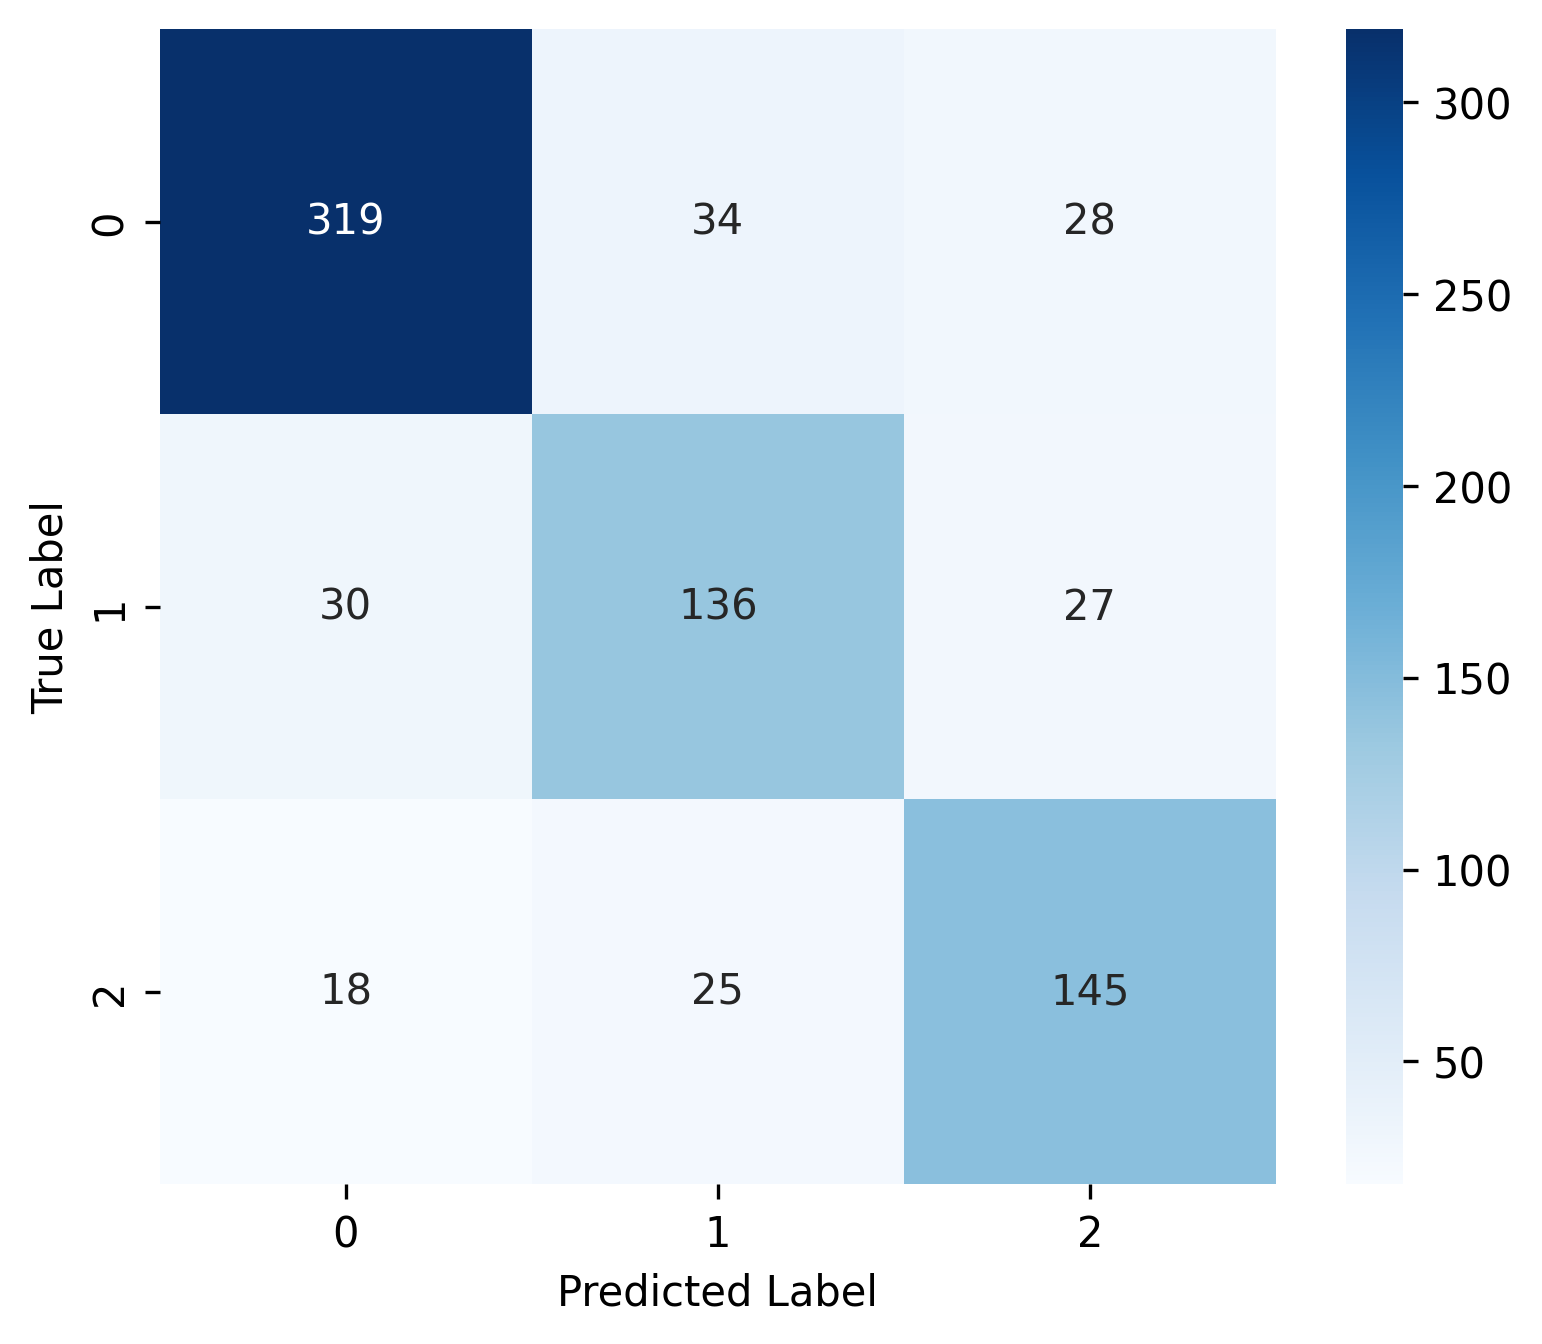

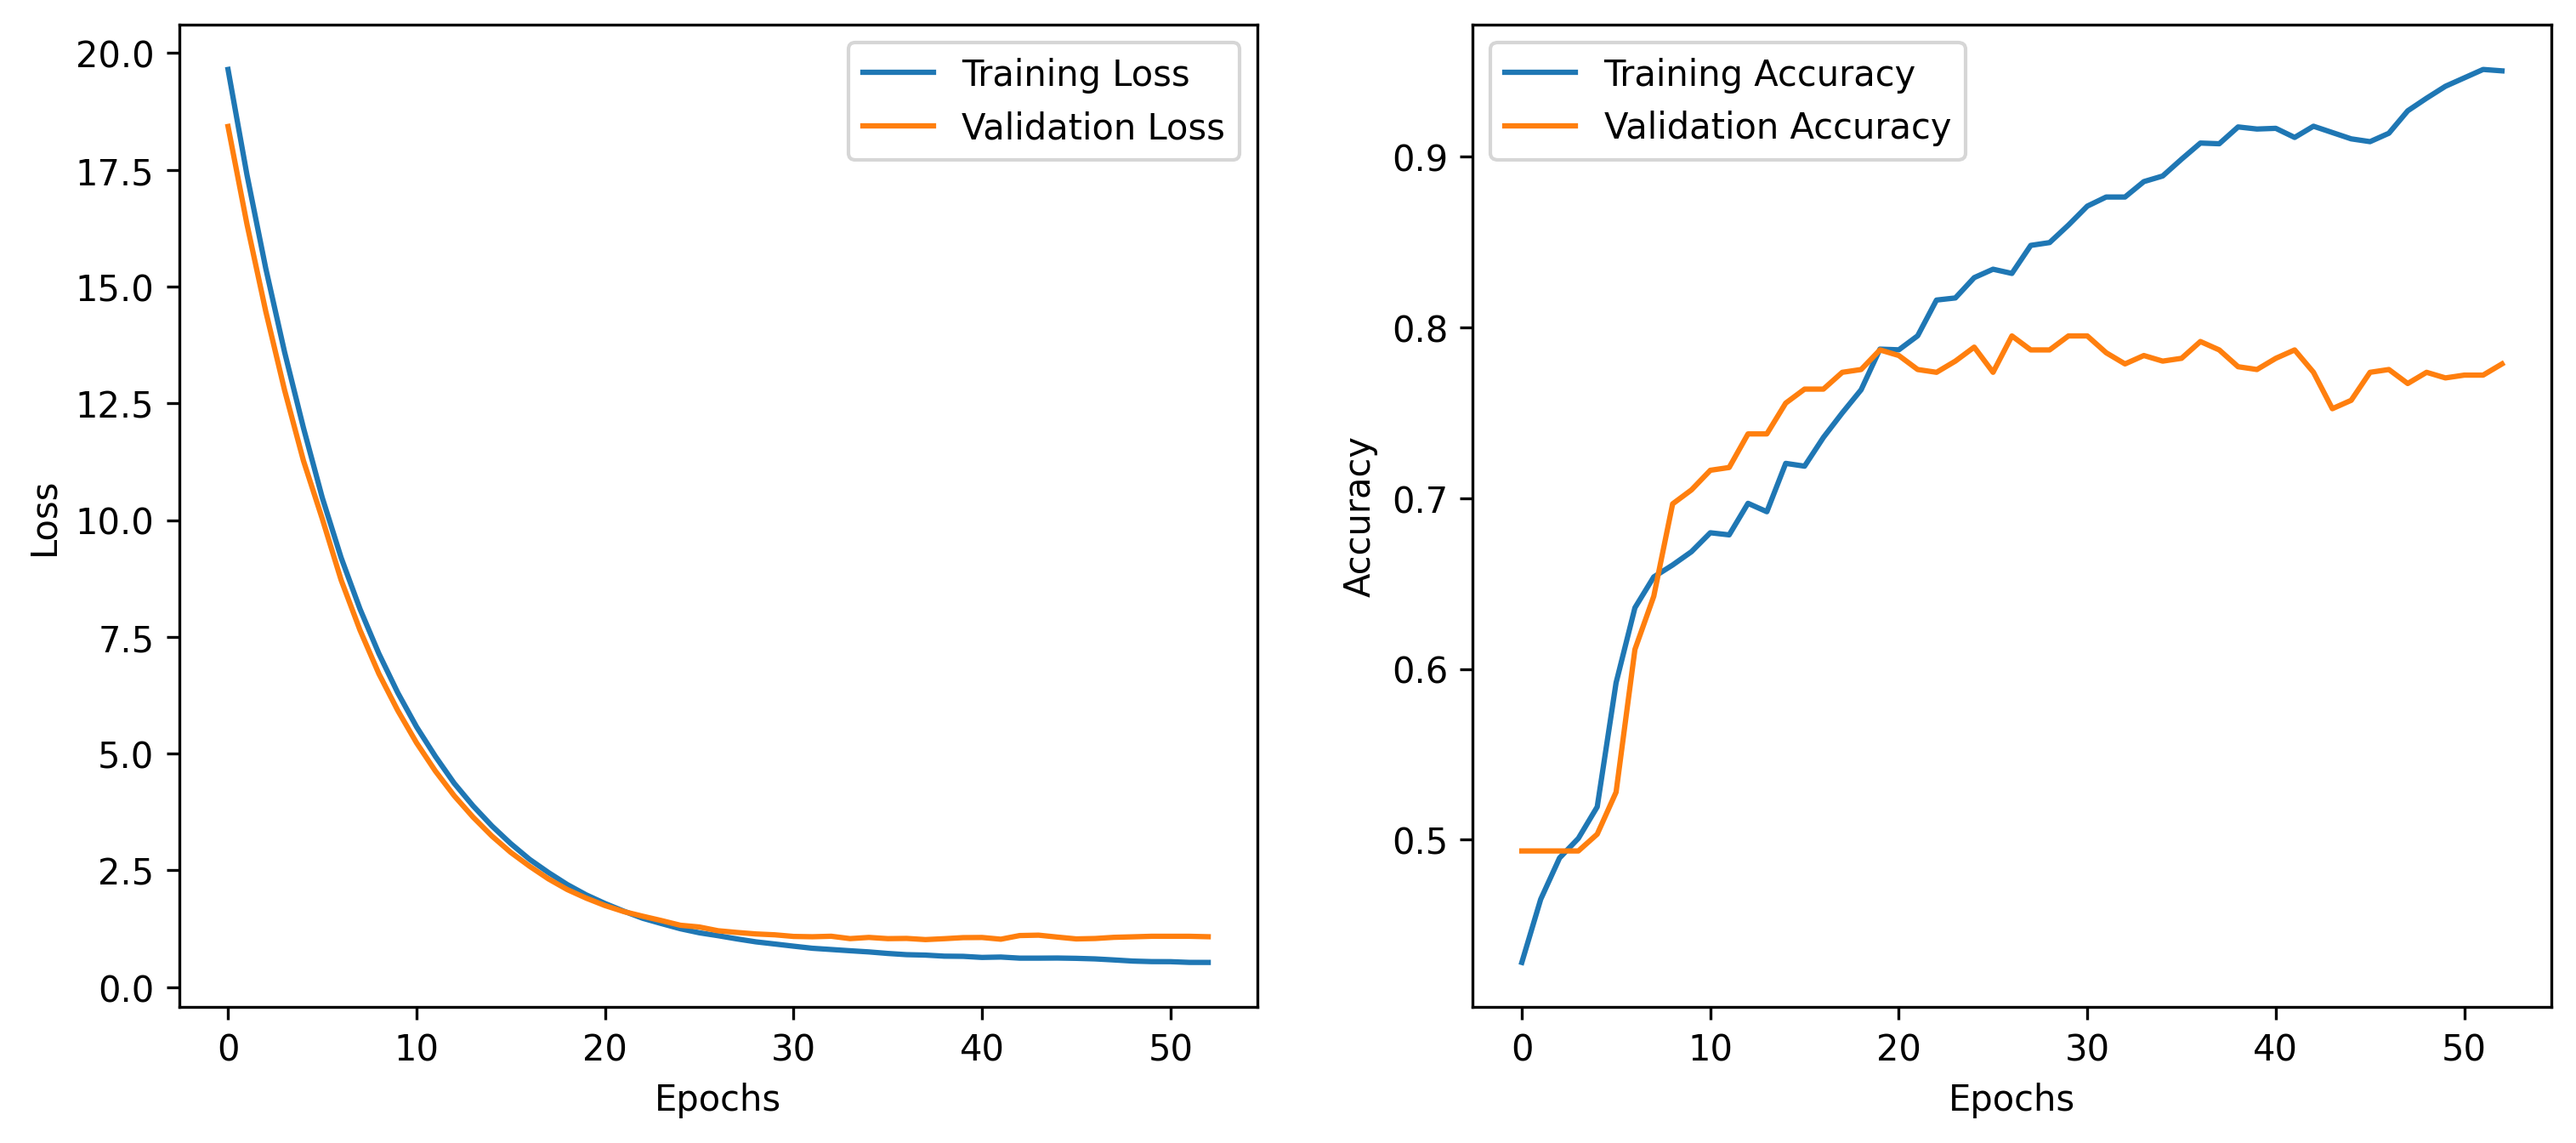

In [26]:
# CNN + Transformer model usage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, GlobalAveragePooling1D,
    Conv1D, BatchNormalization, MaxPooling1D, Add
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# ------------------------
# Reproducibility
# ------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values.astype(np.float32)  # Features
y = df.iloc[:, -1].values.astype(int)          # Labels

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape X for CNN + Transformer
# Better than (samples, 1, features)
X = np.expand_dims(X, axis=-1)  # shape: (num_samples, num_features, 1)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Convert labels to categorical for evaluation
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ------------------------
# Positional Encoding Function
# ------------------------
def positional_encoding(length, depth):
    pos = np.arange(length)[:, np.newaxis]
    i = np.arange(depth)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(depth))
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.convert_to_tensor(angle_rads, dtype=tf.float32)

# ------------------------
# Transformer Block
# ------------------------
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.3):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=rate
        )
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu", kernel_regularizer=l2(0.03)),
            Dropout(rate),
            Dense(embed_dim, kernel_regularizer=l2(0.03))
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# ------------------------
# CNN + Transformer Model
# ------------------------
def build_transformer(input_shape, num_classes, embed_dim=128, num_heads=2, ff_dim=128, num_blocks=2, dropout_rate=0.5):
    inputs = Input(shape=input_shape)

    # CNN frontend
    x = Conv1D(
        filters=32,
        kernel_size=5,
        padding="same",
        activation="relu",
        kernel_regularizer=l2(0.03)
    )(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    x = Conv1D(
        filters=embed_dim,   # must match positional encoding depth
        kernel_size=3,
        padding="same",
        activation="relu",
        kernel_regularizer=l2(0.03)
    )(x)
    x = BatchNormalization()(x)

    # Positional Encoding
    seq_len = x.shape[1]
    positions = positional_encoding(seq_len, embed_dim)
    x = x + positions

    # Transformer Blocks
    for _ in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

    # Classification Head
    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(64, activation="relu", kernel_regularizer=l2(0.03))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=l2(0.03)
    )(x)

    return Model(inputs, outputs)

# ------------------------
# Build and Train the Model
# ------------------------
input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)
model = build_transformer(input_shape, num_classes)
model.summary()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=250,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

from sklearn.metrics import classification_report

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5), dpi=300)
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12,5), dpi=300)

# Plot Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

BiGRU-attention

Epoch 1/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.5548 - loss: 76.1094 - val_accuracy: 0.8164 - val_loss: 69.6438
Epoch 2/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8288 - loss: 67.7999 - val_accuracy: 0.8475 - val_loss: 62.5417
Epoch 3/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8906 - loss: 60.8231 - val_accuracy: 0.8656 - val_loss: 56.2392
Epoch 4/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9108 - loss: 54.6360 - val_accuracy: 0.8623 - val_loss: 50.6279
Epoch 5/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9327 - loss: 49.0966 - val_accuracy: 0.8689 - val_loss: 45.5052
Epoch 6/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9497 - loss: 44.0549 - val_accuracy: 0.8590 - val_loss: 40.8980
Epoch 7/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9659 - loss: 39.5248 - val_accuracy: 0.8623 - val_loss: 36.7473
Epoch 8/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9693 - loss: 35.4693 - v

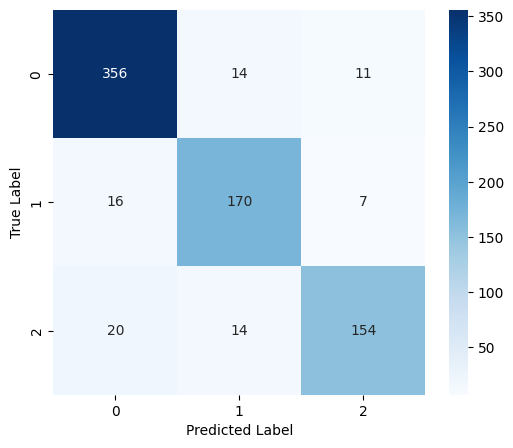

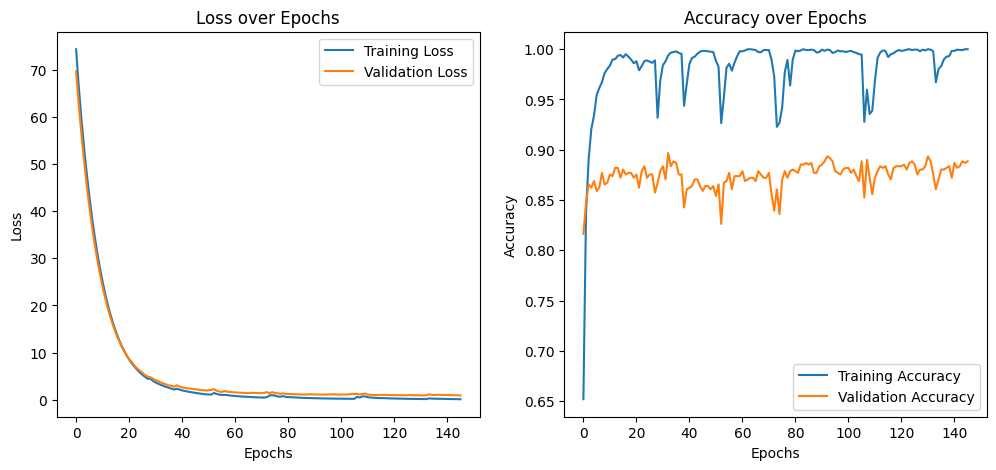

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Bidirectional, GRU, Dropout, Lambda,
    MultiHeadAttention, LayerNormalization, Add, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values   # Labels

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Convert labels to categorical for evaluation
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ------------------------
# Build the BiGRU-Attention Model
# ------------------------
def build_model(input_shape, num_classes):
    inputs = Input(shape=(input_shape,))
    
    x = Lambda(lambda t: tf.expand_dims(t, axis=1))(inputs)
    
    # BiGRU layer
    x = Bidirectional(
        GRU(256, return_sequences=True, kernel_regularizer=l2(0.03))
    )(x)
    
    # Self-Attention layer
    attention_output = MultiHeadAttention(
        num_heads=4,
        key_dim=64
    )(x, x)
    
    # Residual connection + normalization
    x = Add()([x, attention_output])
    x = LayerNormalization()(x)
    
    # Pool sequence output
    x = GlobalAveragePooling1D()(x)
    
    # Dropout
    x = Dropout(0.5)(x)
    
    # Output layer
    outputs = Dense(num_classes, activation="softmax")(x)
    
    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

# Build the model
model = build_model(X_train.shape[1], num_classes)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# ------------------------
# Train the Model
# ------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=250,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

from sklearn.metrics import classification_report

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12,5))

# Plot Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()

Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 414ms/step - accuracy: 0.5083 - loss: 9.0770 - val_accuracy: 0.7098 - val_loss: 7.6472 - learning_rate: 0.0010
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6938 - loss: 7.2953 - val_accuracy: 0.7639 - val_loss: 6.4022 - learning_rate: 0.0010
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7678 - loss: 6.0822 - val_accuracy: 0.7164 - val_loss: 5.9224 - learning_rate: 0.0010
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8044 - loss: 5.2242 - val_accuracy: 0.7787 - val_loss: 4.8549 - learning_rate: 0.0010
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8298 - loss: 4.4460 - val_accuracy: 0.7869 - val_loss: 4.1516 - learning_rate: 0.0010
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8439 - loss: 3.8274 - val_accuracy: 0.8131 - val_loss: 3.6474 - learning_rate: 0.0010
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8779 - loss: 3.2917 

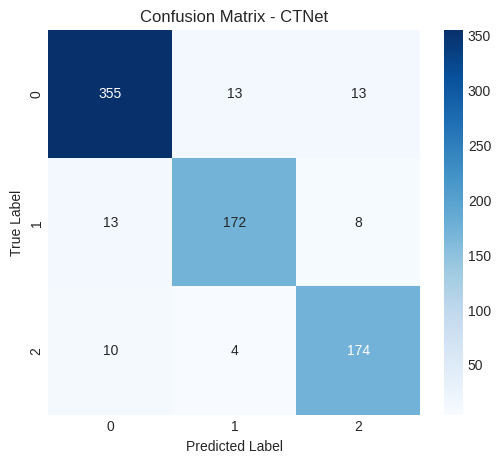

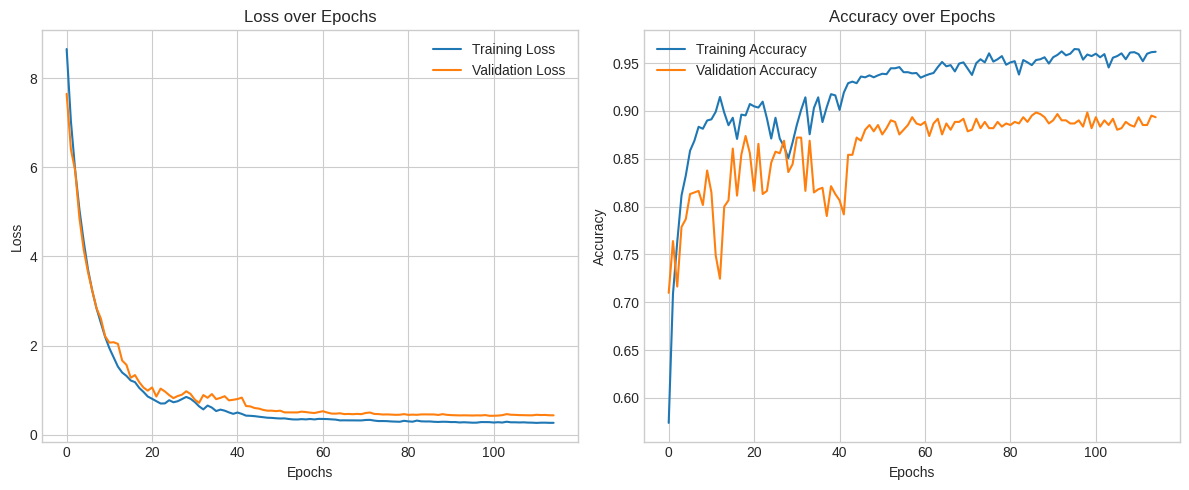

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Reshape, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape X to match Conv1D expected input shape: (samples, timesteps, channels)
X = np.expand_dims(X, axis=-1)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Convert labels to categorical for evaluation if needed later
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ------------------------
# Define the CTNet Model
# ------------------------
def CTNet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.01)(inputs)

    # Temporal Convolution
    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Channel Convolution
    x = Conv1D(
        filters=8,
        kernel_size=1,
        groups=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Spatial Convolution
    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Reshape for Transformer input
    x = Reshape((-1, x.shape[-1]))(x)

    # Transformer Encoder
    mha = MultiHeadAttention(num_heads=4, key_dim=x.shape[-1])(x, x)
    mha = Add()([x, mha])
    mha = LayerNormalization()(mha)

    # Feed-forward network
    ff = Dense(
        x.shape[-1],
        activation='relu',
        kernel_regularizer=l2(0.2)
    )(mha)
    ff = Dropout(0.6)(ff)
    ff = Add()([mha, ff])
    ff = LayerNormalization()(ff)

    # Classifier
    ff_flat = Flatten()(ff)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.2)
    )(ff_flat)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ------------------------
# Build and Train the Model
# ------------------------
model = CTNet(X_train.shape[1:], num_classes)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-4,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=128,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CTNet")
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 409ms/step - accuracy: 0.4887 - loss: 5.1385 - val_accuracy: 0.6639 - val_loss: 4.5804 - learning_rate: 0.0010
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6779 - loss: 4.1814 - val_accuracy: 0.6934 - val_loss: 4.2519 - learning_rate: 0.0010
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7547 - loss: 3.5302 - val_accuracy: 0.7475 - val_loss: 3.4617 - learning_rate: 0.0010
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8021 - loss: 3.0630 - val_accuracy: 0.7197 - val_loss: 3.4418 - learning_rate: 0.0010
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8197 - loss: 2.7315 - val_accuracy: 0.7033 - val_loss: 3.1912 - learning_rate: 0.0010
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8325 - loss: 2.4074 - val_accuracy: 0.7344 - val_loss: 2.6587 - learning_rate: 0.0010
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8754 - loss: 2.0987 

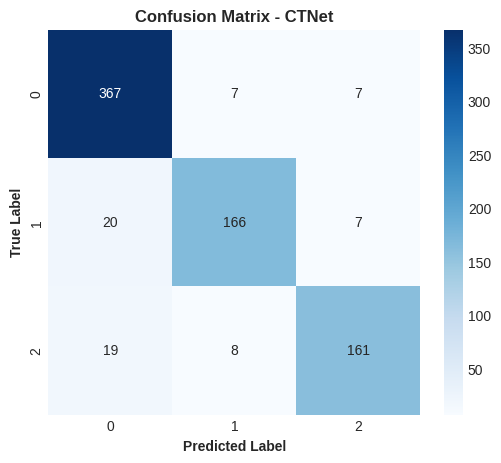

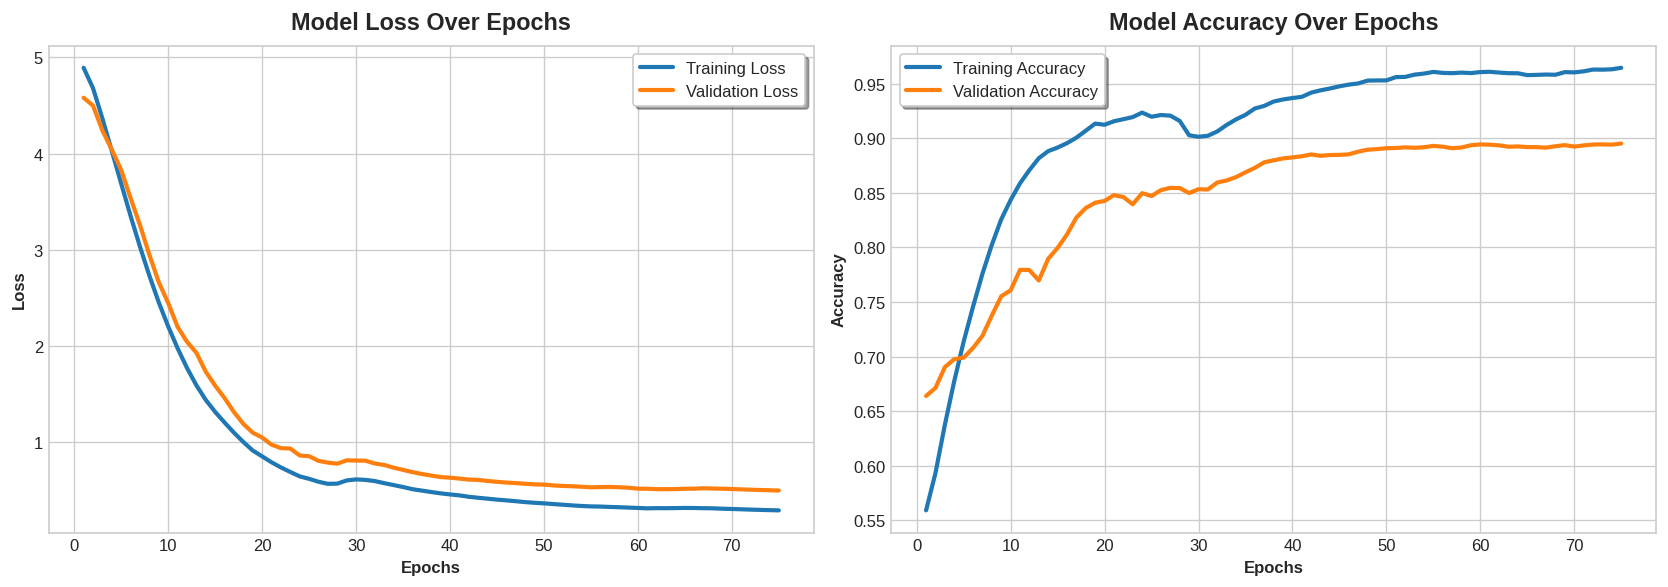

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Reshape, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape X to match Conv1D expected input shape: (samples, timesteps, channels)
X = np.expand_dims(X, axis=-1)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Convert labels to categorical for evaluation if needed later
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ------------------------
# Define the CTNet Model
# ------------------------
def CTNet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.01)(inputs)

    # Temporal Convolution
    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.1)
    )(x)
    x = BatchNormalization()(x)

    # Channel Convolution
    x = Conv1D(
        filters=8,
        kernel_size=1,
        groups=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.1)
    )(x)
    x = BatchNormalization()(x)

    # Spatial Convolution
    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.1)
    )(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Reshape for Transformer input
    x = Reshape((-1, x.shape[-1]))(x)

    # Transformer Encoder
    mha = MultiHeadAttention(num_heads=4, key_dim=x.shape[-1])(x, x)
    mha = Add()([x, mha])
    mha = LayerNormalization()(mha)

    # Feed-forward network
    ff = Dense(
        x.shape[-1],
        activation='relu',
        kernel_regularizer=l2(0.1)
    )(mha)
    ff = Dropout(0.6)(ff)
    ff = Add()([mha, ff])
    ff = LayerNormalization()(ff)

    # Classifier
    ff_flat = Flatten()(ff)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.1)
    )(ff_flat)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ------------------------
# Build and Train the Model
# ------------------------
model = CTNet(X_train.shape[1:], num_classes)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-4,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=128,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)
plt.xlabel("Predicted Label", fontweight='bold')
plt.ylabel("True Label", fontweight='bold')
plt.title("Confusion Matrix - CTNet", fontweight='bold')
plt.show()

# ------------------------
# Plot Training History (Ultra-Clean Smoothed)
# ------------------------

# 1. Define the smoothing function (Exponential Moving Average)
def smooth_curve(points, factor=0.75):
    """
    Smooths a curve using an exponential moving average.
    Higher factor = smoother curve (0.0 to 1.0).
    """
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# 2. Set a modern, clean aesthetic
plt.style.use('seaborn-v0_8-whitegrid') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Extract raw data
epochs = range(1, len(history.history['loss']) + 1)
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# --- Subplot 1: Loss ---
# Plot ONLY the smoothed data with bold, clear lines
ax1.plot(epochs, smooth_curve(loss), color='tab:blue', linewidth=2.5, label='Training Loss')
ax1.plot(epochs, smooth_curve(val_loss), color='tab:orange', linewidth=2.5, label='Validation Loss')

ax1.set_xlabel('Epochs', fontweight='bold')
ax1.set_ylabel('Loss', fontweight='bold')
ax1.set_title('Model Loss Over Epochs', fontsize=14, pad=10, fontweight='bold')
ax1.legend(frameon=True, shadow=True)

# --- Subplot 2: Accuracy ---
# Plot ONLY the smoothed data with bold, clear lines
ax2.plot(epochs, smooth_curve(acc), color='tab:blue', linewidth=2.5, label='Training Accuracy')
ax2.plot(epochs, smooth_curve(val_acc), color='tab:orange', linewidth=2.5, label='Validation Accuracy')

ax2.set_xlabel('Epochs', fontweight='bold')
ax2.set_ylabel('Accuracy', fontweight='bold')
ax2.set_title('Model Accuracy Over Epochs', fontsize=14, pad=10, fontweight='bold')
ax2.legend(frameon=True, shadow=True)

plt.tight_layout()
plt.show()

Epoch 1/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 222ms/step - accuracy: 0.4952 - loss: 9.2380 - val_accuracy: 0.6820 - val_loss: 7.2893 - learning_rate: 0.0010
Epoch 2/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7583 - loss: 6.4016 - val_accuracy: 0.6721 - val_loss: 5.5700 - learning_rate: 0.0010
Epoch 3/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8256 - loss: 4.6423 - val_accuracy: 0.6656 - val_loss: 4.3981 - learning_rate: 0.0010
Epoch 4/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8572 - loss: 3.4951 - val_accuracy: 0.7885 - val_loss: 3.1084 - learning_rate: 0.0010
Epoch 5/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8479 - loss: 2.7465 - val_accuracy: 0.8066 - val_loss: 2.5493 - learning_rate: 0.0010
Epoch 6/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8996 - loss: 2.1202 - val_accuracy: 0.7869 - val_loss: 2.1393 - learning_rate: 0.0010
Epoch 7/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8670 - loss: 1.7788 

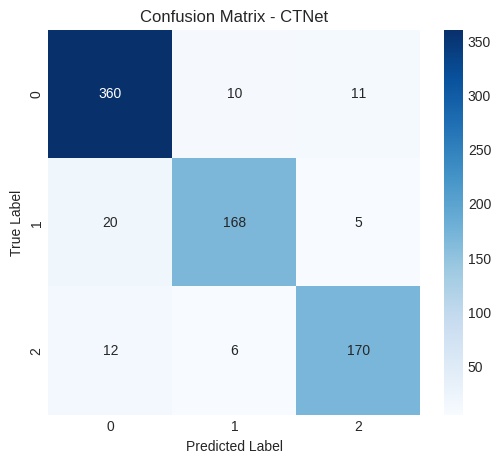

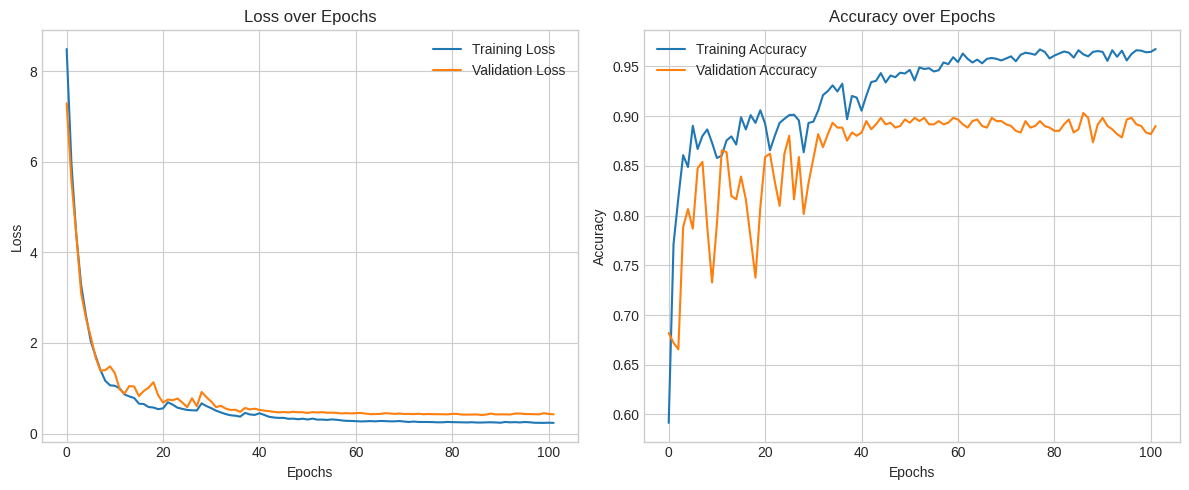

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Reshape, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape X to match Conv1D expected input shape: (samples, timesteps, channels)
X = np.expand_dims(X, axis=-1)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Convert labels to categorical for evaluation if needed later
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ------------------------
# Define the CTNet Model
# ------------------------
def CTNet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.01)(inputs)

    # Temporal Convolution
    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Channel Convolution
    x = Conv1D(
        filters=8,
        kernel_size=1,
        groups=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Spatial Convolution
    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Reshape for Transformer input
    x = Reshape((-1, x.shape[-1]))(x)

    # Transformer Encoder
    mha = MultiHeadAttention(num_heads=4, key_dim=x.shape[-1])(x, x)
    mha = Add()([x, mha])
    mha = LayerNormalization()(mha)

    # Feed-forward network
    ff = Dense(
        x.shape[-1],
        activation='relu',
        kernel_regularizer=l2(0.2)
    )(mha)
    ff = Dropout(0.6)(ff)
    ff = Add()([mha, ff])
    ff = LayerNormalization()(ff)

    # Classifier
    ff_flat = Flatten()(ff)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.2)
    )(ff_flat)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ------------------------
# Build and Train the Model
# ------------------------
model = CTNet(X_train.shape[1:], num_classes)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-4,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=64,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CTNet")
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.5372 - loss: 9.0960 - val_accuracy: 0.6443 - val_loss: 5.9730 - learning_rate: 0.0010
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7793 - loss: 4.8650 - val_accuracy: 0.7967 - val_loss: 3.3805 - learning_rate: 0.0010
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8422 - loss: 2.8925 - val_accuracy: 0.8656 - val_loss: 2.0396 - learning_rate: 0.0010
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8759 - loss: 1.8509 - val_accuracy: 0.8279 - val_loss: 1.5739 - learning_rate: 0.0010
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8664 - loss: 1.3502 - val_accuracy: 0.6951 - val_loss: 1.8342 - learning_rate: 0.0010
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8747 - loss: 1.0442 - val_accuracy: 0.8525 - val_loss: 0.9665 - learning_rate: 0.0010
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8764 - loss: 0.8740 

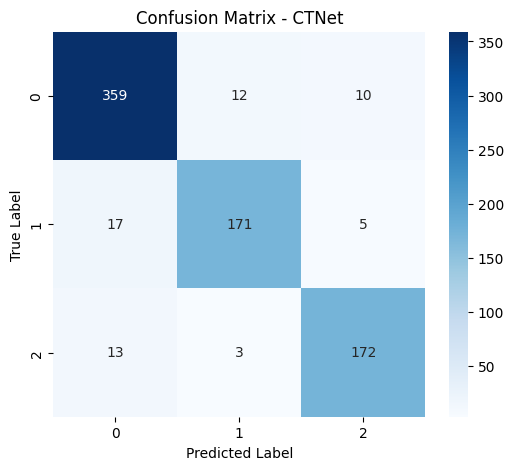

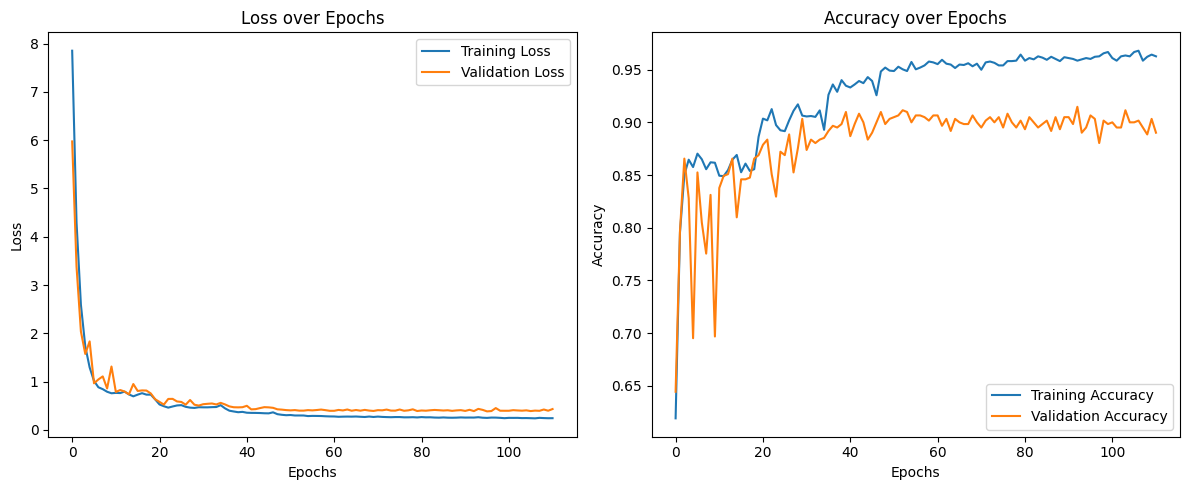

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Reshape, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape X to match Conv1D expected input shape: (samples, timesteps, channels)
X = np.expand_dims(X, axis=-1)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Convert labels to categorical for evaluation if needed later
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ------------------------
# Define the CTNet Model
# ------------------------
def CTNet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    # Temporal Convolution
    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Channel Convolution
    x = Conv1D(
        filters=8,
        kernel_size=1,
        groups=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Spatial Convolution
    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Reshape for Transformer input
    x = Reshape((-1, x.shape[-1]))(x)

    # Transformer Encoder
    mha = MultiHeadAttention(num_heads=4, key_dim=x.shape[-1])(x, x)
    mha = Add()([x, mha])
    mha = LayerNormalization()(mha)

    # Feed-forward network
    ff = Dense(
        x.shape[-1],
        activation='relu',
        kernel_regularizer=l2(0.2)
    )(mha)
    ff = Dropout(0.6)(ff)
    ff = Add()([mha, ff])
    ff = LayerNormalization()(ff)

    # Classifier
    ff_flat = Flatten()(ff)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.3)
    )(ff_flat)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ------------------------
# Build and Train the Model
# ------------------------
model = CTNet(X_train.shape[1:], num_classes)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-4,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CTNet")
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.5603 - loss: 9.4399 - val_accuracy: 0.7869 - val_loss: 5.7135 - learning_rate: 0.0010
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7925 - loss: 4.8825 - val_accuracy: 0.8082 - val_loss: 3.2788 - learning_rate: 0.0010
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8408 - loss: 2.7281 - val_accuracy: 0.7967 - val_loss: 2.0330 - learning_rate: 0.0010
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8544 - loss: 1.7303 - val_accuracy: 0.8295 - val_loss: 1.3812 - learning_rate: 0.0010
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8606 - loss: 1.2147 - val_accuracy: 0.7443 - val_loss: 1.4536 - learning_rate: 0.0010
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8777 - loss: 0.9496 - val_accuracy: 0.7984 - val_loss: 1.0820 - learning_rate: 0.0010
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8737 - loss: 0.8536 

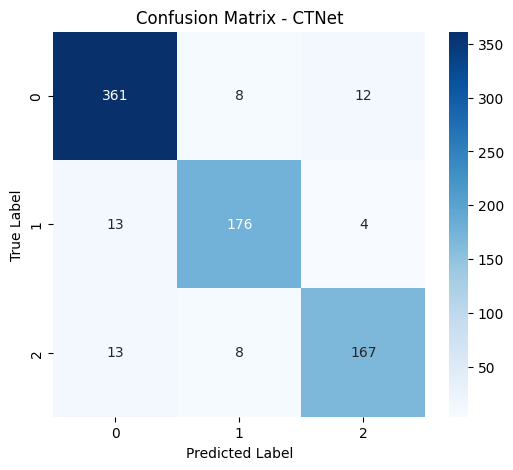

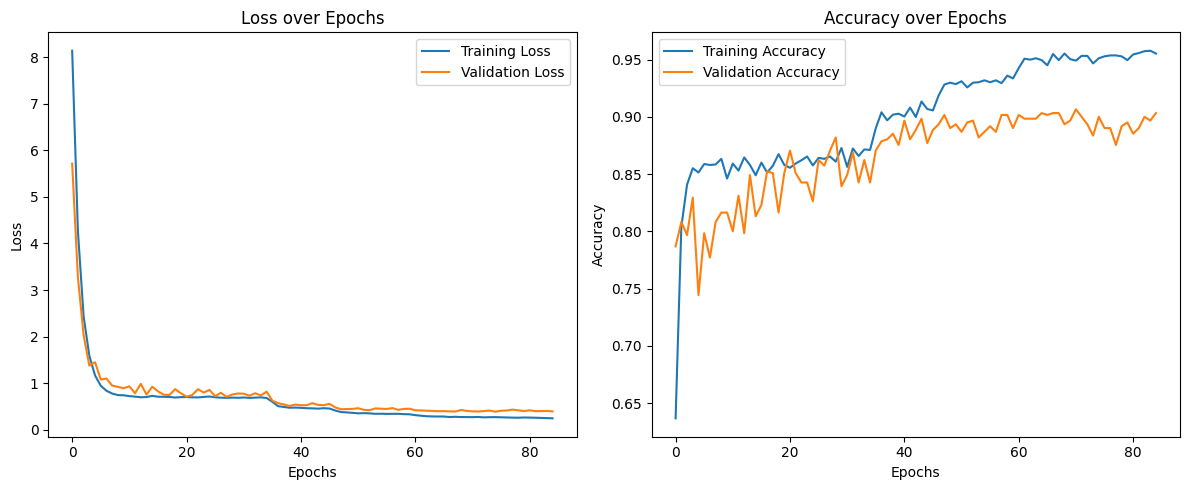

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Reshape, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# ------------------------
# Load and Preprocess Data
# ------------------------
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape X to match Conv1D expected input shape: (samples, timesteps, channels)
X = np.expand_dims(X, axis=-1)

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Convert labels to categorical for evaluation if needed later
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ------------------------
# Define the CTNet Model
# ------------------------
def CTNet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    # Temporal Convolution
    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Channel Convolution
    x = Conv1D(
        filters=8,
        kernel_size=1,
        groups=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Spatial Convolution
    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Reshape for Transformer input
    x = Reshape((-1, x.shape[-1]))(x)

    # Transformer Encoder
    mha = MultiHeadAttention(num_heads=4, key_dim=x.shape[-1])(x, x)
    mha = Add()([x, mha])
    mha = LayerNormalization()(mha)

    # Feed-forward network
    ff = Dense(
        x.shape[-1],
        activation='relu',
        kernel_regularizer=l2(0.2)
    )(mha)
    ff = Dropout(0.6)(ff)
    ff = Add()([mha, ff])
    ff = LayerNormalization()(ff)

    # Classifier
    ff_flat = Flatten()(ff)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.3)
    )(ff_flat)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# ------------------------
# Build and Train the Model
# ------------------------
model = CTNet(X_train.shape[1:], num_classes)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-4,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# ------------------------
# Evaluate the Model
# ------------------------
y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_test_pred = np.argmax(model.predict(X_test), axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# ------------------------
# Plot Confusion Matrix
# ------------------------
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=range(num_classes),
    yticklabels=range(num_classes)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CTNet")
plt.show()

# ------------------------
# Plot Training History
# ------------------------
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

#### Ablation Study

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Bidirectional, LSTM, GRU, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter # Moved to the top for clean execution

# 1. Load the Dataset
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# 2. Separate Features and Labels
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values   # Labels

# Check overall class balance (Fixed to check 'y' instead of 'X')
print("Total Class Distribution:", Counter(y))

# 3. Standardize Features
# Crucial for neural networks to ensure gradients converge smoothly
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 4. Create the Train/Validation/Test Splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# 5. Verify Split Distributions
print("\n--- Class Distributions After Splits ---")
print("Train:", Counter(y_train))
print("Val  :", Counter(y_val))
print("Test :", Counter(y_test))

# 6. Verify Original 2D Shapes (samples, features)
print("\n--- Original 2D Shapes ---")
print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")

# 7. Reshape for Recurrent Layers (from 2D to 3D)
# LSTMs and GRUs require a 3D input tensor: (samples, time_steps, features)
time_steps = 1
num_features = X_train.shape[1]

X_train_3d = X_train.reshape(X_train.shape[0], time_steps, num_features)
X_val_3d = X_val.reshape(X_val.shape[0], time_steps, num_features)
X_test_3d = X_test.reshape(X_test.shape[0], time_steps, num_features)

print("\n--- Reshaped 3D Shapes (Ready for Model) ---")
print(f"X_train_3d shape : {X_train_3d.shape}")
print(f"X_val_3d shape   : {X_val_3d.shape}")
print(f"X_test_3d shape  : {X_test_3d.shape}")

Total Class Distribution: Counter({np.float64(0.0): 1904, np.float64(1.0): 963, np.float64(2.0): 941})

--- Class Distributions After Splits ---
Train: Counter({np.float64(0.0): 1218, np.float64(1.0): 616, np.float64(2.0): 602})
Val  : Counter({np.float64(0.0): 305, np.float64(1.0): 154, np.float64(2.0): 151})
Test : Counter({np.float64(0.0): 381, np.float64(1.0): 193, np.float64(2.0): 188})

--- Original 2D Shapes ---
X_train shape : (2436, 3800)
X_val shape   : (610, 3800)
X_test shape  : (762, 3800)

--- Reshaped 3D Shapes (Ready for Model) ---
X_train_3d shape : (2436, 1, 3800)
X_val_3d shape   : (610, 1, 3800)
X_test_3d shape  : (762, 1, 3800)



Training Hybrid_CTNet


I0000 00:00:1773096785.107388      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/500


I0000 00:00:1773096791.381673     150 service.cc:152] XLA service 0x7954bc019de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773096791.381710     150 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773096792.621658     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


16/77 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3592 - loss: 10.0594

I0000 00:00:1773096798.909072     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.5217 - loss: 8.7880 - val_accuracy: 0.7115 - val_loss: 5.4829 - learning_rate: 0.0010
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7909 - loss: 4.4247 - val_accuracy: 0.6754 - val_loss: 3.3650 - learning_rate: 0.0010
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8427 - loss: 2.4631 - val_accuracy: 0.6770 - val_loss: 2.3135 - learning_rate: 0.0010
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8374 - loss: 1.6317 - val_accuracy: 0.7246 - val_loss: 1.7765 - learning_rate: 0.0010
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8435 - loss: 1.2327 - val_accuracy: 0.7820 - val_loss: 1.2973 - learning_rate: 0.0010
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8451 - loss: 1.0167 - val_accuracy: 0.8098 - val_loss: 1.0607 - learning_rate: 0.0010
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8516 - loss: 0.8841 - val_accura

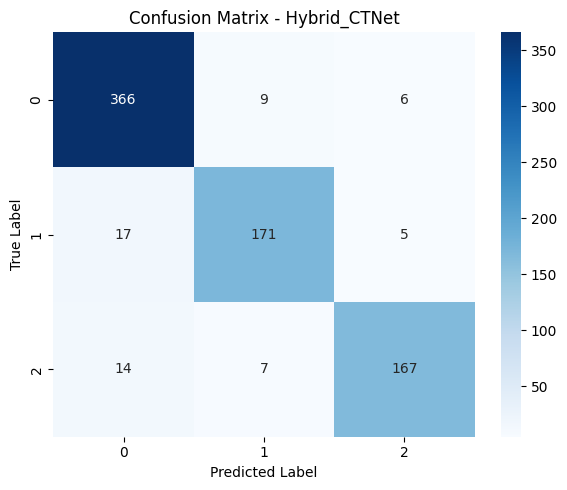

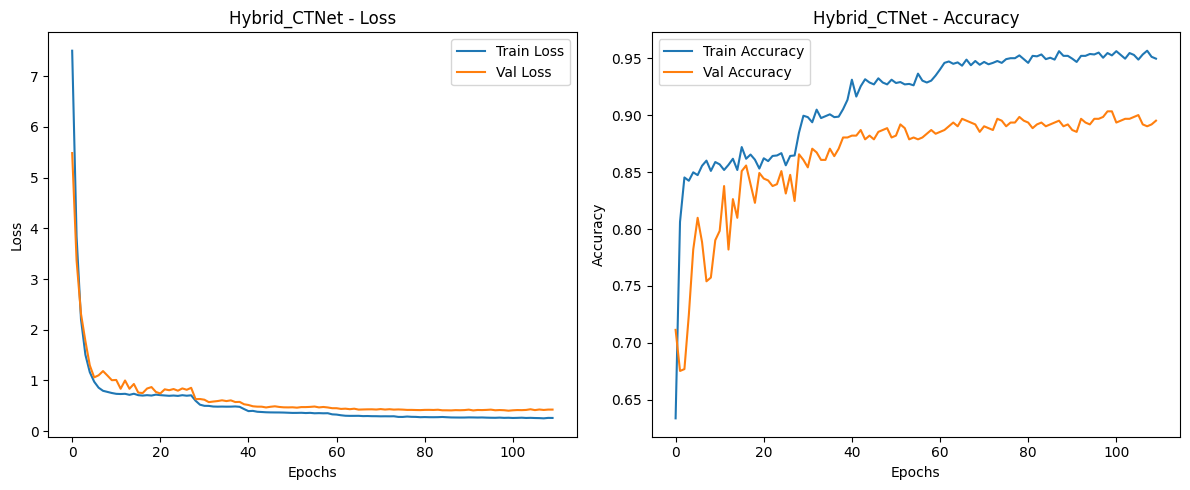

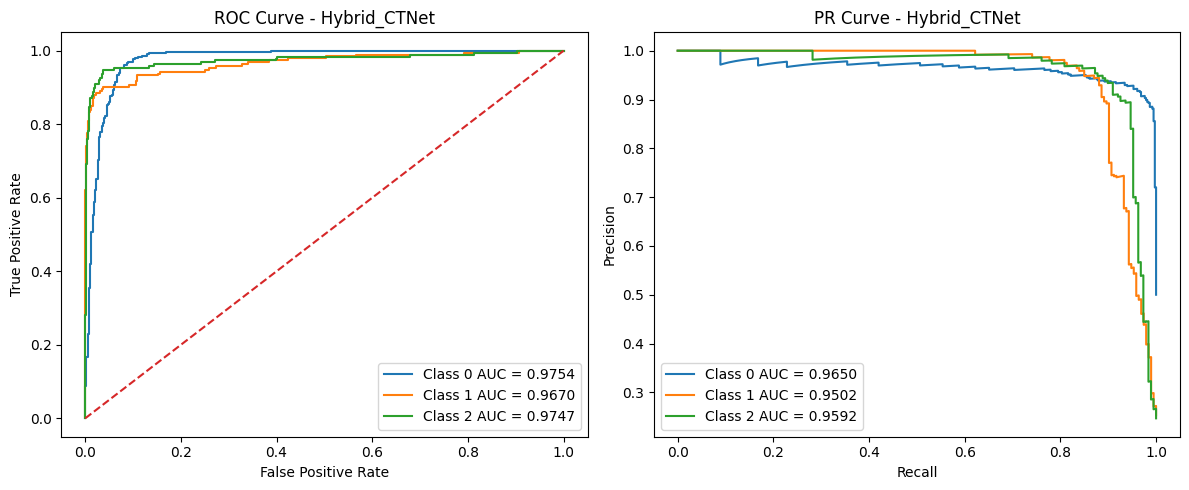


Training CNN_Only
Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.5797 - loss: 18.6664 - val_accuracy: 0.5902 - val_loss: 4.3220 - learning_rate: 0.0010
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7209 - loss: 3.5942 - val_accuracy: 0.4934 - val_loss: 2.7397 - learning_rate: 0.0010
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6884 - loss: 2.3669 - val_accuracy: 0.5016 - val_loss: 2.1703 - learning_rate: 0.0010
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6732 - loss: 1.9055 - val_accuracy: 0.5557 - val_loss: 1.8377 - learning_rate: 0.0010
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6638 - loss: 1.6657 - val_accuracy: 0.4984 - val_loss: 1.6999 - learning_rate: 0.0010
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6464 - loss: 1.5054 - val_accuracy: 0.5131 - val_loss: 1.5379 - learning_rate: 0.0010
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6457 - 

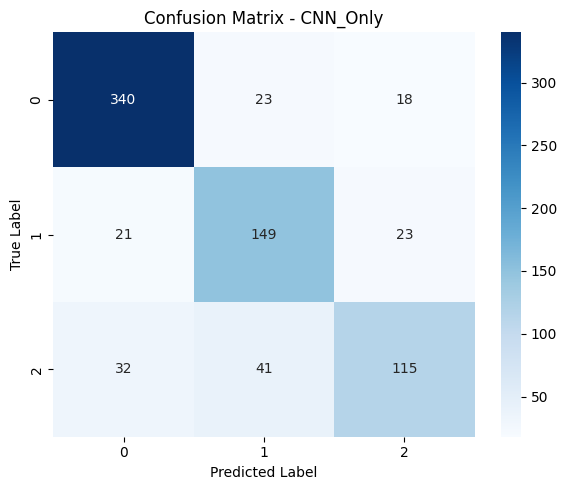

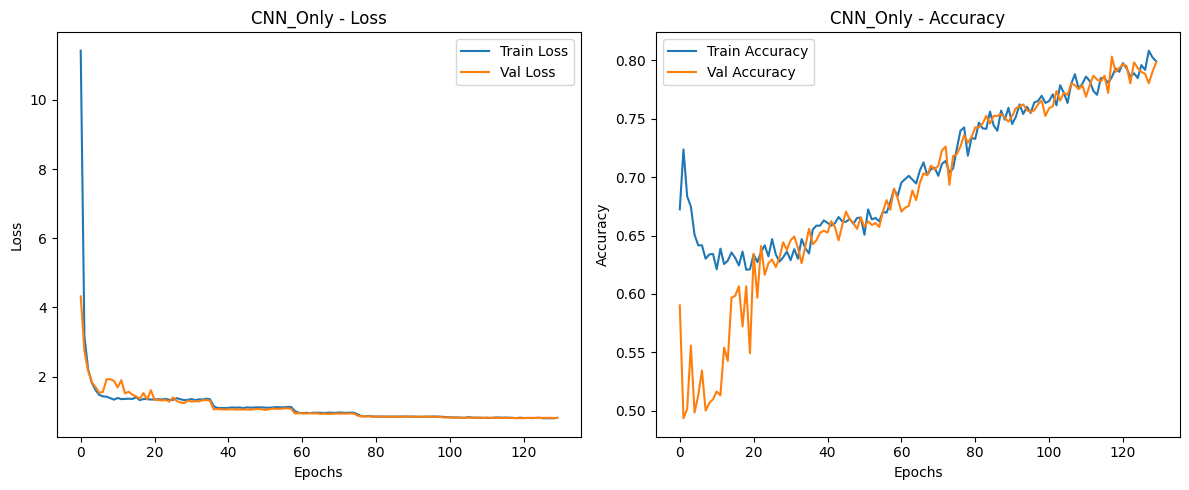

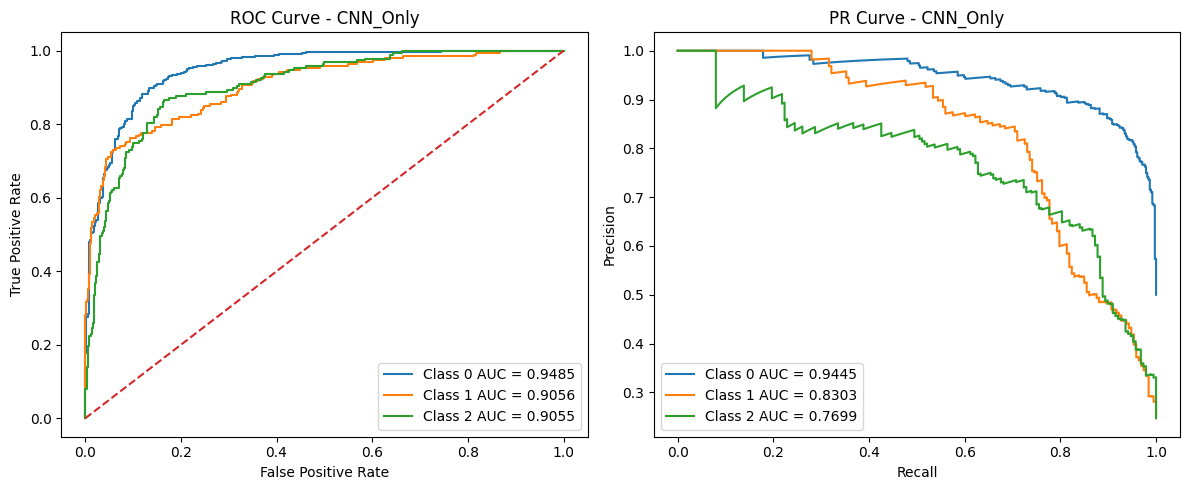


Training Transformer_Only
Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - accuracy: 0.6404 - loss: 5.7813 - val_accuracy: 0.7459 - val_loss: 3.7869 - learning_rate: 0.0010
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8145 - loss: 3.0671 - val_accuracy: 0.7623 - val_loss: 2.2867 - learning_rate: 0.0010
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7986 - loss: 1.8854 - val_accuracy: 0.7508 - val_loss: 1.7031 - learning_rate: 0.0010
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8234 - loss: 1.3202 - val_accuracy: 0.7393 - val_loss: 1.5370 - learning_rate: 0.0010
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8192 - loss: 1.0914 - val_accuracy: 0.7230 - val_loss: 1.4794 - learning_rate: 0.0010
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8261 - loss: 0.9819 - val_accuracy: 0.7328 - val_loss: 1.3393 - learning_rate: 0.0010
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accur

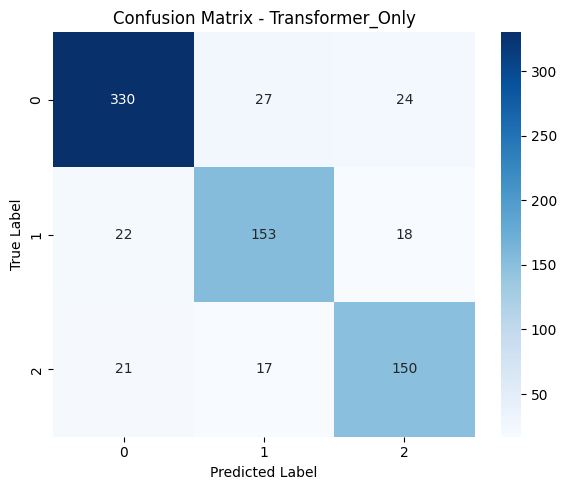

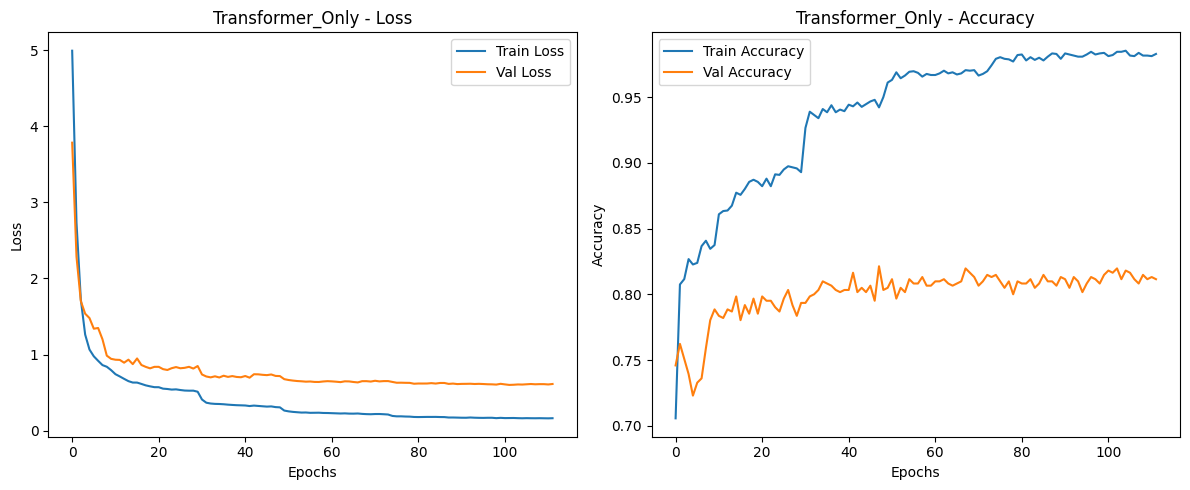

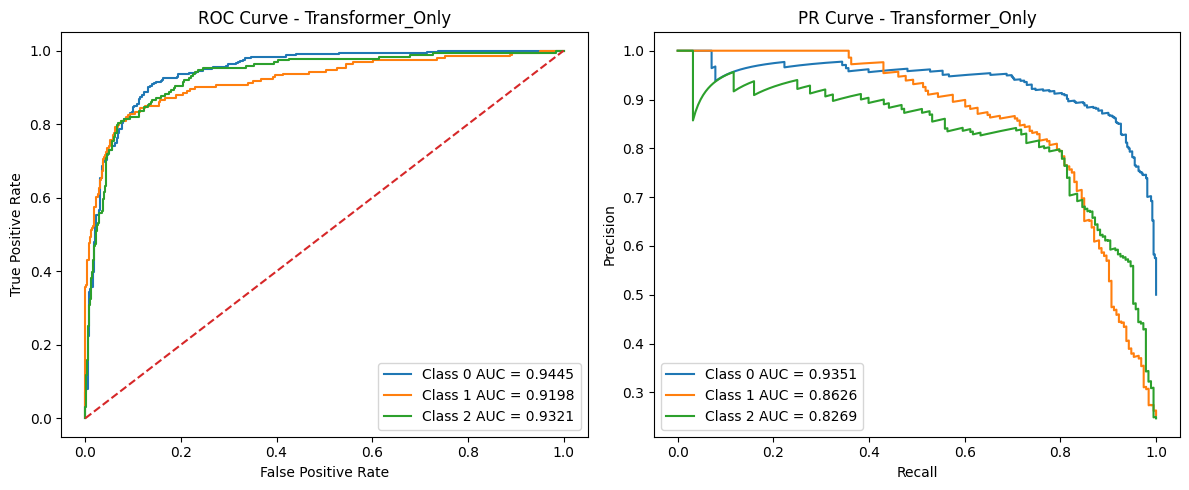


Ablation Study Summary
              Model  Train Accuracy  Test Accuracy  Train ROC-AUC  \
0      Hybrid_CTNet        0.951740       0.923885       0.991491   
1          CNN_Only        0.830926       0.792651       0.939999   
2  Transformer_Only        0.952397       0.830709       0.988691   

   Test ROC-AUC  Train PR-AUC  Test PR-AUC  
0      0.972395      0.984309     0.958182  
1      0.919858      0.882190     0.848688  
2      0.932117      0.979776     0.875281  


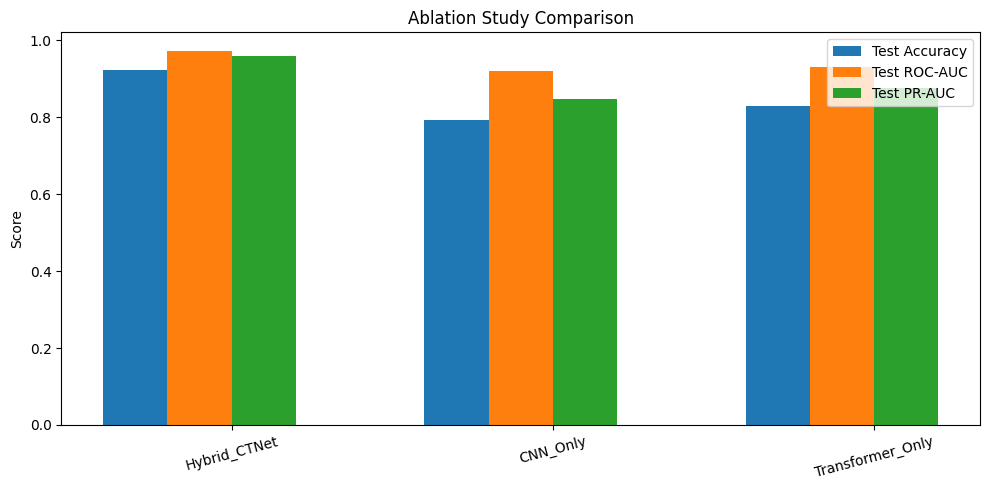

In [5]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Reshape, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)

# =========================
# Reproducibility
# =========================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# =========================
# Load and Preprocess Data
# =========================
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Separate features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape for Conv1D / Transformer input: (samples, timesteps, channels)
X = np.expand_dims(X, axis=-1)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=SEED
)

num_classes = len(np.unique(y))
input_shape = X_train.shape[1:]

# One-hot labels for AUC calculation
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


# =========================
# Model Definitions
# =========================
def build_ctnet(input_shape, num_classes):
    """Hybrid CNN + Transformer"""
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    # CNN feature extractor
    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=8,
        kernel_size=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Transformer encoder
    x = Reshape((-1, x.shape[-1]))(x)

    attn = MultiHeadAttention(num_heads=4, key_dim=int(x.shape[-1]))(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(
        int(x.shape[-1]),
        activation='relu',
        kernel_regularizer=l2(0.2)
    )(x)
    ff = Dropout(0.6)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    x = Flatten()(x)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.3)
    )(x)

    model = Model(inputs, outputs, name="CTNet_Hybrid")
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_cnn_only(input_shape, num_classes):
    """CNN-only ablation: same CNN backbone, no Transformer"""
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=8,
        kernel_size=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    x = Flatten()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.2))(x)
    x = Dropout(0.6)(x)

    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.3)
    )(x)

    model = Model(inputs, outputs, name="CNN_Only")
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_transformer_only(input_shape, num_classes):
    """
    Transformer-only ablation:
    No CNN layers.
    Directly project raw sequence input, then apply Transformer encoder.
    """
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    # Project raw input channel to a richer embedding dimension
    x = Conv1D(
        filters=16,
        kernel_size=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Optional downsampling to reduce sequence length slightly
    x = AveragePooling1D(pool_size=4)(x)
    x = Dropout(0.5)(x)

    # Transformer block
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(16, activation='relu', kernel_regularizer=l2(0.2))(x)
    ff = Dropout(0.5)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    x = Flatten()(x)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.3)
    )(x)

    model = Model(inputs, outputs, name="Transformer_Only")
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# =========================
# Metrics Helpers
# =========================
def compute_auc_metrics(y_true, y_prob, num_classes):
    """
    Returns macro AUC-ROC and macro AUC-PRC.
    Works for binary and multiclass.
    """
    y_true_bin = to_categorical(y_true, num_classes=num_classes)

    if num_classes == 2:
        # Use positive-class probability
        roc_auc = roc_auc_score(y_true, y_prob[:, 1])
        pr_auc = average_precision_score(y_true, y_prob[:, 1])
    else:
        roc_auc = roc_auc_score(
            y_true_bin, y_prob,
            multi_class='ovr',
            average='macro'
        )
        pr_auc = average_precision_score(
            y_true_bin, y_prob,
            average='macro'
        )

    return roc_auc, pr_auc


def plot_conf_matrix(y_true, y_pred, model_name, num_classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=range(num_classes),
        yticklabels=range(num_classes)
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()


def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(y_true, y_prob, num_classes, model_name):
    y_true_bin = to_categorical(y_true, num_classes=num_classes)

    plt.figure(figsize=(12, 5))

    # ---------------------
    # ROC Curve
    # ---------------------
    plt.subplot(1, 2, 1)

    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    else:
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            roc_auc_i = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"Class {i} AUC = {roc_auc_i:.4f}")

    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()

    # ---------------------
    # PR Curve
    # ---------------------
    plt.subplot(1, 2, 2)

    if num_classes == 2:
        precision, recall, _ = precision_recall_curve(y_true, y_prob[:, 1])
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    else:
        for i in range(num_classes):
            precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
            pr_auc_i = auc(recall, precision)
            plt.plot(recall, precision, label=f"Class {i} AUC = {pr_auc_i:.4f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {model_name}")
    plt.legend()

    plt.tight_layout()
    plt.show()


# =========================
# Training / Evaluation
# =========================
def train_and_evaluate(model_fn, model_name, X_train, y_train, X_test, y_test, num_classes):
    print(f"\n{'='*70}")
    print(f"Training {model_name}")
    print(f"{'='*70}")

    model = model_fn(input_shape, num_classes)

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-4,
        verbose=1
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=500,
        batch_size=32,
        callbacks=[early_stopping, lr_scheduler],
        verbose=1
    )

    # Predictions
    y_train_prob = model.predict(X_train, verbose=0)
    y_test_prob = model.predict(X_test, verbose=0)

    y_train_pred = np.argmax(y_train_prob, axis=1)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # AUC metrics
    train_roc_auc, train_pr_auc = compute_auc_metrics(y_train, y_train_prob, num_classes)
    test_roc_auc, test_pr_auc = compute_auc_metrics(y_test, y_test_prob, num_classes)

    print(f"\n{model_name} Results")
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")
    print(f"Train ROC-AUC  : {train_roc_auc:.4f}")
    print(f"Test ROC-AUC   : {test_roc_auc:.4f}")
    print(f"Train PR-AUC   : {train_pr_auc:.4f}")
    print(f"Test PR-AUC    : {test_pr_auc:.4f}")

    # Plots
    plot_conf_matrix(y_test, y_test_pred, model_name, num_classes)
    plot_training_history(history, model_name)
    plot_roc_pr_curves(y_test, y_test_prob, num_classes, model_name)

    results = {
        "Model": model_name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Train ROC-AUC": train_roc_auc,
        "Test ROC-AUC": test_roc_auc,
        "Train PR-AUC": train_pr_auc,
        "Test PR-AUC": test_pr_auc
    }

    return model, history, results


# =========================
# Run Ablation Study
# =========================
all_results = []

# 1. Hybrid CNN-Transformer
hybrid_model, hybrid_history, hybrid_results = train_and_evaluate(
    build_ctnet, "Hybrid_CTNet", X_train, y_train, X_test, y_test, num_classes
)
all_results.append(hybrid_results)

# 2. CNN-only
cnn_model, cnn_history, cnn_results = train_and_evaluate(
    build_cnn_only, "CNN_Only", X_train, y_train, X_test, y_test, num_classes
)
all_results.append(cnn_results)

# 3. Transformer-only
transformer_model, transformer_history, transformer_results = train_and_evaluate(
    build_transformer_only, "Transformer_Only", X_train, y_train, X_test, y_test, num_classes
)
all_results.append(transformer_results)


# =========================
# Summary Table
# =========================
results_df = pd.DataFrame(all_results)
print("\nAblation Study Summary")
print(results_df)

plt.figure(figsize=(10, 5))
x = np.arange(len(results_df["Model"]))
width = 0.2

plt.bar(x - 1.5*width, results_df["Test Accuracy"], width=width, label="Test Accuracy")
plt.bar(x - 0.5*width, results_df["Test ROC-AUC"], width=width, label="Test ROC-AUC")
plt.bar(x + 0.5*width, results_df["Test PR-AUC"], width=width, label="Test PR-AUC")

plt.xticks(x, results_df["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Ablation Study Comparison")
plt.legend()
plt.tight_layout()
plt.show()

X_train shape: (3046, 3800, 1)
X_test shape : (762, 3800, 1)
num_classes  : 3

Training: Hybrid_CT_Exact


Model: "Hybrid_CT_Exact"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 3800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_9    │ (None, 3800, 1)   │          0 │ input_layer_9[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 3800, 8)   │        520 │ gaussian_noise_9… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 8)   │         32 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 3800, 8)   │         72 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 8)   │         32 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 3800, 16)  │      2,064 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 16)  │         64 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_8 │ (None, 475, 16)   │          0 │ batch_normalizat… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 475, 16)   │          0 │ average_pooling1… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 475, 16)   │      4,304 │ dropout_25[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 475, 16)   │          0 │ dropout_25[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 475, 16)   │        272 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 475, 16)   │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 475, 16)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 7600)      │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 30,227 (118.07 KB)

 Trainable params: 30,163 (117.82 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - accuracy: 0.5274 - loss: 8.7901 - val_accuracy: 0.7131 - val_loss: 5.4740 - learning_rate: 0.0010
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7863 - loss: 4.4237 - val_accuracy: 0.6623 - val_loss: 3.4340 - learning_rate: 0.0010
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8423 - loss: 2.4686 - val_accuracy: 0.6803 - val_loss: 2.3867 - learning_rate: 0.0010
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8436 - loss: 1.6325 - val_accuracy: 0.7689 - val_loss: 1.6008 - learning_rate: 0.0010
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8328 - loss: 1.2215 - val_accuracy: 0.7852 - val_loss: 1.2777 - learning_rate: 0.0010
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8508 - loss: 1.0044 - val_accuracy: 0.7082 - val_loss: 1.4115 - learning_rate: 0.0010
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8497 - loss: 0.8838 

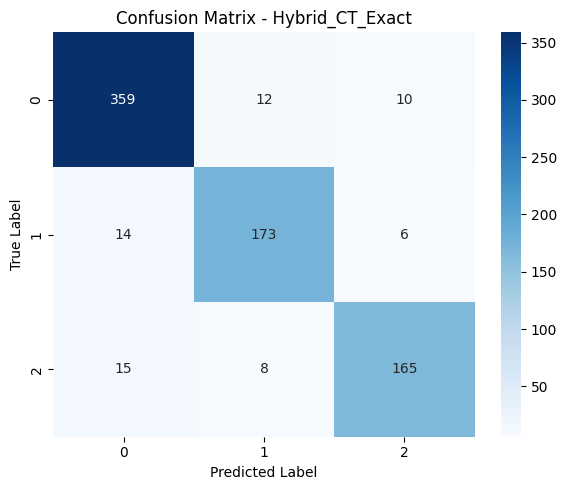

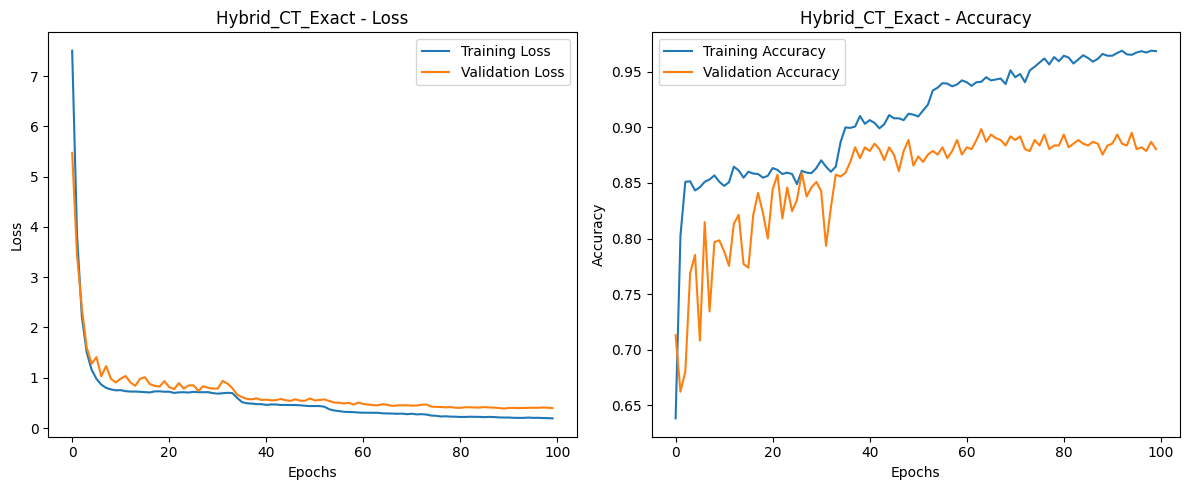

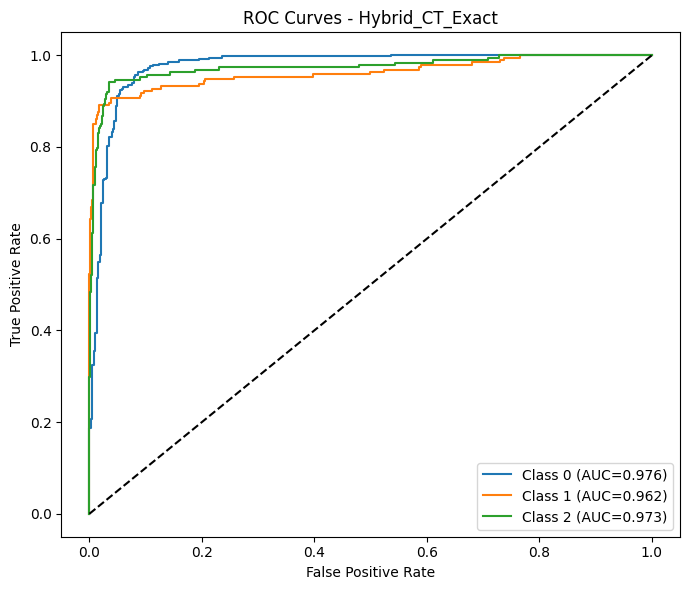

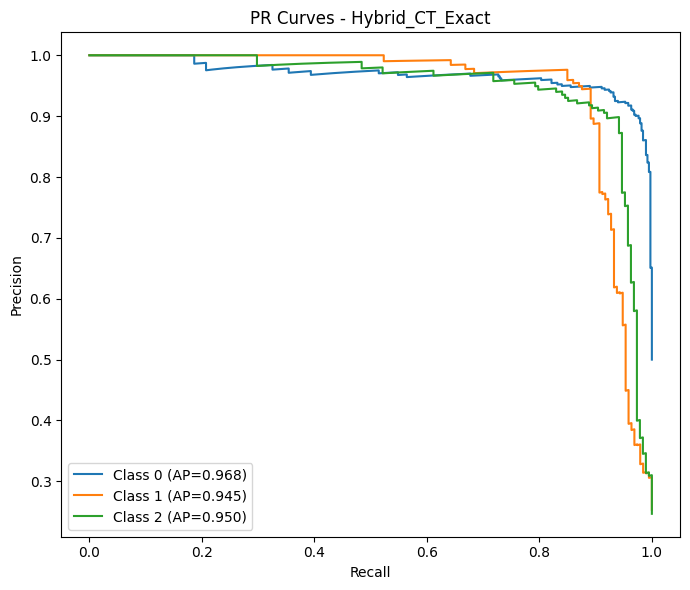


Training: CNN_Only_Exact


Model: "CNN_Only_Exact"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 3800, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_10               │ (None, 3800, 1)        │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 3800, 8)        │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 3800, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 3800, 8)        │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 3800, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 3800, 16)       │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 3800, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_9             │ (None, 475, 16)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 475, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 7600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │        22,803 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,587 (99.95 KB)

 Trainable params: 25,523 (99.70 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.6043 - loss: 5.5152 - val_accuracy: 0.6115 - val_loss: 2.8972 - learning_rate: 0.0010
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8014 - loss: 2.2636 - val_accuracy: 0.4967 - val_loss: 1.9803 - learning_rate: 0.0010
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7921 - loss: 1.5210 - val_accuracy: 0.5131 - val_loss: 1.6116 - learning_rate: 0.0010
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7999 - loss: 1.2227 - val_accuracy: 0.5590 - val_loss: 1.3630 - learning_rate: 0.0010
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8058 - loss: 1.0679 - val_accuracy: 0.5262 - val_loss: 1.3153 - learning_rate: 0.0010
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8012 - loss: 0.9682 - val_accuracy: 0.6508 - val_loss: 1.1081 - learning_rate: 0.0010
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8101 - loss: 0.9088 - val_a

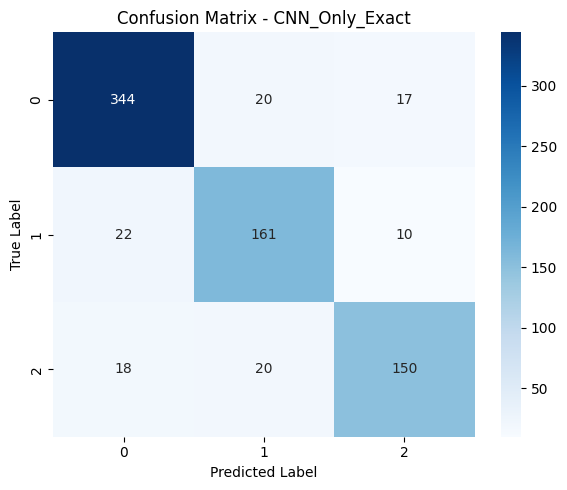

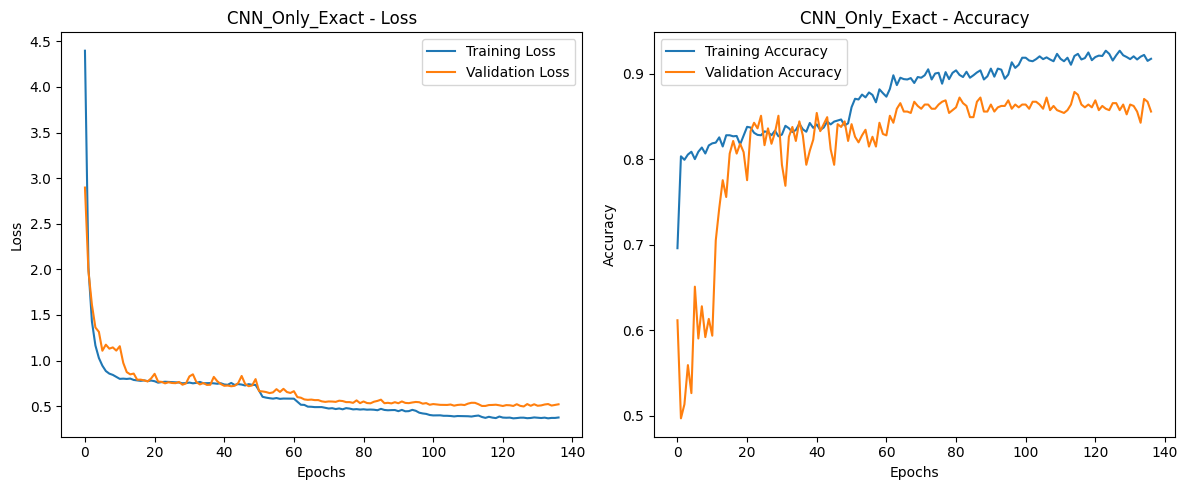

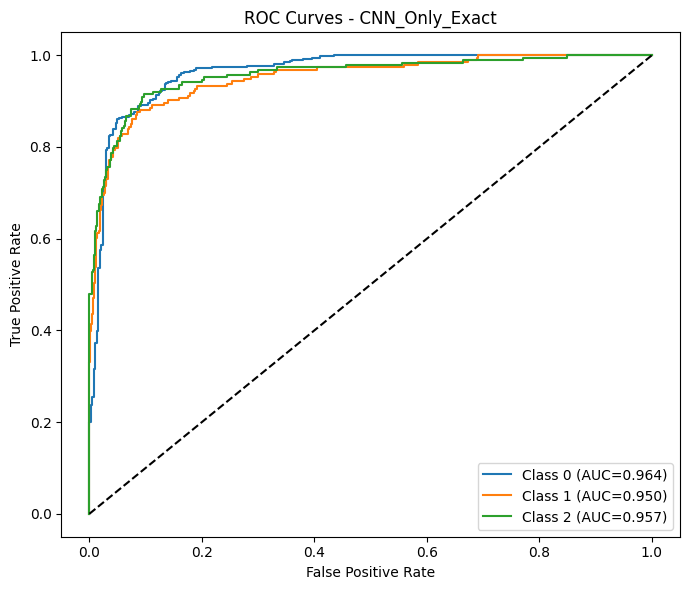

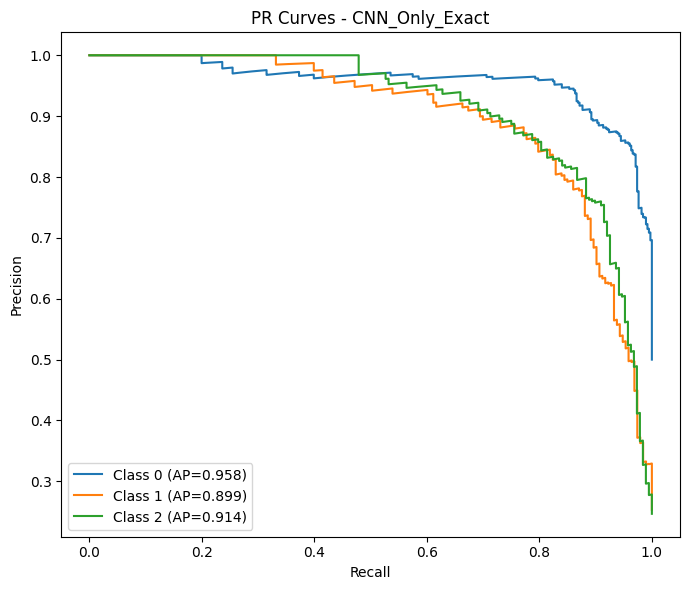


Training: Transformer_Only_Exact


Model: "Transformer_Only_Exact"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 3800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_11   │ (None, 3800, 1)   │          0 │ input_layer_11[0… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 3800, 16)  │         32 │ gaussian_noise_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 16)  │         64 │ dense_28[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_… │ (None, 475, 16)   │          0 │ batch_normalizat… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 475, 16)   │          0 │ average_pooling1… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 475, 16)   │      4,304 │ dropout_29[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_29[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 475, 16)   │          0 │ dropout_29[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 475, 16)   │        272 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 475, 16)   │          0 │ dense_29[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 475, 16)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_31[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_17[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 7600)      │          0 │ layer_normalizat… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 3)         │     22,803 │ flatten_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,539 (107.57 KB)

 Trainable params: 27,507 (107.45 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.5406 - loss: 5.9880 - val_accuracy: 0.6902 - val_loss: 3.8079 - learning_rate: 0.0010
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6950 - loss: 3.2471 - val_accuracy: 0.6689 - val_loss: 2.5433 - learning_rate: 0.0010
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7192 - loss: 2.0080 - val_accuracy: 0.6508 - val_loss: 1.9187 - learning_rate: 0.0010
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7265 - loss: 1.4361 - val_accuracy: 0.6557 - val_loss: 1.5833 - learning_rate: 0.0010
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7199 - loss: 1.2025 - val_accuracy: 0.6377 - val_loss: 1.5558 - learning_rate: 0.0010
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7356 - loss: 1.0494 - val_accuracy: 0.6525 - val_loss: 1.3561 - learning_rate: 0.0010
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7334 - loss: 0.9815 -

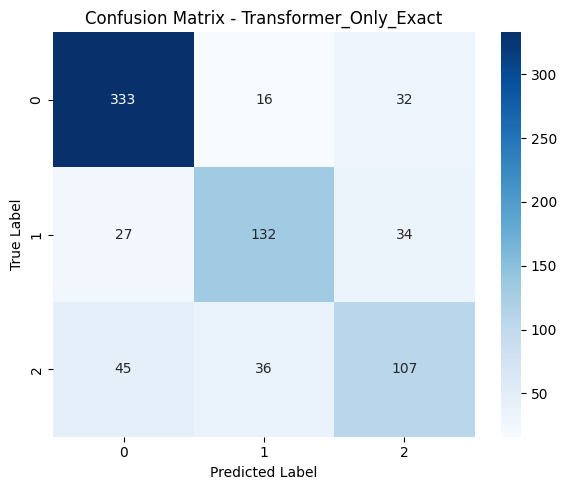

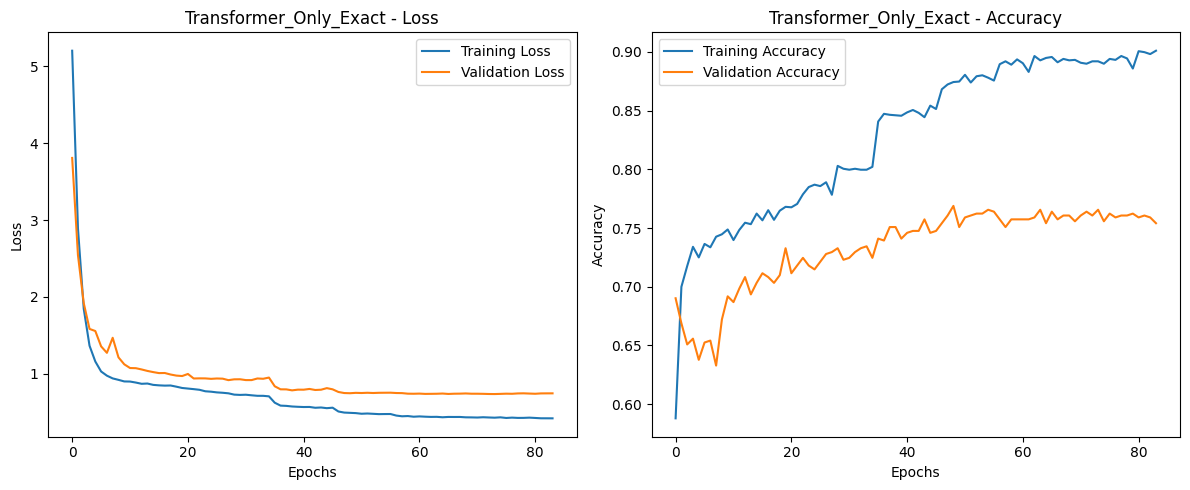

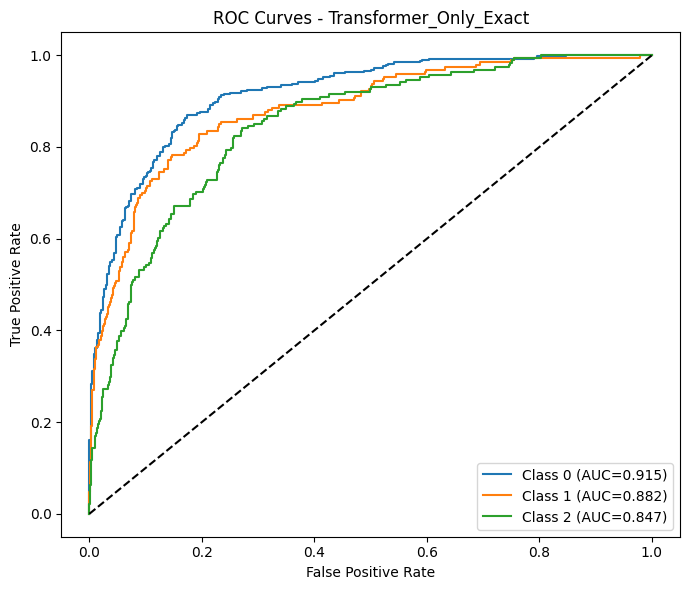

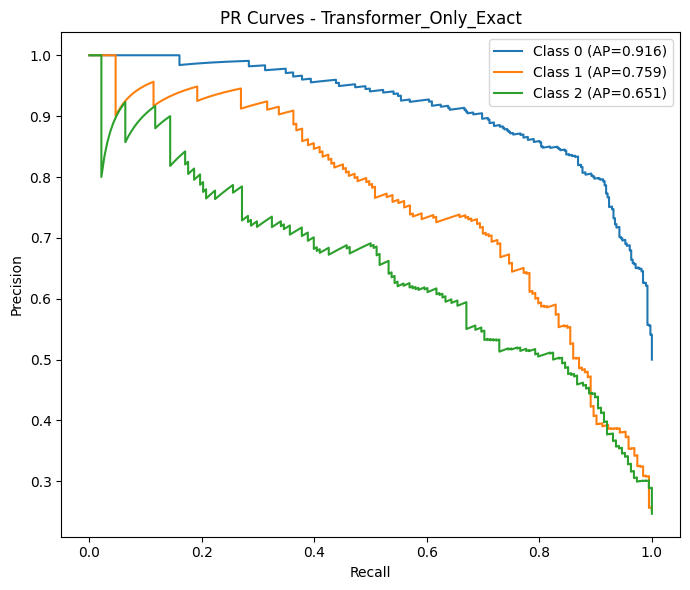


Ablation Study Summary
                    Model  Accuracy  AUC_ROC_macro  AUC_ROC_weighted  \
0         Hybrid_CT_Exact  0.914698       0.970216          0.971544   
1          CNN_Only_Exact  0.859580       0.956743          0.958484   
2  Transformer_Only_Exact  0.750656       0.881179          0.889812   

   AUC_PRC_macro  AUC_PRC_weighted  
0       0.954684          0.958117  
1       0.923800          0.932338  
2       0.775368          0.810873  


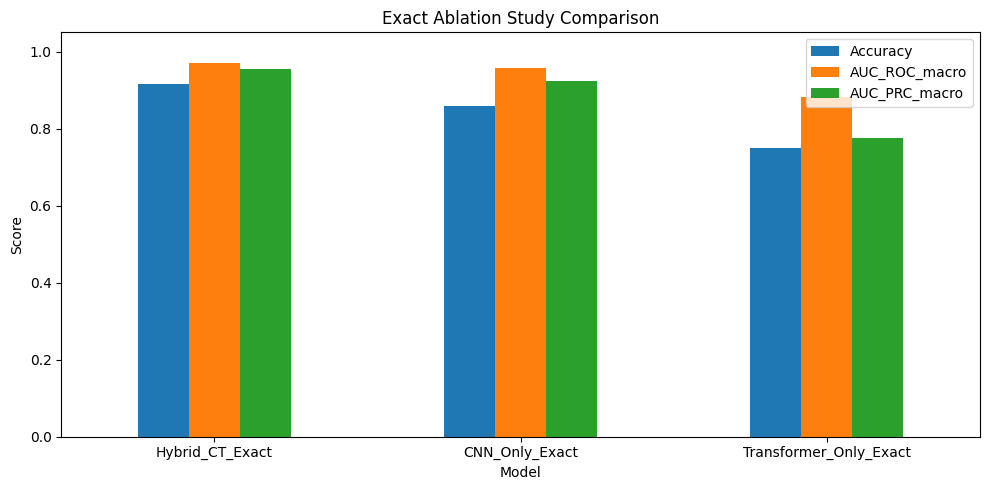


Saved files:
 - ablation_summary_exact.csv
 - ablation_detailed_exact.csv


In [12]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

# =========================================================
# 1. Reproducibility
# =========================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# 2. Load and preprocess data
# =========================================================
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values.astype(np.float32)
y = df.iloc[:, -1].values.astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("num_classes  :", num_classes)

# =========================================================
# 3. Shared callbacks
# =========================================================
def get_callbacks():
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-4,
        verbose=1
    )
    return [early_stopping, lr_scheduler]

# =========================================================
# 4. Shared plotting utilities
# =========================================================
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, model_name, num_classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=range(num_classes),
        yticklabels=range(num_classes)
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

def plot_multiclass_roc_pr(y_true, y_prob, model_name):
    y_true_bin = label_binarize(y_true, classes=np.arange(y_prob.shape[1]))

    # ROC
    plt.figure(figsize=(7, 6))
    for i in range(y_prob.shape[1]):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc_i:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves - {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR
    plt.figure(figsize=(7, 6))
    for i in range(y_prob.shape[1]):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        ap_i = average_precision_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(recall, precision, label=f"Class {i} (AP={ap_i:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curves - {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================================================
# 5. Evaluation
# =========================================================
def compute_metrics(y_true, y_prob, model_name):
    y_pred = np.argmax(y_prob, axis=1)
    y_true_bin = label_binarize(y_true, classes=np.arange(y_prob.shape[1]))

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC_ROC_macro": roc_auc_score(
            y_true_bin, y_prob, average="macro", multi_class="ovr"
        ),
        "AUC_ROC_weighted": roc_auc_score(
            y_true_bin, y_prob, average="weighted", multi_class="ovr"
        ),
        "AUC_PRC_macro": average_precision_score(
            y_true_bin, y_prob, average="macro"
        ),
        "AUC_PRC_weighted": average_precision_score(
            y_true_bin, y_prob, average="weighted"
        ),
    }

    for i in range(y_prob.shape[1]):
        metrics[f"Class_{i}_ROC_AUC"] = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        metrics[f"Class_{i}_PR_AUC"] = average_precision_score(y_true_bin[:, i], y_prob[:, i])

    return metrics, y_pred

# =========================================================
# 6. Exact Hybrid CT model (UNCHANGED from your original)
# =========================================================
def build_hybrid_ct_exact(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    # Temporal Convolution
    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Channel Convolution
    x = Conv1D(
        filters=8,
        kernel_size=1,
        groups=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Spatial Convolution
    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Transformer Encoder
    mha = MultiHeadAttention(num_heads=4, key_dim=x.shape[-1])(x, x)
    mha = Add()([x, mha])
    mha = LayerNormalization()(mha)

    # Feed-forward network
    ff = Dense(
        x.shape[-1],
        activation='relu',
        kernel_regularizer=l2(0.2)
    )(mha)
    ff = Dropout(0.6)(ff)
    ff = Add()([mha, ff])
    ff = LayerNormalization()(ff)

    # Classifier
    ff_flat = Flatten()(ff)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.3)
    )(ff_flat)

    model = Model(inputs=inputs, outputs=outputs, name="Hybrid_CT_Exact")
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# =========================================================
# 7. CNN-only ablation
#    Exact same conv front-end, remove ONLY transformer block
# =========================================================
def build_cnn_only_exact(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    # Temporal Convolution
    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Channel Convolution
    x = Conv1D(
        filters=8,
        kernel_size=1,
        groups=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Spatial Convolution
    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Direct classifier (transformer removed)
    x = Flatten()(x)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.3)
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name="CNN_Only_Exact")
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# =========================================================
# 8. Transformer-only ablation
#    No CNN.
#    Minimal substitution: Dense(16) projection so transformer
#    receives same token width as hybrid post-CNN tensor.
# =========================================================
def build_transformer_only_exact(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    # Minimal interface-preserving projection:
    # hybrid transformer sees last-dim = 16
    x = Dense(
        16,
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    # Keep the same pooling used before transformer in hybrid
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Exact same transformer block structure
    mha = MultiHeadAttention(num_heads=4, key_dim=x.shape[-1])(x, x)
    mha = Add()([x, mha])
    mha = LayerNormalization()(mha)

    ff = Dense(
        x.shape[-1],
        activation='relu',
        kernel_regularizer=l2(0.2)
    )(mha)
    ff = Dropout(0.6)(ff)
    ff = Add()([mha, ff])
    ff = LayerNormalization()(ff)

    ff_flat = Flatten()(ff)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.3)
    )(ff_flat)

    model = Model(inputs=inputs, outputs=outputs, name="Transformer_Only_Exact")
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# =========================================================
# 9. Training wrapper
# =========================================================
def train_and_evaluate(model_builder, model_name, X_train, y_train, X_test, y_test):
    print("\n" + "=" * 90)
    print(f"Training: {model_name}")
    print("=" * 90)

    model = model_builder(X_train.shape[1:], num_classes)
    model.summary()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=500,
        batch_size=32,
        callbacks=get_callbacks(),
        verbose=1
    )

    y_prob_train = model.predict(X_train, verbose=0)
    y_prob_test = model.predict(X_test, verbose=0)

    y_pred_train = np.argmax(y_prob_train, axis=1)
    y_pred_test = np.argmax(y_prob_test, axis=1)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"\nTraining Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy : {test_acc:.4f}")

    metrics, y_test_pred = compute_metrics(y_test, y_prob_test, model_name)

    print(f"Macro AUC-ROC    : {metrics['AUC_ROC_macro']:.4f}")
    print(f"Weighted AUC-ROC : {metrics['AUC_ROC_weighted']:.4f}")
    print(f"Macro AUC-PRC    : {metrics['AUC_PRC_macro']:.4f}")
    print(f"Weighted AUC-PRC : {metrics['AUC_PRC_weighted']:.4f}")

    plot_confusion_matrix(y_test, y_test_pred, model_name, num_classes)
    plot_training_history(history, model_name)
    plot_multiclass_roc_pr(y_test, y_prob_test, model_name)

    return model, history, metrics

# =========================================================
# 10. Run exact ablation study
# =========================================================
all_results = []

hybrid_model, hybrid_history, hybrid_metrics = train_and_evaluate(
    build_hybrid_ct_exact,
    "Hybrid_CT_Exact",
    X_train, y_train, X_test, y_test
)
all_results.append(hybrid_metrics)

cnn_model, cnn_history, cnn_metrics = train_and_evaluate(
    build_cnn_only_exact,
    "CNN_Only_Exact",
    X_train, y_train, X_test, y_test
)
all_results.append(cnn_metrics)

transformer_model, transformer_history, transformer_metrics = train_and_evaluate(
    build_transformer_only_exact,
    "Transformer_Only_Exact",
    X_train, y_train, X_test, y_test
)
all_results.append(transformer_metrics)

# =========================================================
# 11. Summary table
# =========================================================
results_df = pd.DataFrame(all_results)

summary_cols = [
    "Model",
    "Accuracy",
    "AUC_ROC_macro",
    "AUC_ROC_weighted",
    "AUC_PRC_macro",
    "AUC_PRC_weighted"
]

summary_df = results_df[summary_cols].copy()
print("\nAblation Study Summary")
print(summary_df)

summary_df.to_csv("ablation_summary_exact.csv", index=False)
results_df.to_csv("ablation_detailed_exact.csv", index=False)

# Optional comparison plot
plot_df = summary_df.set_index("Model")
plot_df[["Accuracy", "AUC_ROC_macro", "AUC_PRC_macro"]].plot(kind="bar", figsize=(10, 5))
plt.title("Exact Ablation Study Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("\nSaved files:")
print(" - ablation_summary_exact.csv")
print(" - ablation_detailed_exact.csv")

Train shape: (3046, 3800, 1)
Test shape : (762, 3800, 1)
Classes    : 3

Training Hybrid_Full


Model: "Hybrid_Full"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 3800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_12   │ (None, 3800, 1)   │          0 │ input_layer_12[0… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 3800, 8)   │        520 │ gaussian_noise_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 8)   │         32 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 3800, 8)   │         72 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 8)   │         32 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 3800, 16)  │      2,064 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 16)  │         64 │ conv1d_26[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_… │ (None, 475, 16)   │          0 │ batch_normalizat… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 475, 16)   │          0 │ average_pooling1… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 475, 16)   │      4,304 │ dropout_32[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 475, 16)   │          0 │ dropout_32[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 475, 16)   │        272 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 475, 16)   │          0 │ dense_31[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 475, 16)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 7600)      │          0 │ layer_normalizat… │
│ (Flatten)           │                   │            │                 

 Total params: 30,227 (118.07 KB)

 Trainable params: 30,163 (117.82 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - accuracy: 0.5272 - loss: 8.7901 - val_accuracy: 0.7180 - val_loss: 5.4674 - learning_rate: 0.0010
Epoch 2/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7891 - loss: 4.4255 - val_accuracy: 0.6623 - val_loss: 3.4438 - learning_rate: 0.0010
Epoch 3/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8387 - loss: 2.4702 - val_accuracy: 0.6557 - val_loss: 2.5064 - learning_rate: 0.0010
Epoch 4/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8398 - loss: 1.6293 - val_accuracy: 0.7574 - val_loss: 1.6496 - learning_rate: 0.0010
Epoch 5/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8419 - loss: 1.2289 - val_accuracy: 0.7049 - val_loss: 1.6043 - learning_rate: 0.0010
Epoch 6/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8451 - loss: 1.0129 - val_accuracy: 0.7803 - val_loss: 1.1574 - learning_rate: 0.0010
Epoch 7/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8606 - loss: 0.8850 

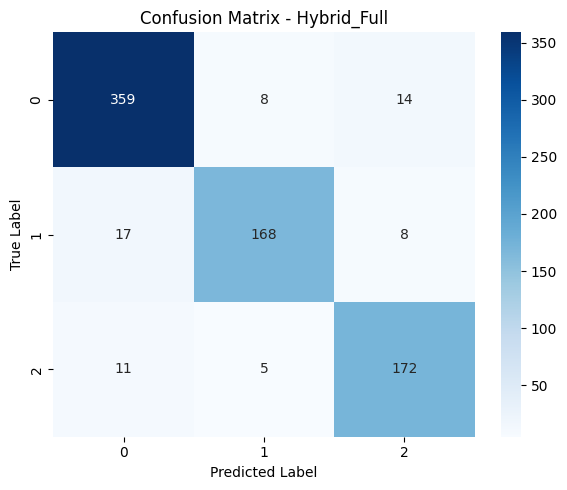

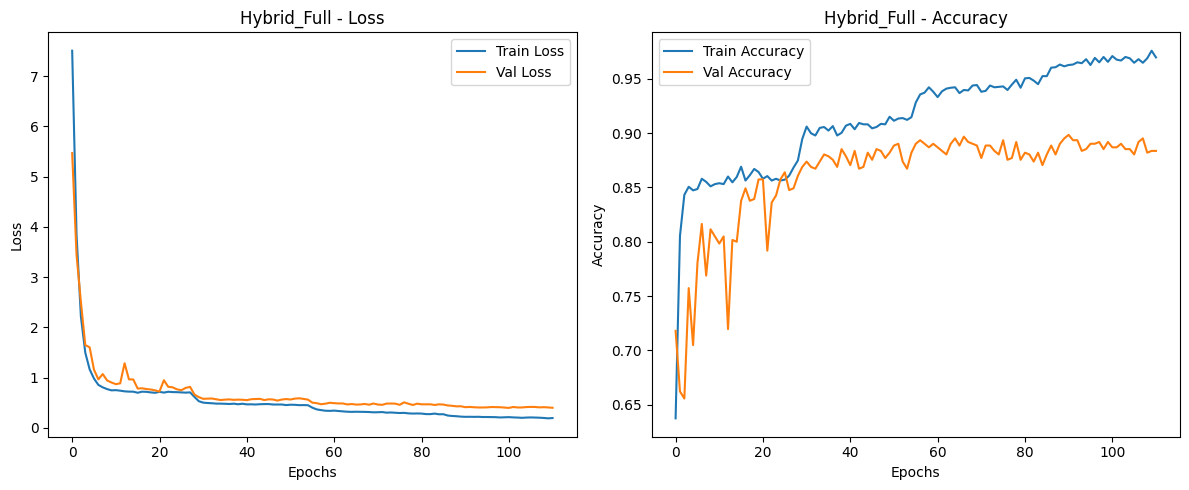

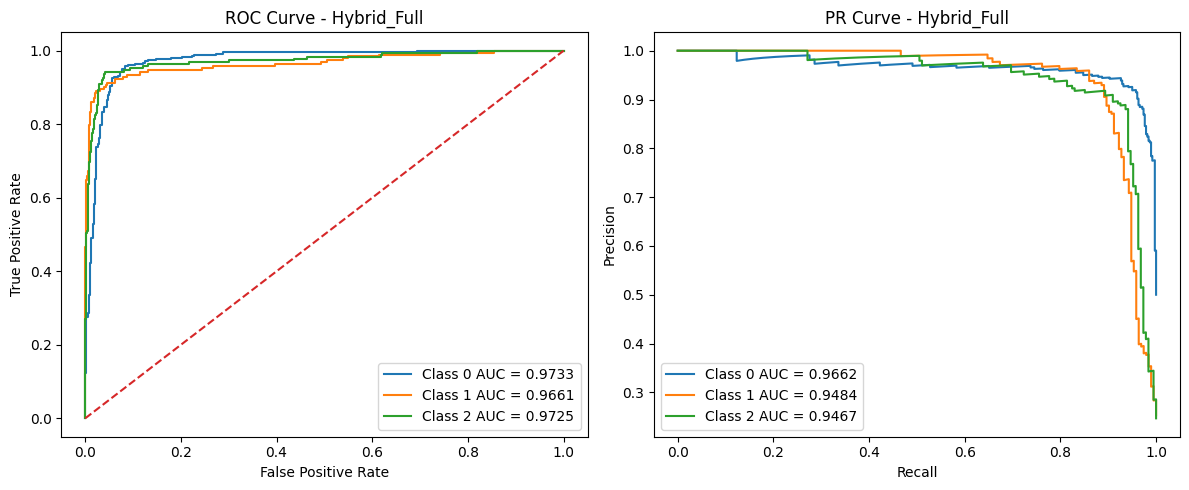


Training CNN_Only


Model: "CNN_Only"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 3800, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_13               │ (None, 3800, 1)        │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 3800, 8)        │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 3800, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 3800, 8)        │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 3800, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 3800, 16)       │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 3800, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_12            │ (None, 475, 16)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 475, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 7600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │       486,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,443 (1.87 MB)

 Trainable params: 489,379 (1.87 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.5784 - loss: 18.6318 - val_accuracy: 0.5820 - val_loss: 4.3264 - learning_rate: 0.0010
Epoch 2/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7185 - loss: 3.6039 - val_accuracy: 0.4934 - val_loss: 2.7187 - learning_rate: 0.0010
Epoch 3/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6879 - loss: 2.3603 - val_accuracy: 0.5000 - val_loss: 2.1406 - learning_rate: 0.0010
Epoch 4/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6764 - loss: 1.8897 - val_accuracy: 0.5033 - val_loss: 1.8110 - learning_rate: 0.0010
Epoch 5/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6614 - loss: 1.6408 - val_accuracy: 0.4967 - val_loss: 1.7118 - learning_rate: 0.0010
Epoch 6/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6486 - loss: 1.4819 - val_accuracy: 0.5000 - val_loss: 1.6790 - learning_rate: 0.0010
Epoch 7/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6634 - loss: 1.4441 - val_

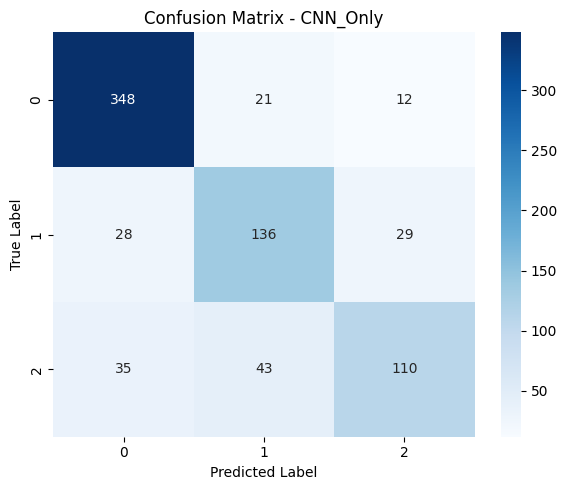

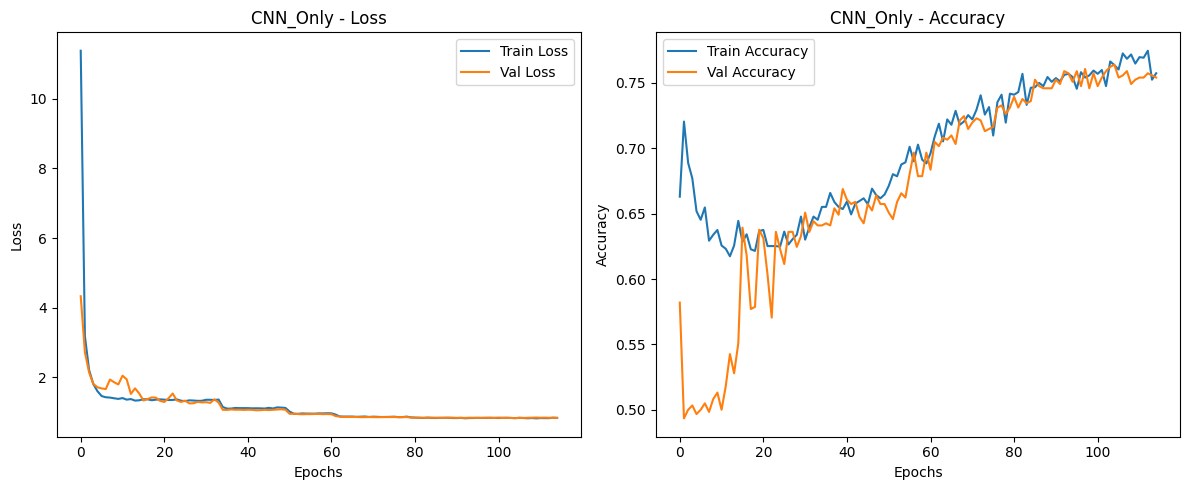

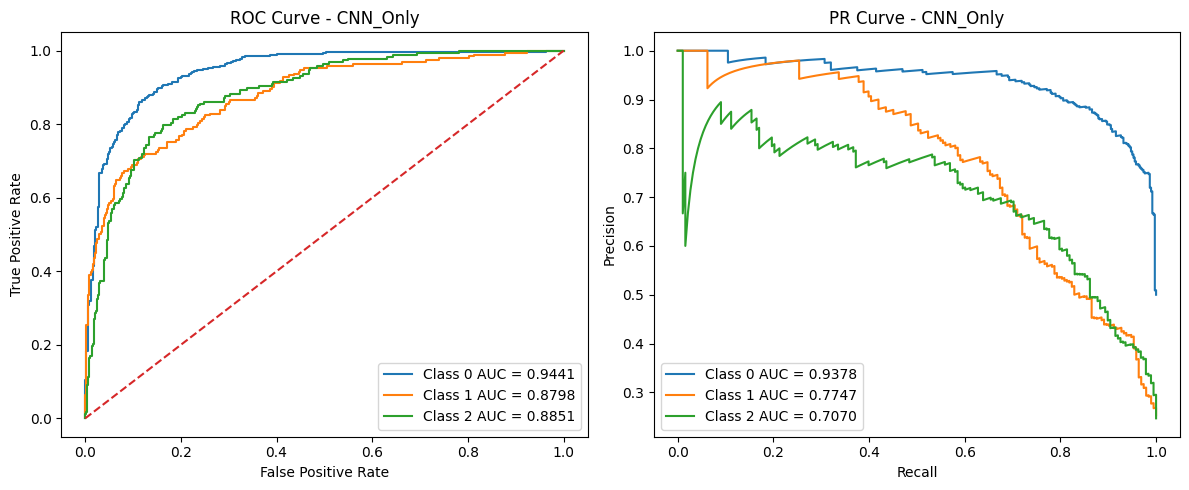


Training Transformer_Only


Model: "Transformer_Only"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 3800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_14   │ (None, 3800, 1)   │          0 │ input_layer_14[0… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 3800, 16)  │         32 │ gaussian_noise_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 16)  │         64 │ conv1d_30[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_… │ (None, 950, 16)   │          0 │ batch_normalizat… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 950, 16)   │          0 │ average_pooling1… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 950, 16)   │      4,304 │ dropout_37[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_37[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 950, 16)   │          0 │ dropout_37[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 950, 16)   │         32 │ add_20[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 950, 16)   │        272 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 950, 16)   │          0 │ dense_35[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 950, 16)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_39[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 950, 16)   │         32 │ add_21[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 15200)     │          0 │ layer_normalizat… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 3)         │     45,603 │ flatten_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,339 (196.64 KB)

 Trainable params: 50,307 (196.51 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.6375 - loss: 5.7851 - val_accuracy: 0.7459 - val_loss: 3.8151 - learning_rate: 0.0010
Epoch 2/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8154 - loss: 3.0641 - val_accuracy: 0.7525 - val_loss: 2.3521 - learning_rate: 0.0010
Epoch 3/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7985 - loss: 1.8856 - val_accuracy: 0.7492 - val_loss: 1.7457 - learning_rate: 0.0010
Epoch 4/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8195 - loss: 1.3209 - val_accuracy: 0.7344 - val_loss: 1.5355 - learning_rate: 0.0010
Epoch 5/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8212 - loss: 1.0915 - val_accuracy: 0.7197 - val_loss: 1.4954 - learning_rate: 0.0010
Epoch 6/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8215 - loss: 0.9800 - val_accuracy: 0.7393 - val_loss: 1.3187 - learning_rate: 0.0010
Epoch 7/300
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8425 - loss: 0.9108 

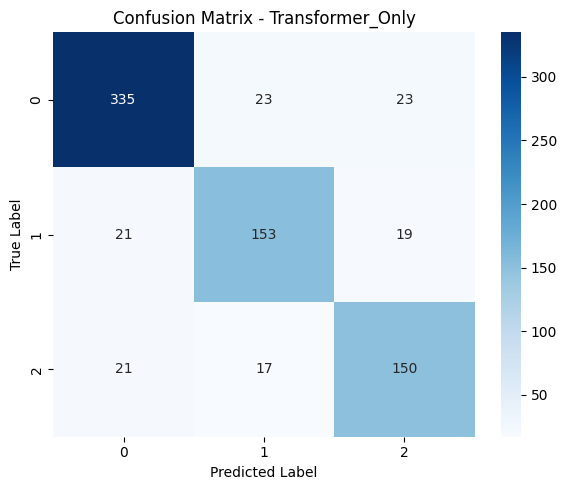

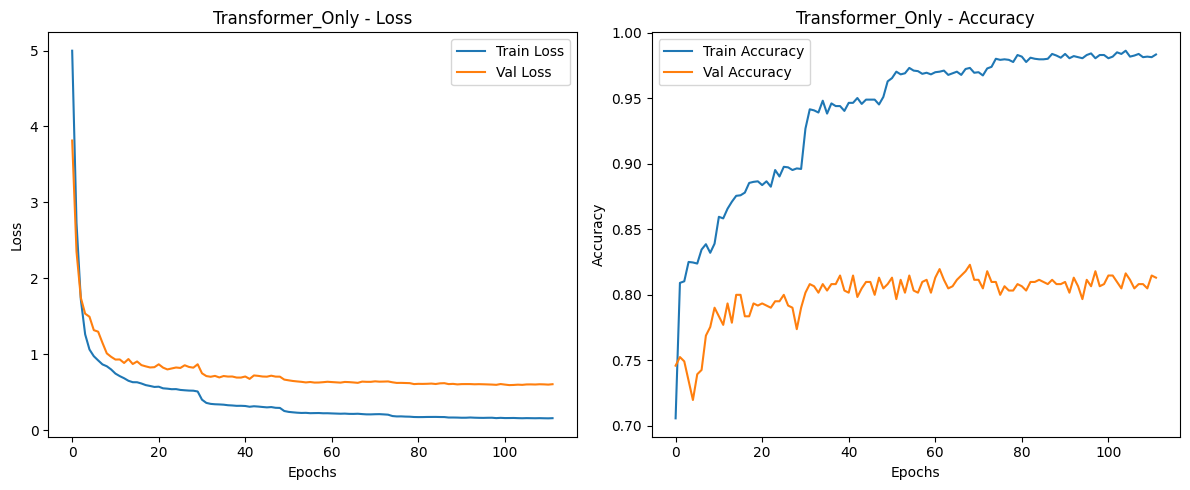

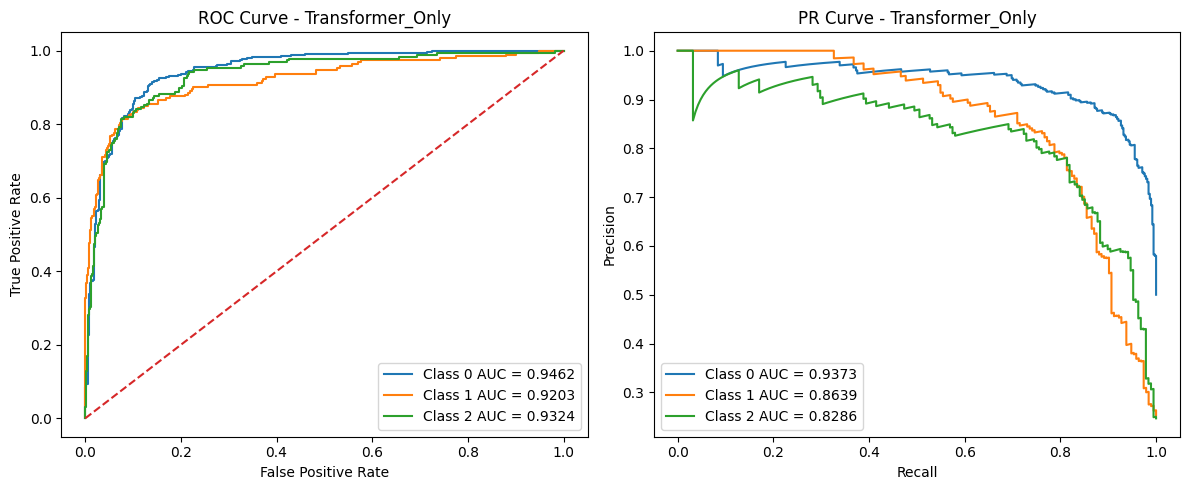


Ablation Study Summary
              Model  Train Accuracy  Test Accuracy  Train F1-Macro  \
0       Hybrid_Full        0.963887       0.917323        0.960325   
1          CNN_Only        0.798096       0.779528        0.764819   
2  Transformer_Only        0.952397       0.837270        0.946491   

   Test F1-Macro  Train Precision-Macro  Test Precision-Macro  \
0       0.911272               0.961233              0.914141   
1       0.739956               0.778946              0.751731   
2       0.822042               0.947485              0.820863   

   Train Recall-Macro  Test Recall-Macro  Train ROC-AUC  Test ROC-AUC  \
0            0.959608           0.909206       0.994160      0.970650   
1            0.756694           0.734385       0.921469      0.902991   
2            0.945526           0.823295       0.989100      0.932968   

   Train PR-AUC  Test PR-AUC  
0      0.989632     0.953900  
1      0.845750     0.807463  
2      0.980679     0.877059  


,Model,Train Accuracy,Test Accuracy,Train F1-Macro,Test F1-Macro,Train Precision-Macro,Test Precision-Macro,Train Recall-Macro,Test Recall-Macro,Train ROC-AUC,Test ROC-AUC,Train PR-AUC,Test PR-AUC
0,Hybrid_Full,0.963887,0.917323,0.960325,0.911272,0.961233,0.914141,0.959608,0.909206,0.994160,0.970650,0.989632,0.953900
1,CNN_Only,0.798096,0.779528,0.764819,0.739956,0.778946,0.751731,0.756694,0.734385,0.921469,0.902991,0.845750,0.807463
2,Transformer_Only,0.952397,0.837270,0.946491,0.822042,0.947485,0.820863,0.945526,0.823295,0.989100,0.932968,0.980679,0.877059


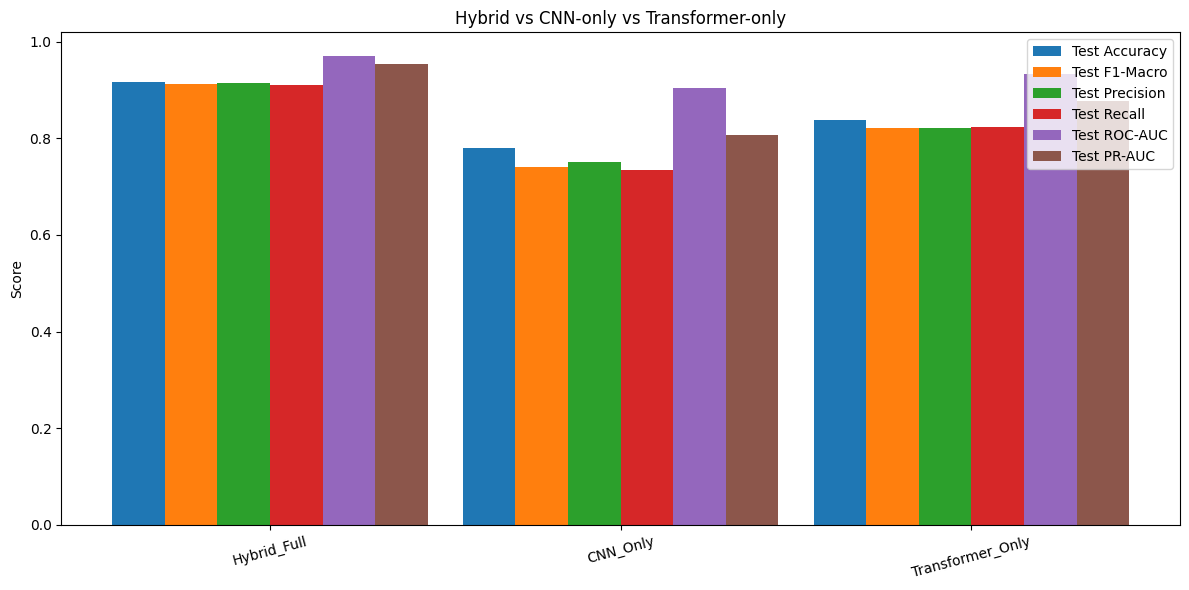


Performance Margin
Hybrid_Full - CNN_Only         : 0.1378
Hybrid_Full - Transformer_Only : 0.0801


In [13]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc,
    f1_score, precision_score, recall_score
)

warnings.filterwarnings("ignore")

# =========================================================
# Reproducibility
# =========================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# Load Data
# =========================================================
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

# Features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)

num_classes = len(np.unique(y))

# IMPORTANT: split first, then fit scaler on training only
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Conv1D input: (samples, timesteps, channels)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

input_shape = X_train.shape[1:]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Classes    :", num_classes)

# =========================================================
# Model Definitions
# =========================================================
def build_hybrid_model(input_shape, num_classes):
    """Full Hybrid: CNN + Transformer"""
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    # CNN feature extractor
    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=8,
        kernel_size=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Transformer encoder
    attn = MultiHeadAttention(
        num_heads=4,
        key_dim=int(x.shape[-1])
    )(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(
        int(x.shape[-1]),
        activation="relu",
        kernel_regularizer=l2(0.2)
    )(x)
    ff = Dropout(0.6)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    x = Flatten()(x)

    outputs = Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=l2(0.3)
    )(x)

    model = Model(inputs, outputs, name="Hybrid_Full")
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_cnn_only_model(input_shape, num_classes):
    """CNN-only ablation"""
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=8,
        kernel_size=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    x = Flatten()(x)
    x = Dense(64, activation="relu", kernel_regularizer=l2(0.2))(x)
    x = Dropout(0.6)(x)

    outputs = Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=l2(0.3)
    )(x)

    model = Model(inputs, outputs, name="CNN_Only")
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_transformer_only_model(input_shape, num_classes):
    """Transformer-only ablation"""
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    # Projection
    x = Conv1D(
        filters=16,
        kernel_size=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = AveragePooling1D(pool_size=4)(x)
    x = Dropout(0.5)(x)

    # Transformer block
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(16, activation="relu", kernel_regularizer=l2(0.2))(x)
    ff = Dropout(0.5)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    x = Flatten()(x)

    outputs = Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=l2(0.3)
    )(x)

    model = Model(inputs, outputs, name="Transformer_Only")
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# =========================================================
# Metrics Helpers
# =========================================================
def compute_auc_metrics(y_true, y_prob, num_classes):
    y_true_bin = to_categorical(y_true, num_classes=num_classes)

    if num_classes == 2:
        roc_auc = roc_auc_score(y_true, y_prob[:, 1])
        pr_auc = average_precision_score(y_true, y_prob[:, 1])
    else:
        roc_auc = roc_auc_score(
            y_true_bin, y_prob,
            multi_class="ovr",
            average="macro"
        )
        pr_auc = average_precision_score(
            y_true_bin, y_prob,
            average="macro"
        )

    return roc_auc, pr_auc


def compute_all_metrics(y_true, y_prob, num_classes):
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    roc_auc, pr_auc = compute_auc_metrics(y_true, y_prob, num_classes)

    return {
        "Accuracy": acc,
        "F1-Macro": f1,
        "Precision-Macro": precision,
        "Recall-Macro": recall,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Predictions": y_pred
    }


# =========================================================
# Plot Helpers
# =========================================================
def plot_conf_matrix(y_true, y_pred, model_name, num_classes):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=range(num_classes),
        yticklabels=range(num_classes)
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()


def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(y_true, y_prob, num_classes, model_name):
    y_true_bin = to_categorical(y_true, num_classes=num_classes)

    plt.figure(figsize=(12, 5))

    # ROC
    plt.subplot(1, 2, 1)
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    else:
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            roc_auc_i = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"Class {i} AUC = {roc_auc_i:.4f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()

    # PR
    plt.subplot(1, 2, 2)
    if num_classes == 2:
        precision, recall, _ = precision_recall_curve(y_true, y_prob[:, 1])
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    else:
        for i in range(num_classes):
            precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
            pr_auc_i = auc(recall, precision)
            plt.plot(recall, precision, label=f"Class {i} AUC = {pr_auc_i:.4f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {model_name}")
    plt.legend()

    plt.tight_layout()
    plt.show()


# =========================================================
# Train / Evaluate
# =========================================================
def train_and_evaluate(model_fn, model_name, X_train, y_train, X_test, y_test, num_classes):
    print("\n" + "=" * 80)
    print(f"Training {model_name}")
    print("=" * 80)

    model = model_fn(input_shape, num_classes)
    model.summary()

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-4,
        verbose=1
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=300,
        batch_size=32,
        callbacks=[early_stopping, lr_scheduler],
        verbose=1
    )

    # Predictions
    y_train_prob = model.predict(X_train, verbose=0)
    y_test_prob = model.predict(X_test, verbose=0)

    train_metrics = compute_all_metrics(y_train, y_train_prob, num_classes)
    test_metrics = compute_all_metrics(y_test, y_test_prob, num_classes)

    print(f"\n{model_name} Results")
    print(f"Train Accuracy        : {train_metrics['Accuracy']:.4f}")
    print(f"Test Accuracy         : {test_metrics['Accuracy']:.4f}")
    print(f"Train F1-Macro        : {train_metrics['F1-Macro']:.4f}")
    print(f"Test F1-Macro         : {test_metrics['F1-Macro']:.4f}")
    print(f"Train Precision-Macro : {train_metrics['Precision-Macro']:.4f}")
    print(f"Test Precision-Macro  : {test_metrics['Precision-Macro']:.4f}")
    print(f"Train Recall-Macro    : {train_metrics['Recall-Macro']:.4f}")
    print(f"Test Recall-Macro     : {test_metrics['Recall-Macro']:.4f}")
    print(f"Train ROC-AUC         : {train_metrics['ROC-AUC']:.4f}")
    print(f"Test ROC-AUC          : {test_metrics['ROC-AUC']:.4f}")
    print(f"Train PR-AUC          : {train_metrics['PR-AUC']:.4f}")
    print(f"Test PR-AUC           : {test_metrics['PR-AUC']:.4f}")

    # Plots
    plot_conf_matrix(y_test, test_metrics["Predictions"], model_name, num_classes)
    plot_training_history(history, model_name)
    plot_roc_pr_curves(y_test, y_test_prob, num_classes, model_name)

    results = {
        "Model": model_name,
        "Train Accuracy": train_metrics["Accuracy"],
        "Test Accuracy": test_metrics["Accuracy"],
        "Train F1-Macro": train_metrics["F1-Macro"],
        "Test F1-Macro": test_metrics["F1-Macro"],
        "Train Precision-Macro": train_metrics["Precision-Macro"],
        "Test Precision-Macro": test_metrics["Precision-Macro"],
        "Train Recall-Macro": train_metrics["Recall-Macro"],
        "Test Recall-Macro": test_metrics["Recall-Macro"],
        "Train ROC-AUC": train_metrics["ROC-AUC"],
        "Test ROC-AUC": test_metrics["ROC-AUC"],
        "Train PR-AUC": train_metrics["PR-AUC"],
        "Test PR-AUC": test_metrics["PR-AUC"]
    }

    return model, history, results


# =========================================================
# Run Only Three Models
# =========================================================
all_results = []

# 1. Full Hybrid
hybrid_model, hybrid_history, hybrid_results = train_and_evaluate(
    build_hybrid_model, "Hybrid_Full",
    X_train, y_train, X_test, y_test, num_classes
)
all_results.append(hybrid_results)

# 2. CNN Only
cnn_model, cnn_history, cnn_results = train_and_evaluate(
    build_cnn_only_model, "CNN_Only",
    X_train, y_train, X_test, y_test, num_classes
)
all_results.append(cnn_results)

# 3. Transformer Only
transformer_model, transformer_history, transformer_results = train_and_evaluate(
    build_transformer_only_model, "Transformer_Only",
    X_train, y_train, X_test, y_test, num_classes
)
all_results.append(transformer_results)

# =========================================================
# Summary Table
# =========================================================
results_df = pd.DataFrame(all_results)

print("\n" + "=" * 80)
print("Ablation Study Summary")
print("=" * 80)
print(results_df)

display(results_df)

# =========================================================
# Comparison Plot
# =========================================================
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df["Model"]))
width = 0.15

plt.bar(x - 2.5 * width, results_df["Test Accuracy"], width=width, label="Test Accuracy")
plt.bar(x - 1.5 * width, results_df["Test F1-Macro"], width=width, label="Test F1-Macro")
plt.bar(x - 0.5 * width, results_df["Test Precision-Macro"], width=width, label="Test Precision")
plt.bar(x + 0.5 * width, results_df["Test Recall-Macro"], width=width, label="Test Recall")
plt.bar(x + 1.5 * width, results_df["Test ROC-AUC"], width=width, label="Test ROC-AUC")
plt.bar(x + 2.5 * width, results_df["Test PR-AUC"], width=width, label="Test PR-AUC")

plt.xticks(x, results_df["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Hybrid vs CNN-only vs Transformer-only")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Simple Margin Printout
# =========================================================
hybrid_acc = results_df.loc[results_df["Model"] == "Hybrid_Full", "Test Accuracy"].values[0]
cnn_acc = results_df.loc[results_df["Model"] == "CNN_Only", "Test Accuracy"].values[0]
trans_acc = results_df.loc[results_df["Model"] == "Transformer_Only", "Test Accuracy"].values[0]

print("\n" + "=" * 80)
print("Performance Margin")
print("=" * 80)
print(f"Hybrid_Full - CNN_Only         : {hybrid_acc - cnn_acc:.4f}")
print(f"Hybrid_Full - Transformer_Only : {hybrid_acc - trans_acc:.4f}")

CV for the CT

In [7]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# =========================================================
# Reproducibility
# =========================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# Load Data
# =========================================================
dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)

num_classes = len(np.unique(y))
K = 10

# =========================================================
# Hybrid CNN-Transformer Model
# =========================================================
def build_hybrid_ctnet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.05)(inputs)

    # CNN backbone
    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=8,
        kernel_size=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=16,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)
    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    # Transformer encoder
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(16, activation='relu', kernel_regularizer=l2(0.2))(x)
    ff = Dropout(0.6)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    x = Flatten()(x)

    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.3)
    )(x)

    model = Model(inputs, outputs, name="Hybrid_CTNet")
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# =========================================================
# Metric Helper
# =========================================================
def compute_auc_scores(y_true, y_prob, num_classes):
    y_true_cat = to_categorical(y_true, num_classes=num_classes)

    if num_classes == 2:
        roc_auc = roc_auc_score(y_true, y_prob[:, 1])
        pr_auc = average_precision_score(y_true, y_prob[:, 1])
    else:
        roc_auc = roc_auc_score(
            y_true_cat,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
        pr_auc = average_precision_score(
            y_true_cat,
            y_prob,
            average="macro"
        )

    return roc_auc, pr_auc

# =========================================================
# 10-Fold Stratified Cross-Validation
# =========================================================
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

fold_results = []
history_list = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n{'='*80}")
    print(f"Training Fold {fold}/{K}")
    print(f"{'='*80}")

    # Split data
    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Standardize inside each fold to avoid leakage
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    # Reshape for Conv1D: (samples, timesteps, channels)
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)

    # Build model fresh for each fold
    model = build_hybrid_ctnet(X_train.shape[1:], num_classes)

    # Callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-4,
        verbose=1
    )

    # Train
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=500,
        batch_size=32,
        callbacks=[early_stopping, lr_scheduler],
        verbose=0
    )

    history_list.append(history.history)

    # Predictions
    y_train_prob = model.predict(X_train, verbose=0)
    y_test_prob = model.predict(X_test, verbose=0)

    y_train_pred = np.argmax(y_train_prob, axis=1)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # AUC
    train_roc_auc, train_pr_auc = compute_auc_scores(y_train, y_train_prob, num_classes)
    test_roc_auc, test_pr_auc = compute_auc_scores(y_test, y_test_prob, num_classes)

    print(f"Fold {fold} - Train Accuracy : {train_acc:.4f}")
    print(f"Fold {fold} - Test Accuracy  : {test_acc:.4f}")
    print(f"Fold {fold} - Train ROC-AUC  : {train_roc_auc:.4f}")
    print(f"Fold {fold} - Test ROC-AUC   : {test_roc_auc:.4f}")
    print(f"Fold {fold} - Train PR-AUC   : {train_pr_auc:.4f}")
    print(f"Fold {fold} - Test PR-AUC    : {test_pr_auc:.4f}")

    fold_results.append({
        "Fold": fold,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Train ROC-AUC": train_roc_auc,
        "Test ROC-AUC": test_roc_auc,
        "Train PR-AUC": train_pr_auc,
        "Test PR-AUC": test_pr_auc
    })

# =========================================================
# Summary Results
# =========================================================
results_df = pd.DataFrame(fold_results)

print("\n" + "="*80)
print("10-FOLD CROSS-VALIDATION RESULTS")
print("="*80)
print(results_df)

print("\n" + "="*80)
print("MEAN ± STD ACROSS 10 FOLDS")
print("="*80)
for col in results_df.columns[1:]:
    print(f"{col}: {results_df[col].mean():.4f} ± {results_df[col].std():.4f}")

# Optional save
results_df.to_csv("hybrid_ctnet_10fold_results.csv", index=False)


Training Fold 1/10

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0001.
Fold 1 - Train Accuracy : 0.9373
Fold 1 - Test Accuracy  : 0.9081
Fold 1 - Train ROC-AUC  : 0.9868
Fold 1 - Test ROC-AUC   : 0.9794
Fold 1 - Train PR-AUC   : 0.9754
Fold 1 - Test PR-AUC    : 0.9596

Training Fold 2/10

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 52: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 65: ReduceLROnPlateau reducing learning rate to 0.0001.
Fold 2 - Train Accuracy : 0.9481
Fold 2 - Test Accuracy  : 0.8924
Fold 2 - Train ROC-AUC  : 0.9906
Fold 2 - Test ROC-AUC   : 0.9660
Fold 2 - Train PR-AUC   : 0.9817
Fol